In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import torch.utils.data as torch_data
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
import os

In [14]:
# Load the data
df = pd.read_csv('inputFGclassifierWithLabel.CSV')

# Preprocess the data
# Drop the first column (index 0) and the 13th column (index 12)
data_processed = df.drop(df.columns[[0, 12]], axis=1)

# Select columns 2 to 19 (index 1 to 18 in Python, as index starts from 0)
features = data_processed.iloc[:, 0:17]

# Get the last 10 columns as labels
labels = data_processed.iloc[:, -10:]

# Display processed data information
print(f"Processed data shape:")
print(f"Features shape: {features.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Labels columns: {labels.columns.tolist()}")

print(f"\nFeature statistics:")
print(features.describe())

Processed data shape:
Features shape: (24528, 17)
Labels shape: (24528, 10)
Labels columns: ['LabelFillingP', 'LabelEF', 'LabelCO', 'LabelLAV', 'LabelRVO2E', 'LabelLVO2E', 'LabelLVMVO2', 'LabelRVMVO2', 'LabelLVME', 'LabelRVME']

Feature statistics:
                Sex        Height        Weight           SBP           DBP  \
count  24528.000000  24528.000000  24528.000000  24528.000000  24528.000000   
mean       0.469300    171.587851     91.603987    126.032127     74.564579   
std        0.499067      8.636087     23.191223     24.965296     16.007327   
min        0.000000    138.300000     40.400000     47.000000     29.000000   
25%        0.000000    165.500000     75.600000    109.000000     64.000000   
50%        0.000000    171.300000     88.000000    124.000000     74.000000   
75%        1.000000    177.600000    103.300000    142.000000     84.000000   
max        1.000000    207.500000    337.800000    236.000000    150.000000   

                 EF       Hed_SW       

In [15]:

# Normalize the input features
# Skip the first and last feature columns (binary variables)
continuous_features = features.iloc[:, 1:-1]
scaler = MinMaxScaler()
normalized_features = scaler.fit_transform(continuous_features)

# Combine the binary and normalized continuous features
normalized_features = pd.DataFrame(normalized_features, columns=continuous_features.columns)
normalized_features.insert(0, features.columns[0], features.iloc[:, 0])  # Add the first binary column
normalized_features[features.columns[-1]] = features.iloc[:, -1]  # Add the last binary column

# Convert normalized features to PyTorch Tensor
input_tensor = torch.tensor(normalized_features.values, dtype=torch.float32)

# Display the tensor and its size
print("Input tensor:")
print(input_tensor)
print("\nTensor size:", input_tensor.size())

Input tensor:
tensor([[1.0000, 0.4379, 0.1516,  ..., 0.1392, 0.2769, 0.0000],
        [0.0000, 0.5116, 0.1163,  ..., 0.1418, 0.3385, 1.0000],
        [0.0000, 0.6358, 0.2455,  ..., 0.1873, 0.1308, 0.0000],
        ...,
        [1.0000, 0.5520, 0.3376,  ..., 0.1823, 0.1923, 0.0000],
        [1.0000, 0.6243, 0.4593,  ..., 0.1392, 0.2385, 0.0000],
        [0.0000, 0.4942, 0.1715,  ..., 0.2380, 0.2385, 1.0000]])

Tensor size: torch.Size([24528, 17])


In [16]:
# Define the MLP model
class MLPClassifier(nn.Module):
    def __init__(self, input_size):
        super(MLPClassifier, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 64),  # First hidden layer
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.5),
            nn.Linear(64, 32),  # Second hidden layer
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(0.5),
            nn.Linear(32, 1),  # Output layer
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.model(x)

# Initialize the model
input_size = 17  # Number of input features
model = MLPClassifier(input_size)

# Define the loss function and optimizer
criterion = nn.BCELoss()  # Binary Cross-Entropy Loss
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Display the model structure
print(model)

MLPClassifier(
  (model): Sequential(
    (0): Linear(in_features=17, out_features=64, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.5, inplace=False)
    (8): Linear(in_features=32, out_features=1, bias=True)
    (9): Sigmoid()
  )
)


In [17]:
# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    input_tensor.numpy(), labels.values, test_size=0.2, random_state=42
)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

# Training parameters
batch_size = 48
num_epochs = int(5e3) 
learning_rate = 5e-4

# DataLoader for batching
import torch.utils.data as torch_data
train_dataset = torch_data.TensorDataset(X_train_tensor, y_train_tensor)
train_loader = torch_data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Directory to save models
save_dir = "saved_models"
os.makedirs(save_dir, exist_ok=True)

Using device: cpu


In [7]:
# Loop through each label column
import time

for i in range(labels.shape[1]):
    label_name = labels.columns[i]  # Use label name for model identification
    start_time = time.time()
    print(f"\n{'='*60}")
    print(f"Training classifier for label {label_name}... (Label {i+1}/{labels.shape[1]})")
    print(f"{'='*60}")
    
    # Initialize model, loss function, and optimizer
    model = MLPClassifier(input_size=17).to(device)  # Move model to device
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    best_val_auc = 0.0  # Track the best validation AUC
    best_loss = float('inf')  # Track the best loss
    early_stop = False  # Early stopping flag
    epoch_count = 0  # Count actual epochs

    # Training loop
    for epoch in range(num_epochs):
        if early_stop:
            break

        epoch_count += 1
        model.train()
        epoch_loss = 0.0
        
        for batch_X, batch_y in train_loader:
            # Move data to device
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            # Select the current label column
            batch_y = batch_y[:, i].unsqueeze(1)  # Shape: (batch_size, 1)
            
            # Forward pass
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            
            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        # Validation
        model.eval()
        with torch.no_grad():
            X_val_tensor_device = X_val_tensor.to(device)  # Move validation data to device
            val_outputs = model(X_val_tensor_device)
            val_labels = y_val_tensor[:, i].unsqueeze(1).to(device)
            val_auc = roc_auc_score(val_labels.cpu().numpy(), val_outputs.cpu().numpy())

        # Check for early stopping and save best model
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_loss = epoch_loss
            # Save the best model
            model_path = os.path.join(save_dir, f"model_{label_name}_best.pth")
            torch.save(model.state_dict(), model_path)

        # Only display progress every 10 epochs or when improvement occurs
        if epoch_count % 10 == 0 or val_auc > (best_val_auc - 0.001):
            print(f"[{label_name}] Epoch {epoch+1:4d} | Best AUC: {best_val_auc:.4f} | Best Loss: {best_loss:.4f}")

        if best_val_auc >= 0.975:
            print(f"[{label_name}] ✓ Early stopping! Best AUC: {best_val_auc:.4f}")
            early_stop = True

    elapsed_time = time.time() - start_time
    print(f"[{label_name}] ✓ COMPLETED | Best AUC: {best_val_auc:.4f} | Best Loss: {best_loss:.4f} | Time: {elapsed_time:.1f}s | Epochs: {epoch_count}")


Training classifier for label LabelFillingP... (Label 1/10)
[LabelFillingP] Epoch    1 | Best AUC: 0.7852 | Best Loss: 268.3812
[LabelFillingP] Epoch    2 | Best AUC: 0.8165 | Best Loss: 239.6966
[LabelFillingP] Epoch    3 | Best AUC: 0.8240 | Best Loss: 228.0303
[LabelFillingP] Epoch    4 | Best AUC: 0.8311 | Best Loss: 223.2068
[LabelFillingP] Epoch    5 | Best AUC: 0.8327 | Best Loss: 220.9578


KeyboardInterrupt: 

MODEL EVALUATION AND VISUALIZATION (Per-label Optimal Threshold)

Evaluating LabelFillingP...


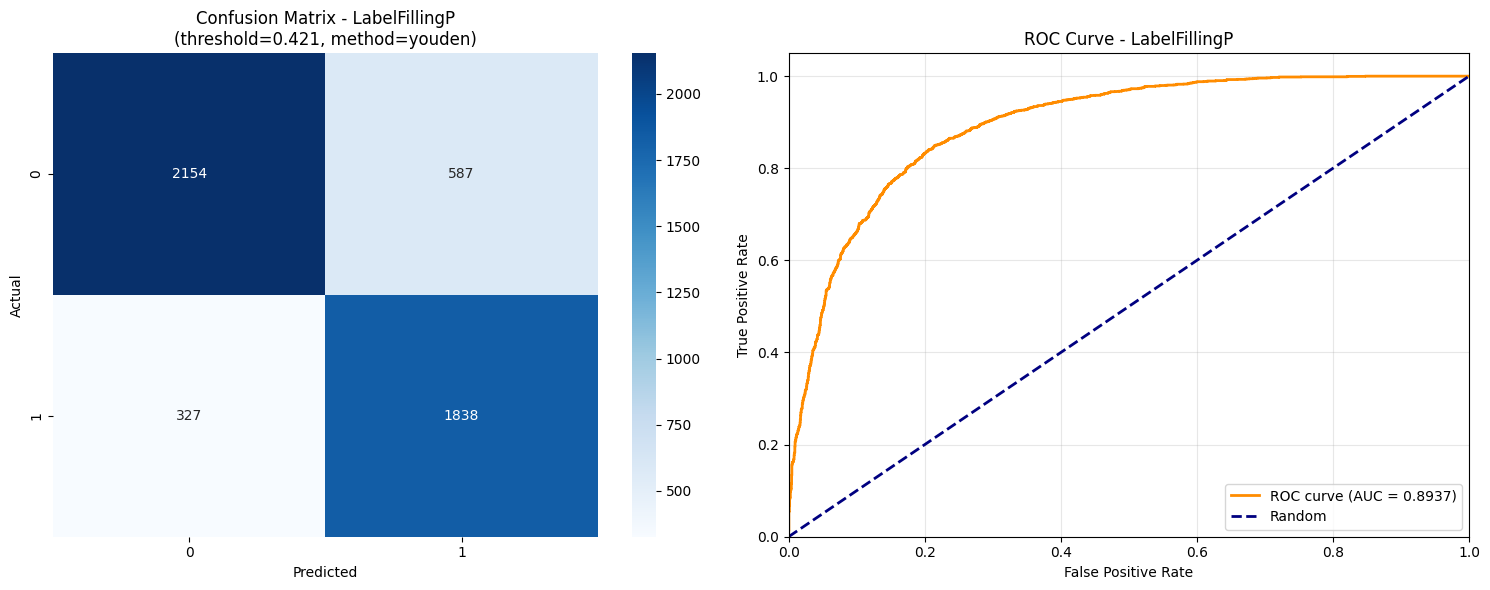

AUC: 0.8937
Threshold(youden): 0.4211
Accuracy: 0.8137
Precision: 0.7579
Recall: 0.8490
F1-Score: 0.8009

Evaluating LabelEF...


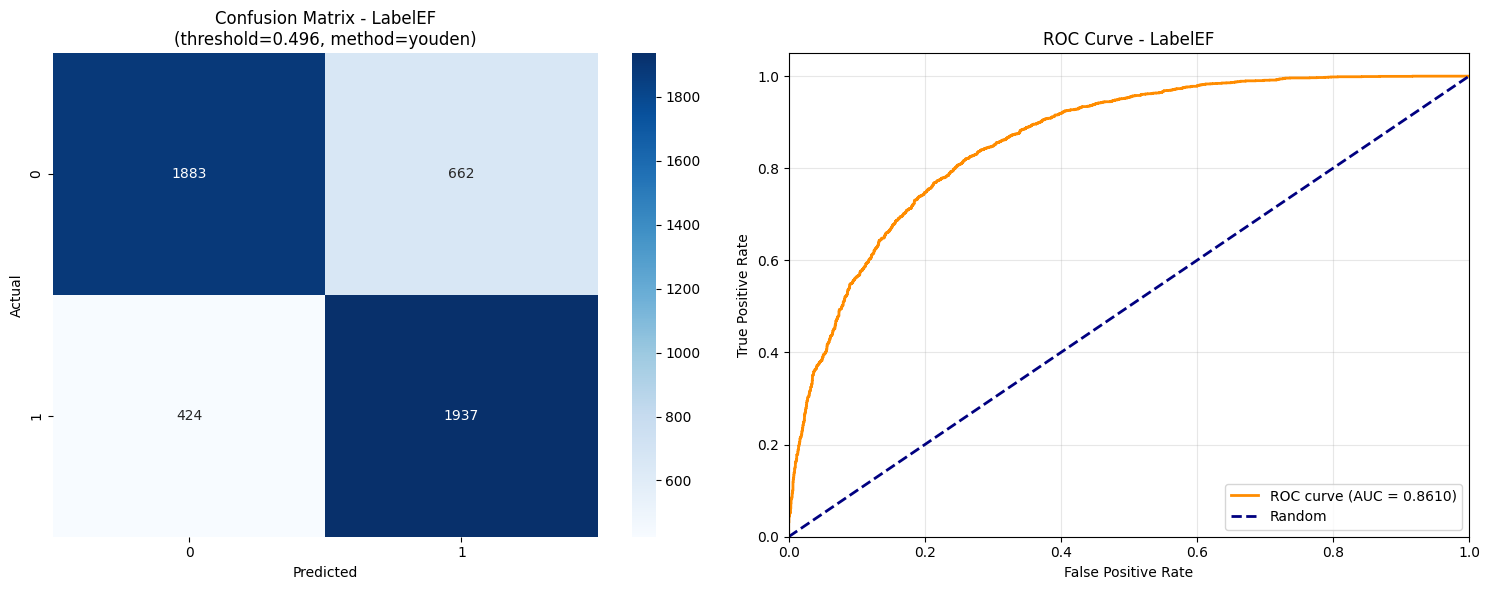

AUC: 0.8610
Threshold(youden): 0.4960
Accuracy: 0.7786
Precision: 0.7453
Recall: 0.8204
F1-Score: 0.7810

Evaluating LabelCO...


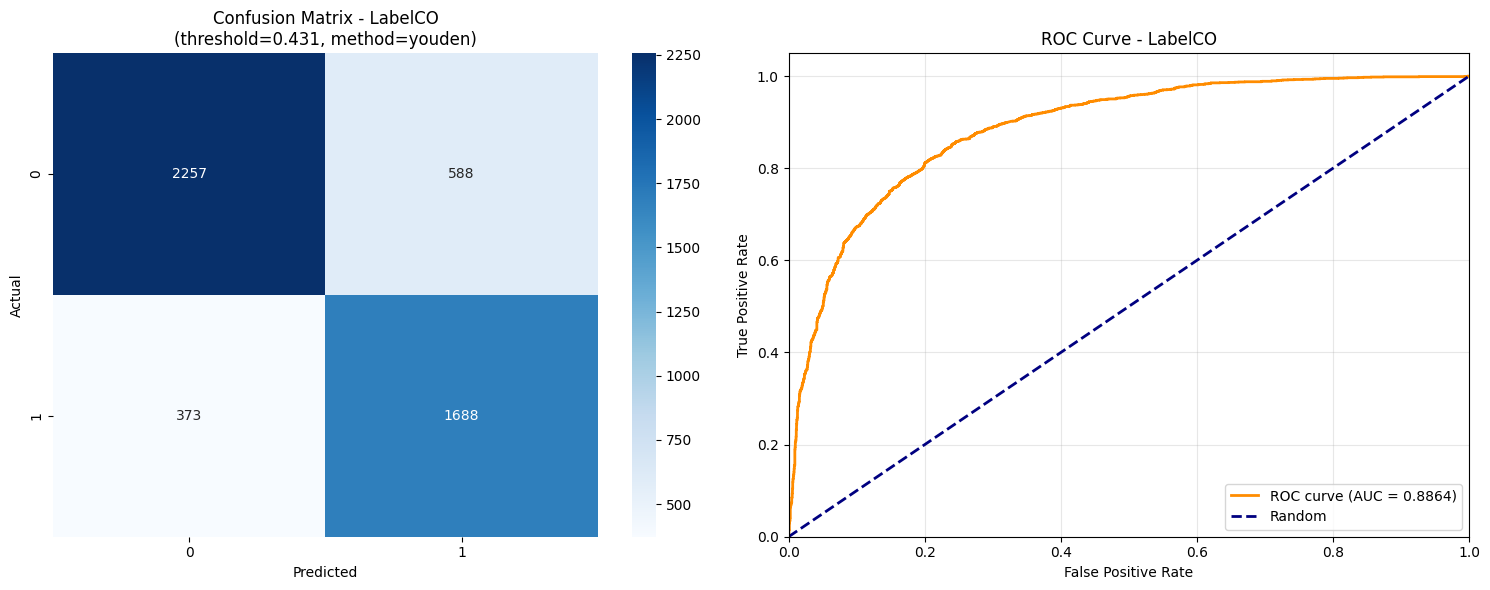

AUC: 0.8864
Threshold(youden): 0.4309
Accuracy: 0.8041
Precision: 0.7417
Recall: 0.8190
F1-Score: 0.7784

Evaluating LabelLAV...


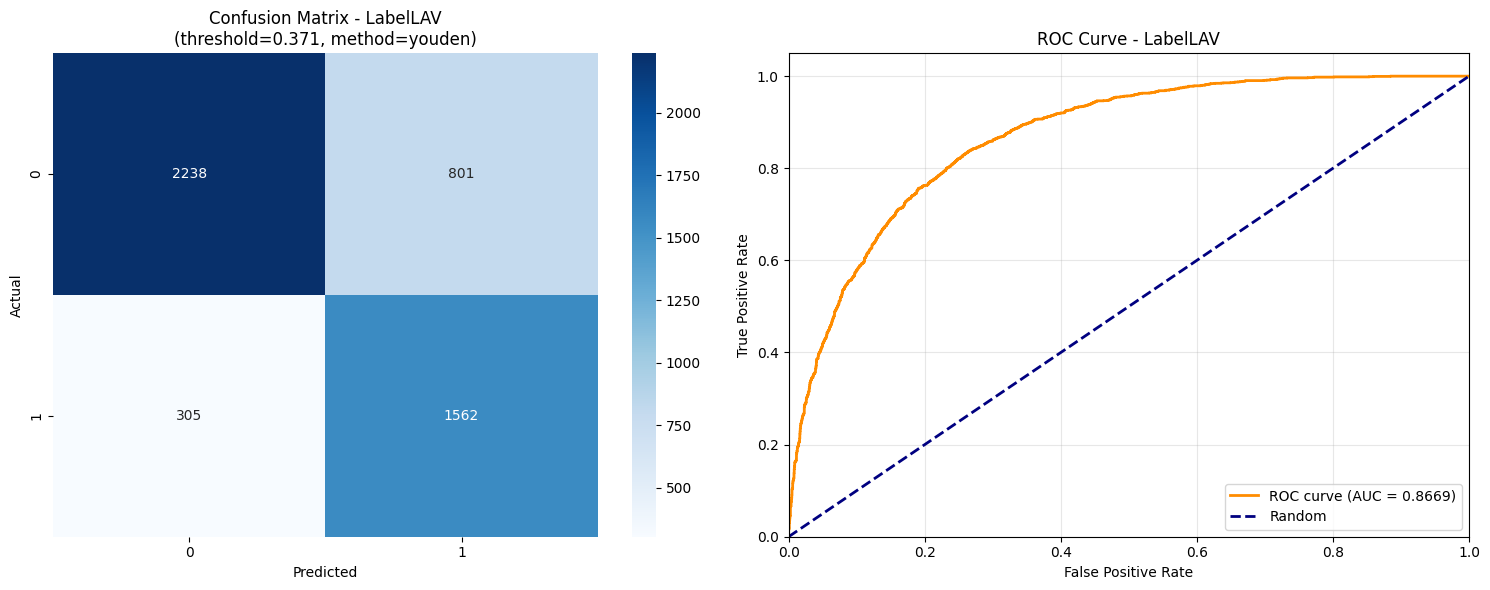

AUC: 0.8669
Threshold(youden): 0.3711
Accuracy: 0.7746
Precision: 0.6610
Recall: 0.8366
F1-Score: 0.7385

Evaluating LabelRVO2E...


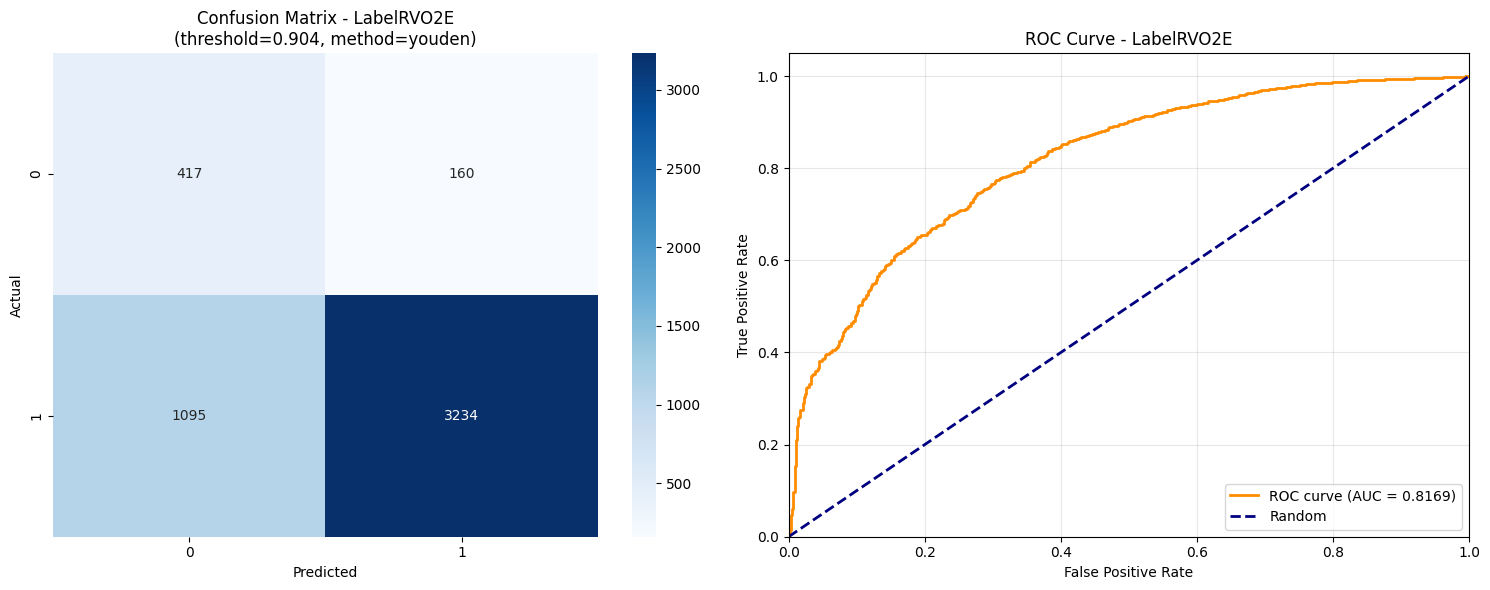

AUC: 0.8169
Threshold(youden): 0.9040
Accuracy: 0.7442
Precision: 0.9529
Recall: 0.7471
F1-Score: 0.8375

Evaluating LabelLVO2E...


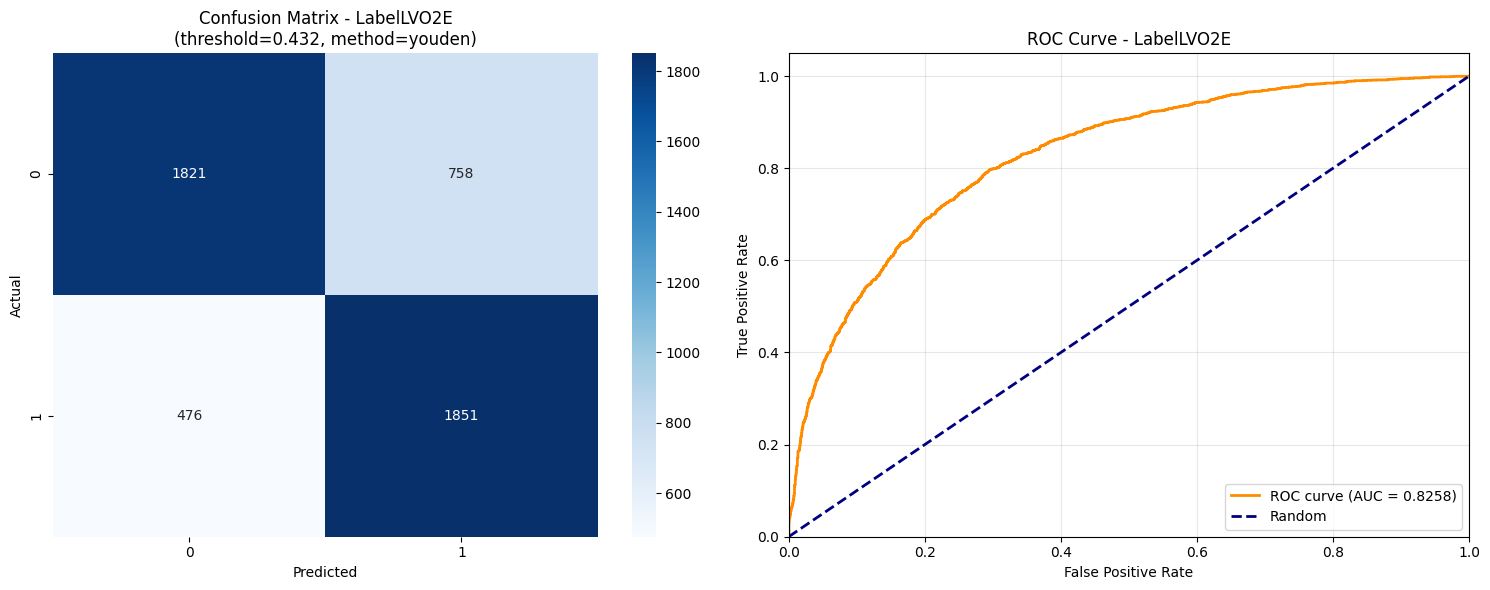

AUC: 0.8258
Threshold(youden): 0.4320
Accuracy: 0.7485
Precision: 0.7095
Recall: 0.7954
F1-Score: 0.7500

Evaluating LabelLVMVO2...


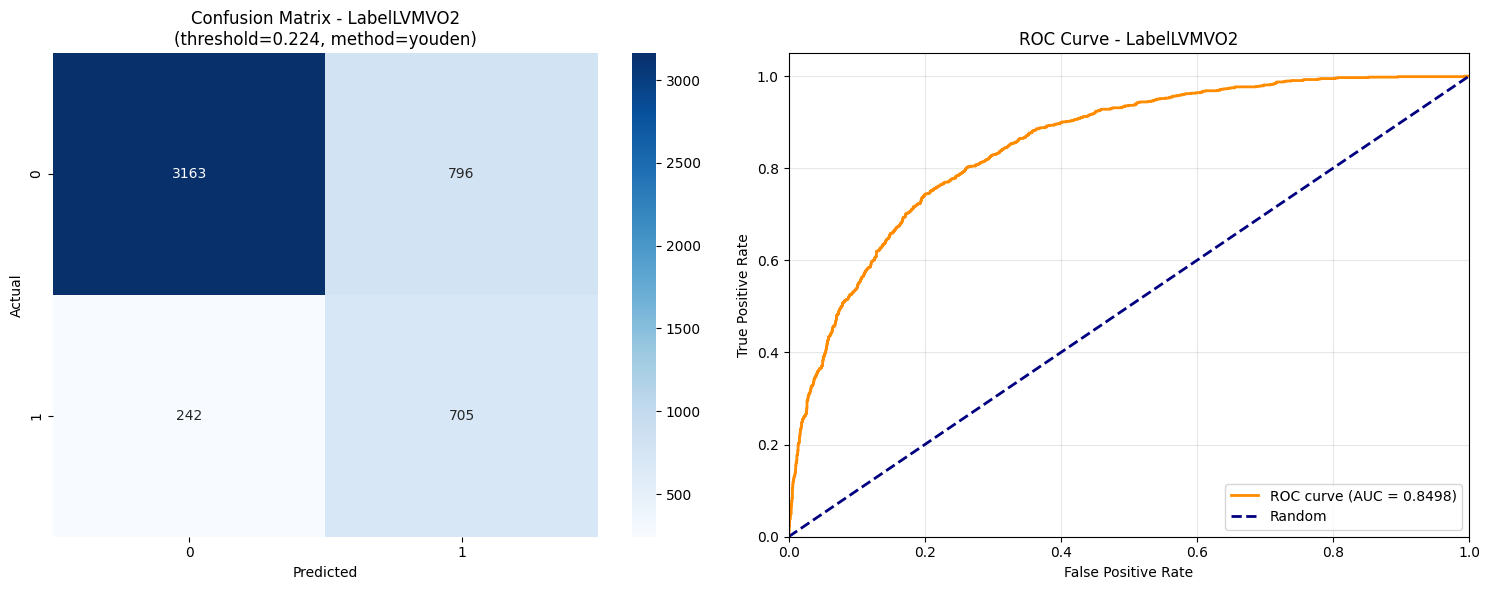

AUC: 0.8498
Threshold(youden): 0.2241
Accuracy: 0.7884
Precision: 0.4697
Recall: 0.7445
F1-Score: 0.5760

Evaluating LabelRVMVO2...


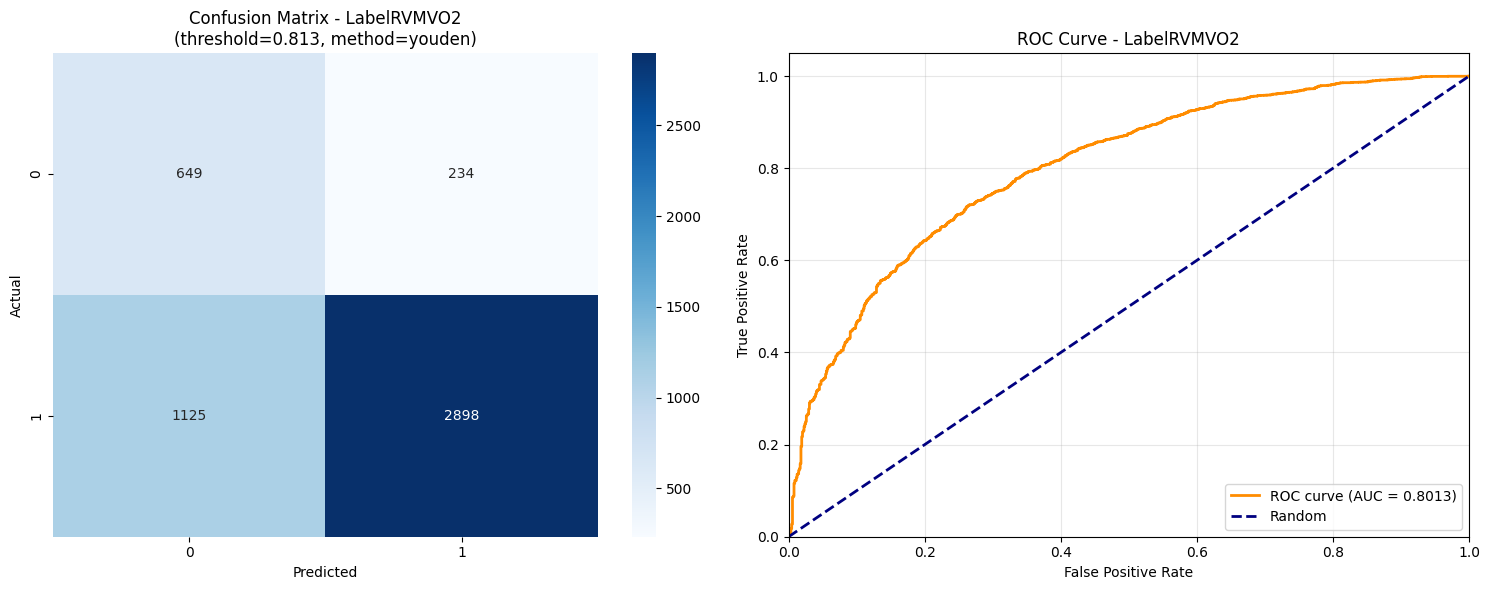

AUC: 0.8013
Threshold(youden): 0.8134
Accuracy: 0.7230
Precision: 0.9253
Recall: 0.7204
F1-Score: 0.8101

Evaluating LabelLVME...


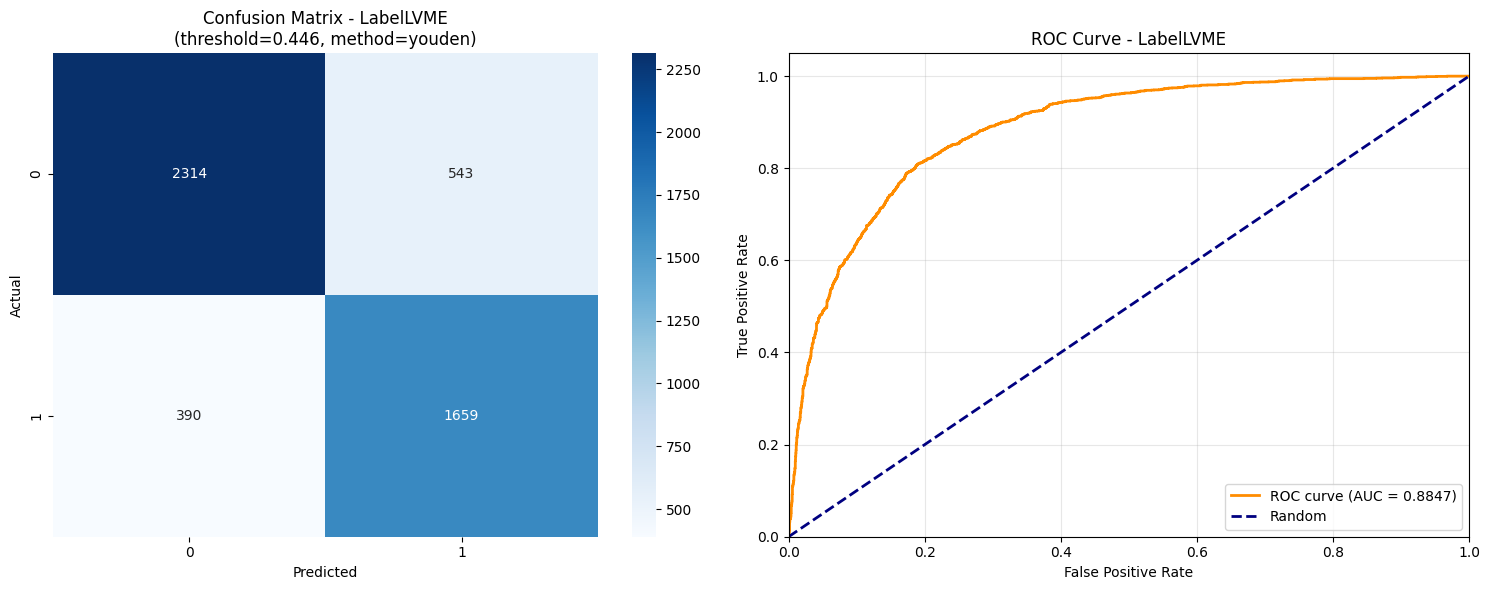

AUC: 0.8847
Threshold(youden): 0.4462
Accuracy: 0.8098
Precision: 0.7534
Recall: 0.8097
F1-Score: 0.7805

Evaluating LabelRVME...


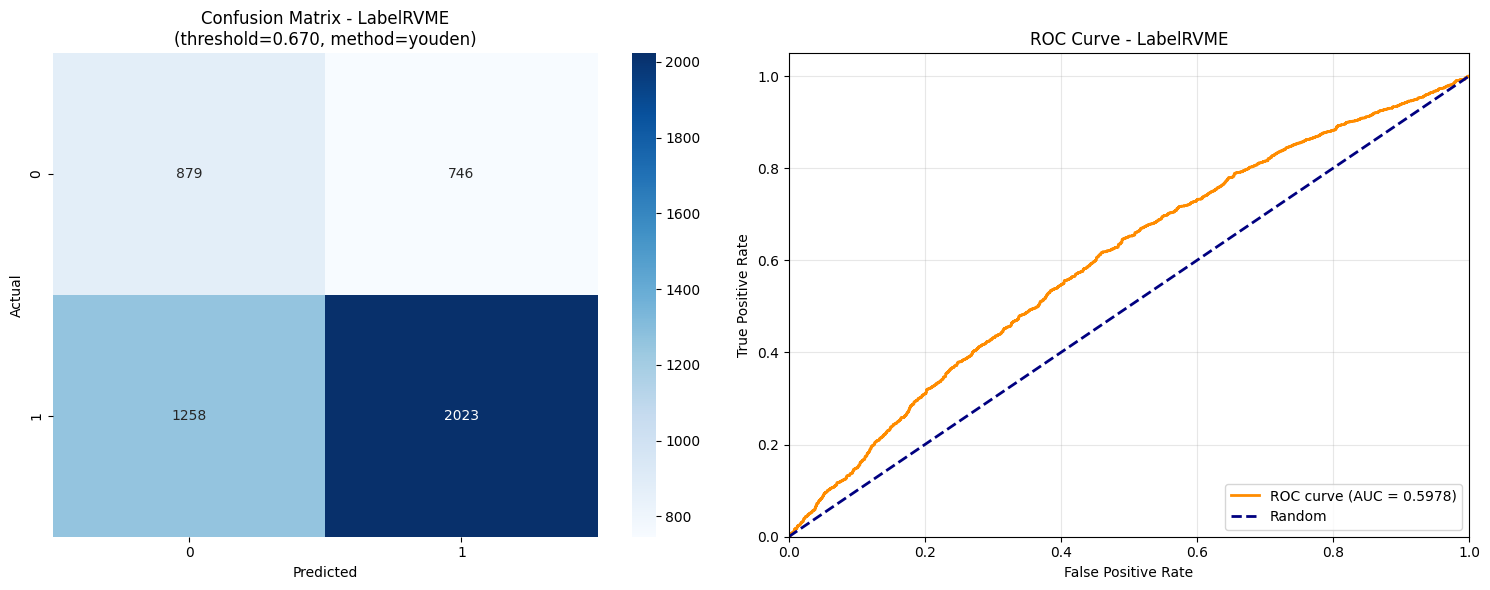

AUC: 0.5978
Threshold(youden): 0.6698
Accuracy: 0.5915
Precision: 0.7306
Recall: 0.6166
F1-Score: 0.6688

EVALUATION COMPLETED!
All plots saved in: evaluation_plots/

Per-label optimal thresholds (validation set):
  LabelFillingP  : 0.4211 (youden)
  LabelEF        : 0.4960 (youden)
  LabelCO        : 0.4309 (youden)
  LabelLAV       : 0.3711 (youden)
  LabelRVO2E     : 0.9040 (youden)
  LabelLVO2E     : 0.4320 (youden)
  LabelLVMVO2    : 0.2241 (youden)
  LabelRVMVO2    : 0.8134 (youden)
  LabelLVME      : 0.4462 (youden)
  LabelRVME      : 0.6698 (youden)


In [18]:
# Model Evaluation and Visualization (per-label optimal threshold on validation set)
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Threshold selection method: 'youden' (maximize TPR-FPR) or 'f1' (maximize F1 on val)
threshold_method = 'youden'

# Create directory for saving plots
plot_dir = "evaluation_plots"
os.makedirs(plot_dir, exist_ok=True)

print("="*80)
print("MODEL EVALUATION AND VISUALIZATION (Per-label Optimal Threshold)")
print("="*80)

# Dictionary to store all results
evaluation_results = {}
optimal_thresholds = {}

# Load and evaluate each trained model
for i in range(labels.shape[1]):
    label_name = labels.columns[i]
    print(f"\nEvaluating {label_name}...")

    # Load the best model
    model_path = os.path.join(save_dir, f"model_{label_name}_best.pth")
    if os.path.exists(model_path):
        # Initialize and load model
        eval_model = MLPClassifier(input_size=17).to(device)
        eval_model.load_state_dict(torch.load(model_path, map_location=device))
        eval_model.eval()

        # Get probabilities on validation set
        with torch.no_grad():
            X_val_tensor_device = X_val_tensor.to(device)
            val_outputs = eval_model(X_val_tensor_device)
            val_probs = val_outputs.cpu().numpy().flatten()
            val_true = y_val_tensor[:, i].numpy().astype(int)

        # ROC curve and AUC (independent of threshold)
        fpr, tpr, thresholds = roc_curve(val_true, val_probs)
        roc_auc = auc(fpr, tpr)
        val_auc = roc_auc  # keep naming consistent with prior

        # Choose optimal threshold per label
        if threshold_method == 'youden':
            J = tpr - fpr
            best_idx = int(np.argmax(J))
            best_thr = thresholds[best_idx]
        elif threshold_method == 'f1':
            # Skip the first threshold (inf); evaluate discrete ROC thresholds
            f1_vals = []
            thr_candidates = thresholds[1:] if len(thresholds) > 1 else thresholds
            for thr in thr_candidates:
                preds_tmp = (val_probs >= thr).astype(int)
                f1_vals.append(f1_score(val_true, preds_tmp))
            best_idx = int(np.argmax(f1_vals)) if len(f1_vals) else 0
            best_thr = thr_candidates[best_idx] if len(thr_candidates) else 0.5
        else:
            best_thr = 0.5
        optimal_thresholds[label_name] = float(best_thr)

        # Apply threshold to get predictions
        val_preds = (val_probs >= best_thr).astype(int)

        # Confusion Matrix and Classification Report
        cm = confusion_matrix(val_true, val_preds)
        report = classification_report(val_true, val_preds, output_dict=True)

        # Store results
        evaluation_results[label_name] = {
            'confusion_matrix': cm,
            'classification_report': report,
            'auc': val_auc,
            'fpr': fpr,
            'tpr': tpr,
            'roc_auc': roc_auc,
            'predictions': val_preds,
            'probabilities': val_probs,
            'true_labels': val_true,
            'threshold': float(best_thr),
            'threshold_method': threshold_method,
        }

        # Create subplot figure for this label
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))

        # Plot Confusion Matrix (based on optimal threshold)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
        axes[0].set_title(f'Confusion Matrix - {label_name}\n(threshold={best_thr:.3f}, method={threshold_method})')
        axes[0].set_xlabel('Predicted')
        axes[0].set_ylabel('Actual')

        # Plot ROC Curve (threshold-independent)
        axes[1].plot(fpr, tpr, color='darkorange', lw=2,
                     label=f'ROC curve (AUC = {roc_auc:.4f})')
        axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
        axes[1].set_xlim([0.0, 1.0])
        axes[1].set_ylim([0.0, 1.05])
        axes[1].set_xlabel('False Positive Rate')
        axes[1].set_ylabel('True Positive Rate')
        axes[1].set_title(f'ROC Curve - {label_name}')
        axes[1].legend(loc="lower right")
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(os.path.join(plot_dir, f'{label_name}_evaluation.png'), dpi=300, bbox_inches='tight')
        plt.show()

        # Print summary metrics
        print(f"AUC: {val_auc:.4f}")
        print(f"Threshold({threshold_method}): {best_thr:.4f}")
        print(f"Accuracy: {report['accuracy']:.4f}")
        if '1' in report:
            print(f"Precision: {report['1']['precision']:.4f}")
            print(f"Recall: {report['1']['recall']:.4f}")
            print(f"F1-Score: {report['1']['f1-score']:.4f}")

    else:
        print(f"Model file not found: {model_path}")

print("\n" + "="*80)
print("EVALUATION COMPLETED!")
print(f"All plots saved in: {plot_dir}/")
print("="*80)

# Quick table of thresholds per label
print("\nPer-label optimal thresholds (validation set):")
for lbl in labels.columns:
    if lbl in optimal_thresholds:
        print(f"  {lbl:15s}: {optimal_thresholds[lbl]:.4f} ({threshold_method})")
    else:
        print(f"  {lbl:15s}: N/A")

# 详细分析标签分布和相关性
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

print("="*80)
print("DETAILED LABEL ANALYSIS")
print("="*80)

# 1. 检查每个标签的类别分布
print("\n1. Label Distribution:")
print("-" * 50)
for i, col in enumerate(labels.columns):
    pos_count = labels[col].sum()
    neg_count = len(labels) - pos_count
    pos_ratio = pos_count / len(labels)
    print(f"{col:15s} | Positive: {pos_count:4d} ({pos_ratio:.3f}) | Negative: {neg_count:4d} ({1-pos_ratio:.3f}) | Ratio: {pos_count/neg_count:.3f}")

# 2. 标签之间的相关性矩阵
print(f"\n2. Label Correlation Matrix:")
print("-" * 50)
label_corr = labels.corr()
print(label_corr.round(3))

# 3. 可视化标签分布
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(labels.columns):
    labels[col].value_counts().plot(kind='bar', ax=axes[i], color=['lightblue', 'orange'])
    axes[i].set_title(f'{col}\nPositive Rate: {labels[col].mean():.3f}')
    axes[i].set_xlabel('Category (0=Negative, 1=Positive)')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('label_distribution_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. 检查最后一个标签与其他标签的关系
last_label = labels.columns[-1]
print(f"\n3. {last_label} vs Other Labels Analysis:")
print("-" * 50)

# 计算与其他标签的卡方检验
for col in labels.columns[:-1]:
    # 创建列联表
    contingency_table = pd.crosstab(labels[col], labels[last_label])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    
    # 计算Cramér's V (关联强度)
    n = contingency_table.sum().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))
    
    print(f"{col:15s} vs {last_label}: χ²={chi2:.3f}, p={p_value:.4f}, Cramér's V={cramers_v:.3f}")

# 5. 特征与最后一个标签的相关性
print(f"\n4. Feature Correlation with {last_label}:")
print("-" * 50)
feature_label_corr = []
for i, feat_col in enumerate(features.columns):
    corr = np.corrcoef(features[feat_col], labels[last_label])[0, 1]
    feature_label_corr.append((feat_col, corr))
    print(f"Feature {i+1:2d} ({feat_col:15s}): {corr:.4f}")

# 排序显示最相关的特征
feature_label_corr.sort(key=lambda x: abs(x[1]), reverse=True)
print(f"\nTop 5 Most Correlated Features:")
for feat, corr in feature_label_corr[:5]:
    print(f"{feat:15s}: {corr:.4f}")

# 深度分析 LabelRVME 的问题
print("\n" + "="*80)
print("LabelRVME In-depth Problem Analysis")
print("="*80)

last_label = 'LabelRVME'
last_label_idx = list(labels.columns).index(last_label)

# 1. 检查特征相关性强度
print(f"\n1. {last_label} Feature Correlation Issue:")
print("-" * 50)
max_corr = max([abs(np.corrcoef(features.iloc[:, i], labels[last_label])[0, 1]) for i in range(len(features.columns))])
print(f"Maximum correlation with features: {max_corr:.4f}")
print("⚠️  All feature correlations are extremely low (<0.1), this is the main cause of poor performance!")

# 2. 类别不平衡分析
pos_ratio = labels[last_label].mean()
imbalance_ratio = (1-pos_ratio) / pos_ratio if pos_ratio > 0 else float('inf')
print(f"\n2. Class Imbalance Analysis:")
print("-" * 50)
print(f"Positive ratio: {pos_ratio:.3f}")
print(f"Negative ratio: {1-pos_ratio:.3f}")
print(f"Imbalance ratio: {imbalance_ratio:.2f}:1")

if imbalance_ratio > 2:
    print("⚠️  Moderate class imbalance detected")

# 3. 与其他标签的共线性检查
print(f"\n3. Correlation Analysis with Other Labels:")
print("-" * 50)
other_label_corrs = []
for col in labels.columns:
    if col != last_label:
        corr = labels[col].corr(labels[last_label])
        other_label_corrs.append((col, corr))
        
other_label_corrs.sort(key=lambda x: abs(x[1]), reverse=True)
print("Correlations with other labels (sorted by strength):")
for label, corr in other_label_corrs[:5]:
    print(f"  {label:15s}: {corr:.4f}")

# 4. 检查训练数据的可分性
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

print(f"\n4. Data Separability Test:")
print("-" * 50)

# 使用简单的逻辑回归测试
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train[:, last_label_idx])
lr_pred_proba = lr.predict_proba(X_val)[:, 1]
lr_auc = roc_auc_score(y_val[:, last_label_idx], lr_pred_proba)

print(f"Logistic Regression baseline AUC: {lr_auc:.4f}")
if lr_auc < 0.7:
    print("⚠️  Even linear models perform poorly, data itself may have issues")

# 5. 检查噪声水平
print(f"\n5. Data Quality Analysis:")
print("-" * 50)

# 计算特征的信息增益
from sklearn.feature_selection import mutual_info_classif
mi_scores = mutual_info_classif(X_train, y_train[:, last_label_idx], random_state=42)
max_mi = max(mi_scores)
print(f"Maximum mutual information score: {max_mi:.4f}")
if max_mi < 0.1:
    print("⚠️  Low mutual information between features and target, possible noise")

# 6. 建议的解决方案
print(f"\n6. Suggested Solutions:")
print("-" * 50)
print("Possible reasons for poor LabelRVME performance:")
print("1. Extremely low feature correlation - existing features contribute little")
print("2. Data may contain noise or annotation errors")
print("3. Need more relevant features or feature engineering")
print("\nRecommended approaches:")
print("• Feature combinations/interactions")
print("• Different loss functions (Focal Loss for imbalance)")
print("• Ensemble methods")
print("• Data cleaning and re-annotation")

# 关于神经网络复杂度的分析
print("\n" + "="*80)
print("Neural Network Complexity Impact Analysis for LabelRVME")
print("="*80)

print("""
Analysis on whether to increase neural network complexity (more neurons/hidden layers):

🔍 Current Network Structure: 17 → 64 → 32 → 1
📊 Data Scale: ~25,000 samples, 17 features

❌ Why increasing complexity may be ineffective:

1. Extremely low feature correlation (max=0.086)
   • Even with infinite model capacity, cannot extract useful info from uncorrelated features
   • This is a data problem, not a model problem

2. Overfitting risk
   • Current dropout=0.5 is already high, indicating model prone to overfitting
   • More complex models will exacerbate this issue
   • Validation AUC stagnating at 0.6 suggests model reached data's information limit

3. Simple baseline performs equally poorly
   • Logistic regression AUC=0.585, barely different from complex MLP
   • Indicates poor linear/non-linear separability of data

✅ More effective approaches:

1. Feature Engineering > Model Complexity
   • Feature interactions: LVEDV × LVESV
   • Feature ratios: LVESV/LVEDV
   • Domain knowledge-driven feature combinations

2. Data Quality Improvement
   • Check annotation consistency
   • Outlier handling
   • Add more relevant features

3. Loss Function Optimization
   • Focal Loss for hard samples
   • Class-balanced loss
   • Custom weights

📊 Suggested experiment order:
1. Try feature engineering first (low cost, potentially significant effect)
2. Check data quality
3. Only then consider model complexity adjustments

Conclusion: With extremely low feature correlation, increasing neural network complexity 
           is usually ineffective and potentially harmful. Should prioritize data and 
           feature issues first.
""")

# 可视化特征重要性
print("\nFeature Correlation with LabelRVME Visualization:")
feature_names = features.columns.tolist()
correlations = [np.corrcoef(features[col], labels['LabelRVME'])[0, 1] for col in feature_names]

plt.figure(figsize=(12, 8))
colors = ['red' if abs(c) < 0.05 else 'orange' if abs(c) < 0.1 else 'green' for c in correlations]
bars = plt.barh(range(len(feature_names)), correlations, color=colors)
plt.yticks(range(len(feature_names)), feature_names)
plt.xlabel('Correlation with LabelRVME')
plt.title('Feature Correlation Analysis - LabelRVME\nRed: Very Low (<0.05), Orange: Low (<0.1), Green: Moderate (≥0.1)')
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.axvline(x=0.1, color='red', linestyle='--', alpha=0.5, label='Expected Min Correlation')
plt.axvline(x=-0.1, color='red', linestyle='--', alpha=0.5)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('feature_correlation_RVME.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Average absolute correlation of all features: {np.mean([abs(c) for c in correlations]):.4f}")
print("📊 Conclusion: Average correlation extremely low, increasing model complexity won't significantly improve performance")

EXTERNAL VALIDATION SET EVALUATION
✓ Successfully loaded external validation data: inputFGclassifier146.CSV

External validation data shape:
Features shape: (146, 17)
Labels shape: (146, 10)
External validation tensor size: torch.Size([146, 17])
External validation labels columns: ['LabelFillingP', 'LabelEF', 'LabelCO', 'LabelLAV', 'LabelRVO2E', 'LabelLVO2E', 'LabelLVMVO2', 'LabelRVMVO2', 'LabelLVME', 'LabelRVME']

EVALUATING ALL CLASSIFIERS ON EXTERNAL VALIDATION SET (fixed thresholds)

External Validation: LabelFillingP


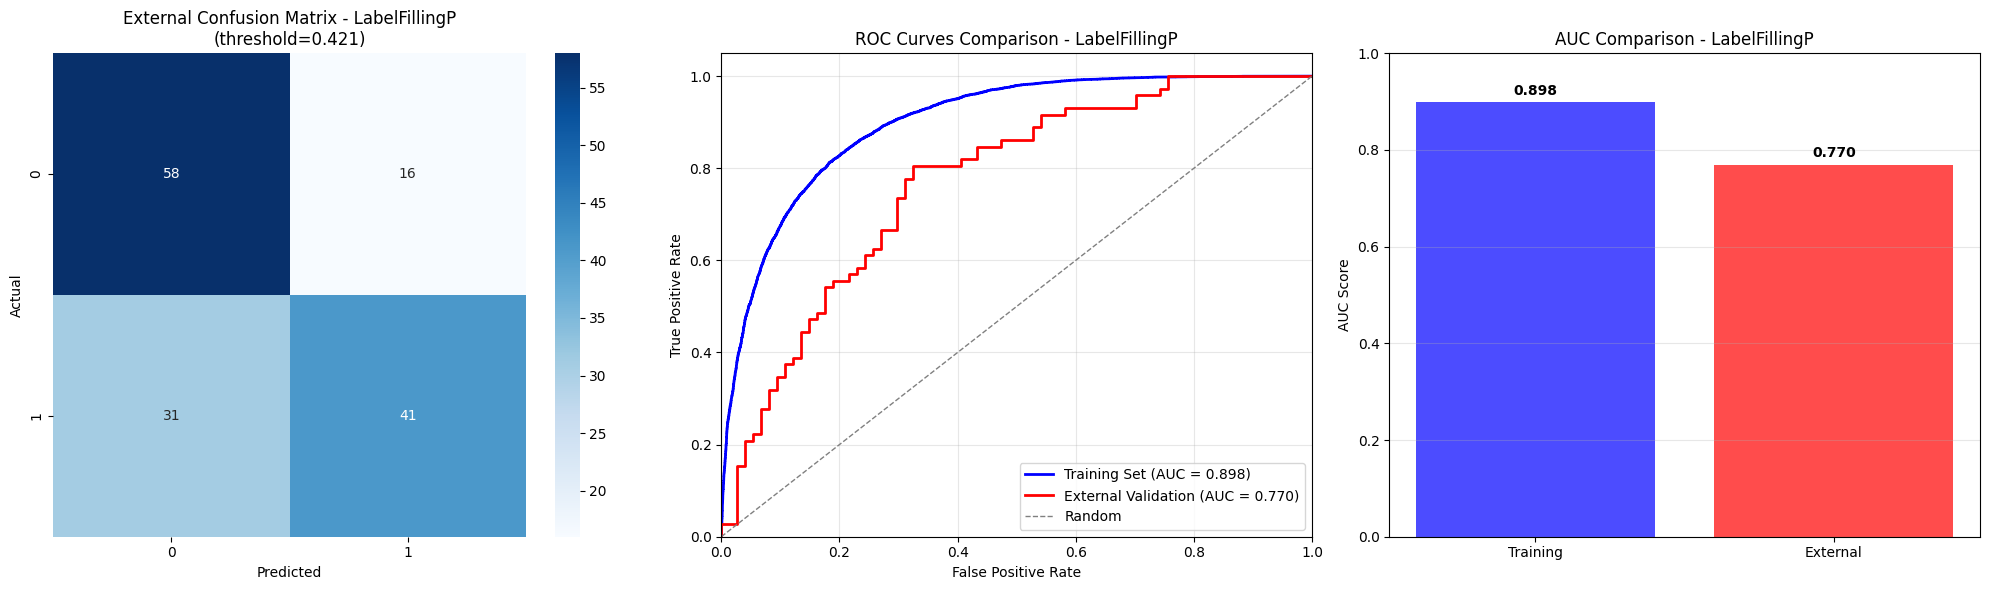

External Validation Results (thr=0.4211):
  AUC: 0.7697
  Accuracy: 0.6781
  Precision: 0.7193
  Recall: 0.5694
  F1-Score: 0.6357
Training vs External AUC Difference: 0.1284
⚠️  Large performance drop detected - possible overfitting

External Validation: LabelEF


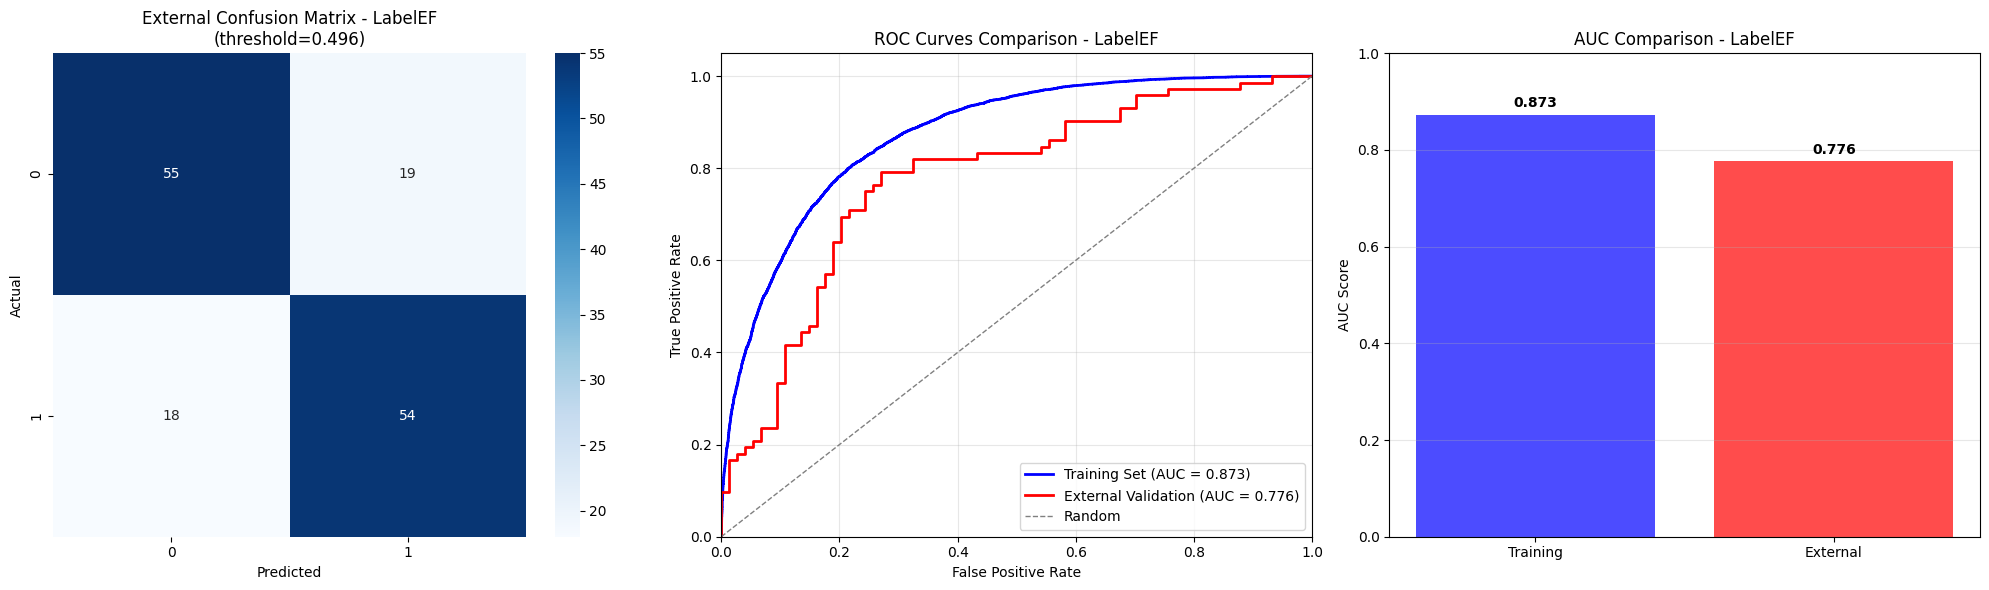

External Validation Results (thr=0.4960):
  AUC: 0.7761
  Accuracy: 0.7466
  Precision: 0.7397
  Recall: 0.7500
  F1-Score: 0.7448
Training vs External AUC Difference: 0.0969
✓ Acceptable performance on external validation

External Validation: LabelCO


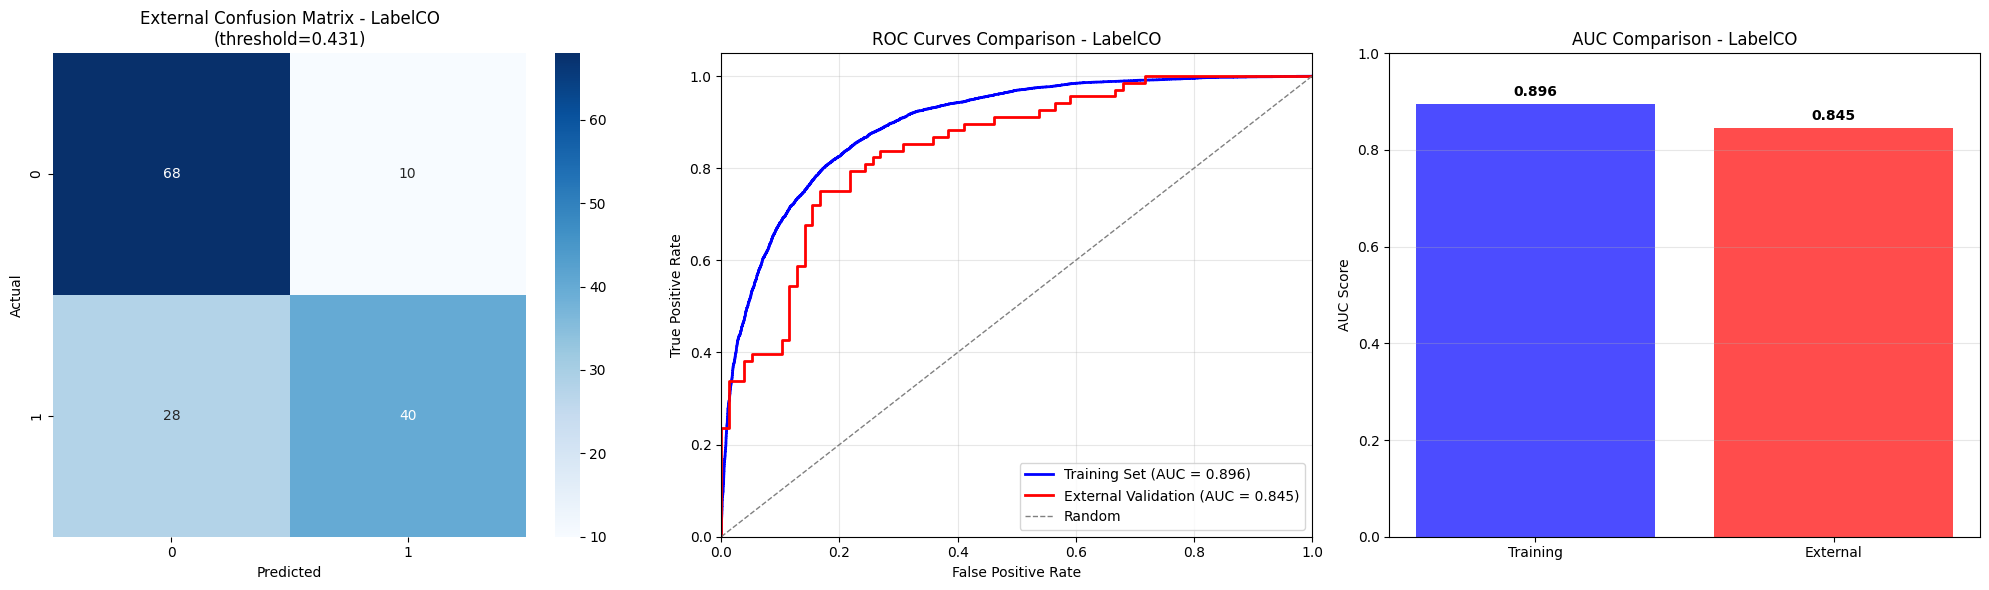

External Validation Results (thr=0.4309):
  AUC: 0.8454
  Accuracy: 0.7397
  Precision: 0.8000
  Recall: 0.5882
  F1-Score: 0.6780
Training vs External AUC Difference: 0.0504
✓ Acceptable performance on external validation

External Validation: LabelLAV


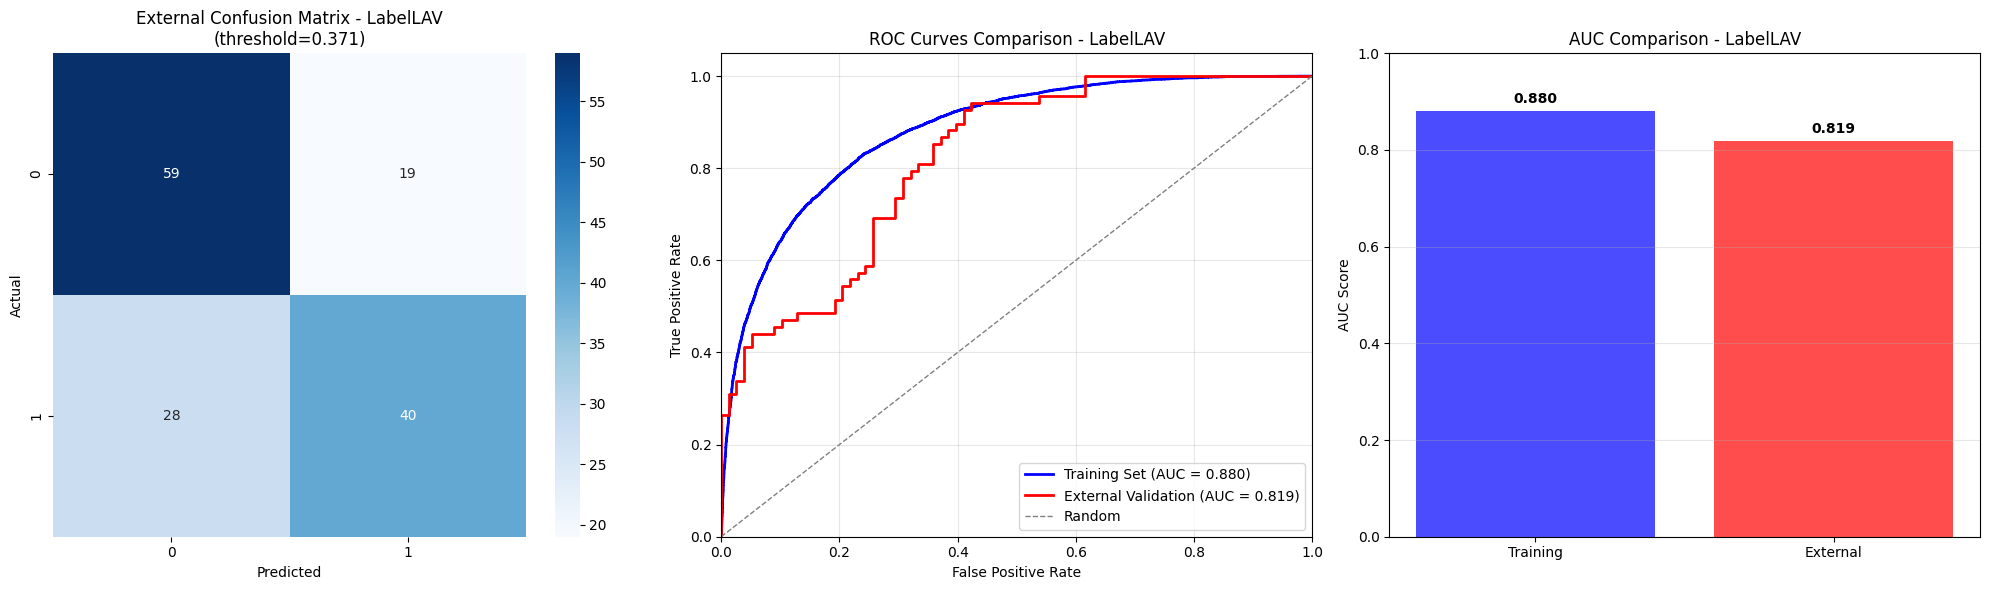

External Validation Results (thr=0.3711):
  AUC: 0.8190
  Accuracy: 0.6781
  Precision: 0.6780
  Recall: 0.5882
  F1-Score: 0.6299
Training vs External AUC Difference: 0.0608
✓ Acceptable performance on external validation

External Validation: LabelRVO2E


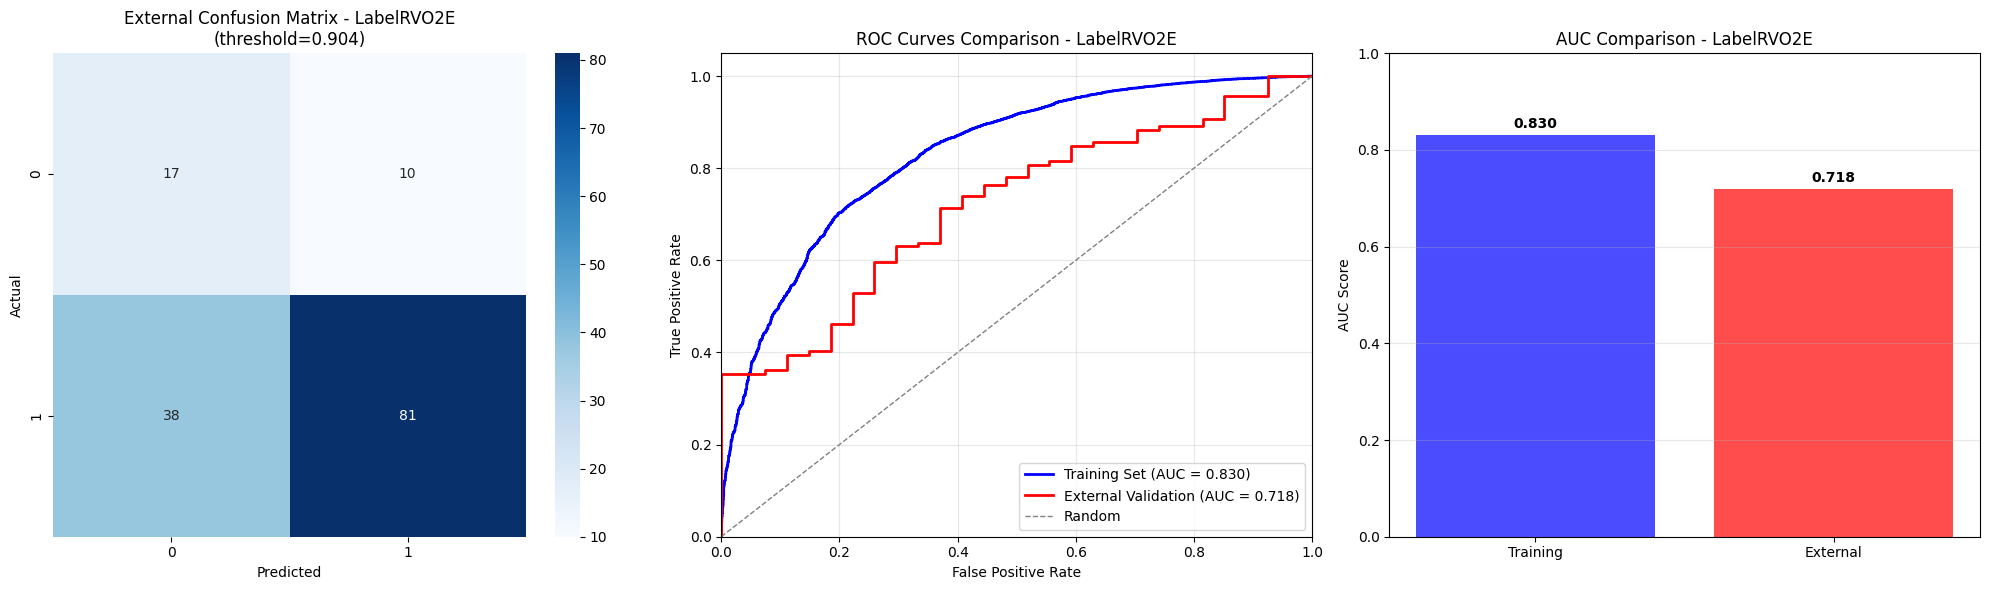

External Validation Results (thr=0.9040):
  AUC: 0.7183
  Accuracy: 0.6712
  Precision: 0.8901
  Recall: 0.6807
  F1-Score: 0.7714
Training vs External AUC Difference: 0.1116
⚠️  Large performance drop detected - possible overfitting

External Validation: LabelLVO2E


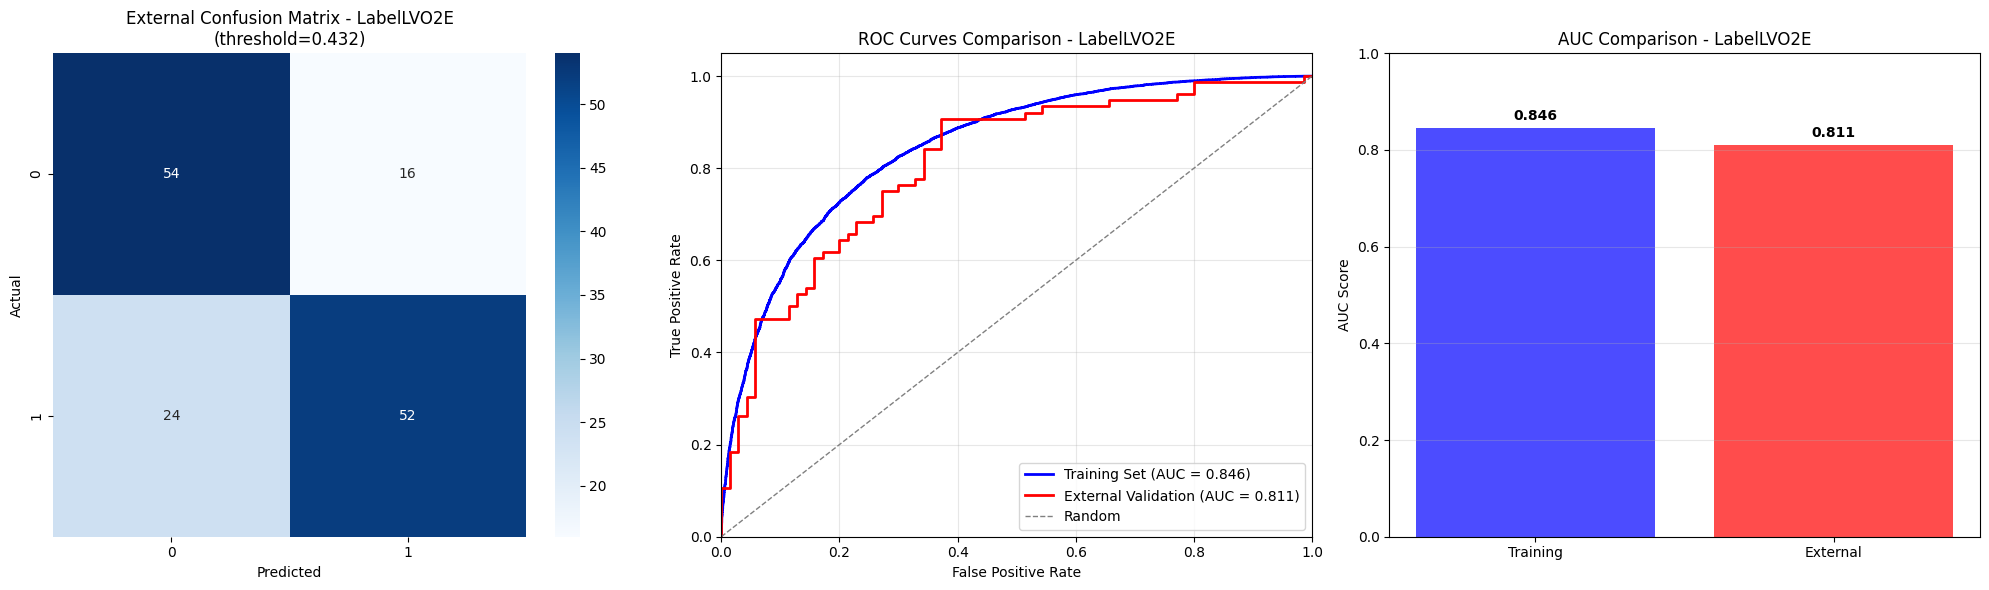

External Validation Results (thr=0.4320):
  AUC: 0.8105
  Accuracy: 0.7260
  Precision: 0.7647
  Recall: 0.6842
  F1-Score: 0.7222
Training vs External AUC Difference: 0.0355
✓ Acceptable performance on external validation

External Validation: LabelLVMVO2


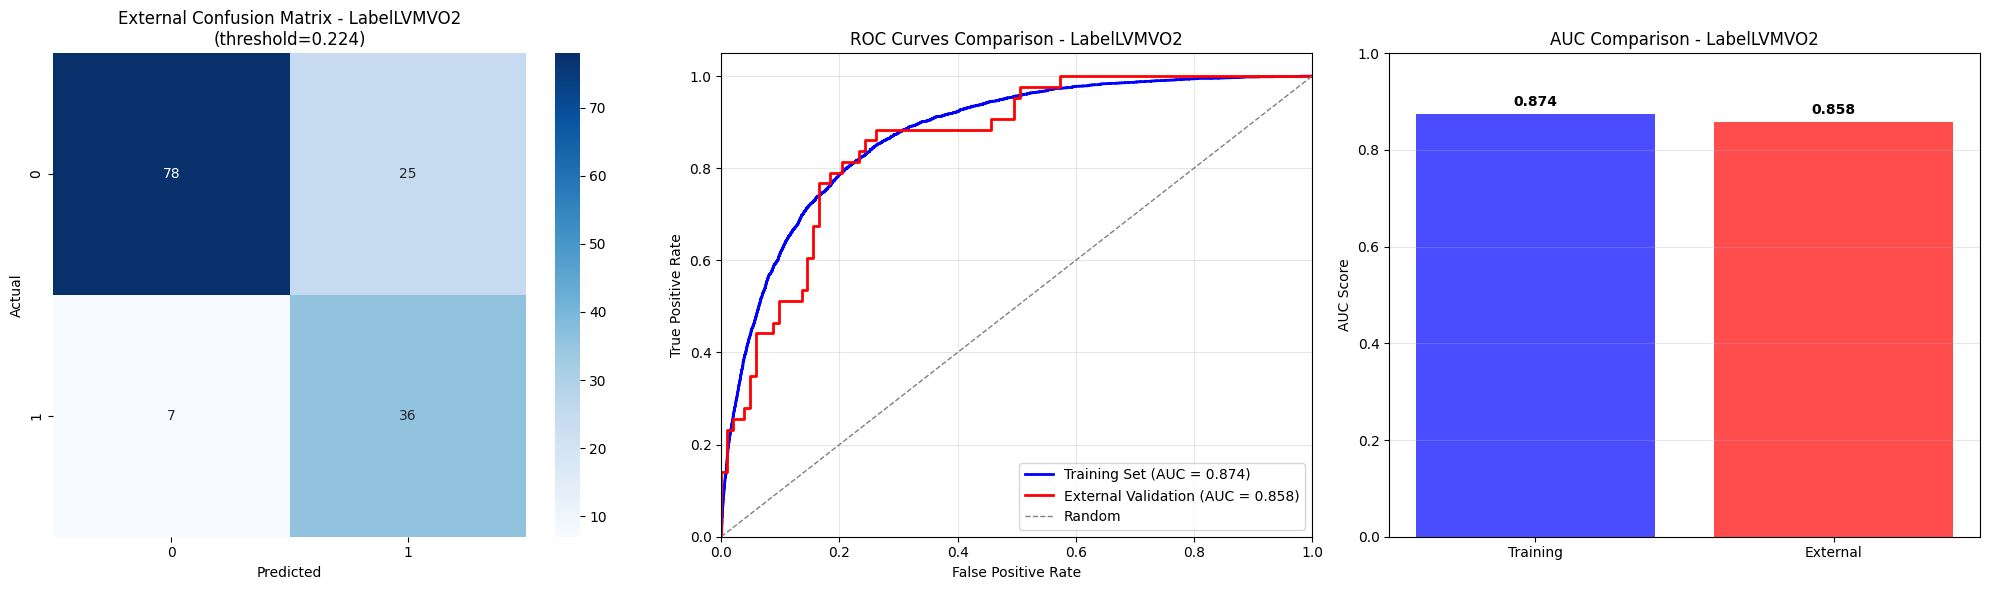

External Validation Results (thr=0.2241):
  AUC: 0.8580
  Accuracy: 0.7808
  Precision: 0.5902
  Recall: 0.8372
  F1-Score: 0.6923
Training vs External AUC Difference: 0.0158
✓ Acceptable performance on external validation

External Validation: LabelRVMVO2


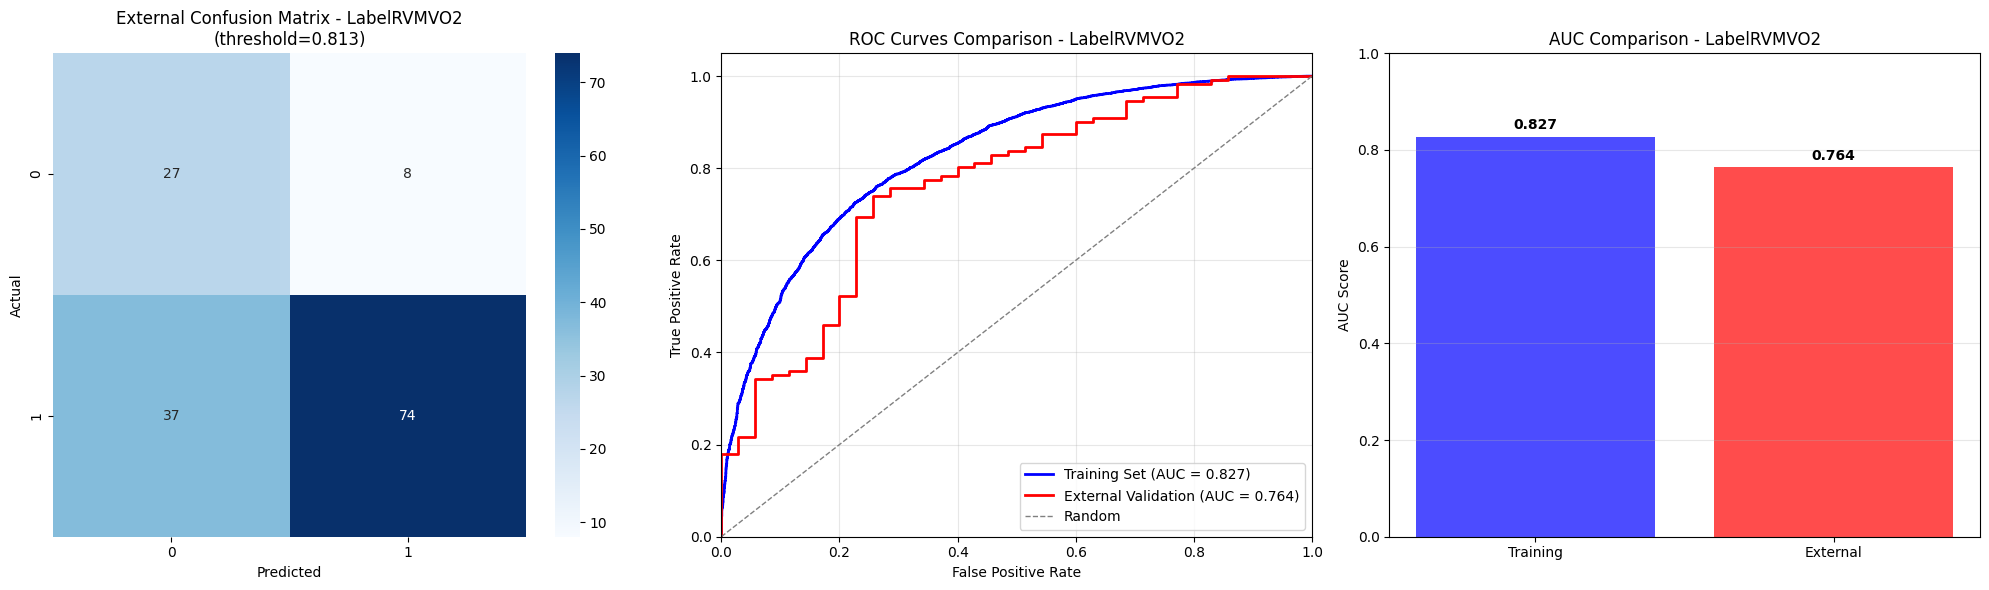

External Validation Results (thr=0.8134):
  AUC: 0.7637
  Accuracy: 0.6918
  Precision: 0.9024
  Recall: 0.6667
  F1-Score: 0.7668
Training vs External AUC Difference: 0.0638
✓ Acceptable performance on external validation

External Validation: LabelLVME


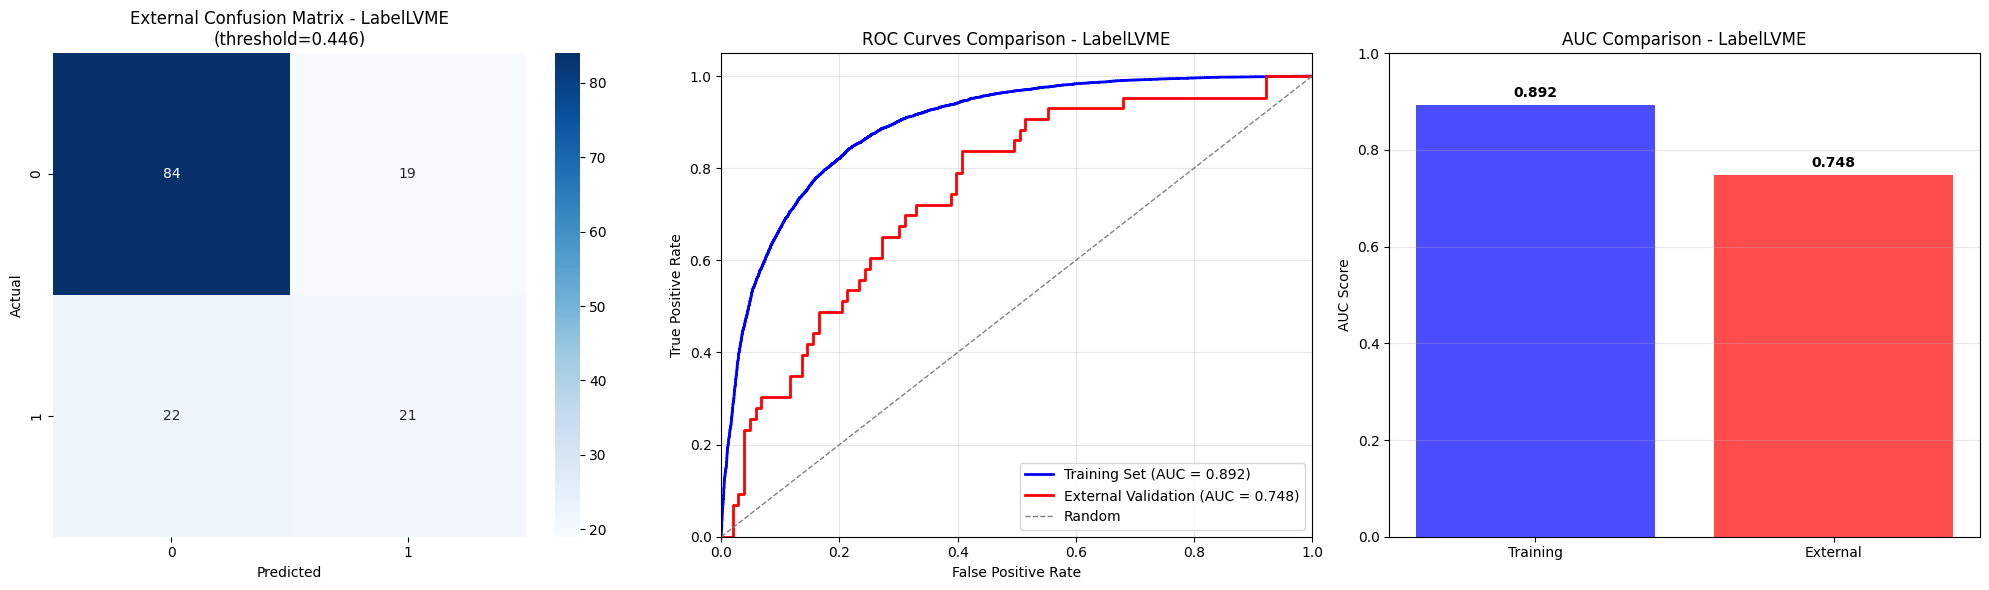

External Validation Results (thr=0.4462):
  AUC: 0.7476
  Accuracy: 0.7192
  Precision: 0.5250
  Recall: 0.4884
  F1-Score: 0.5060
Training vs External AUC Difference: 0.1446
⚠️  Large performance drop detected - possible overfitting

External Validation: LabelRVME


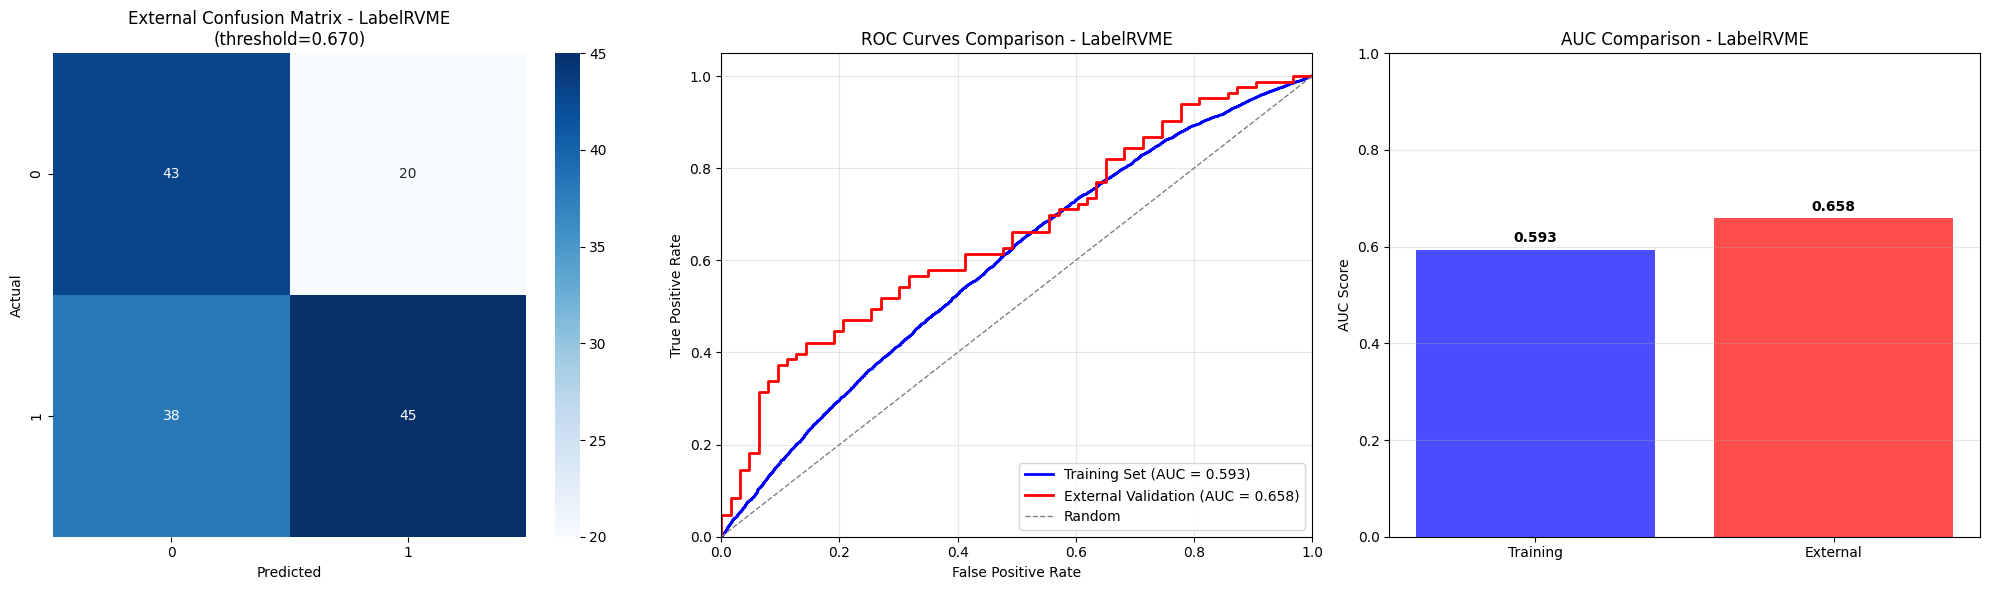

External Validation Results (thr=0.6698):
  AUC: 0.6581
  Accuracy: 0.6027
  Precision: 0.6923
  Recall: 0.5422
  F1-Score: 0.6081
Training vs External AUC Difference: -0.0653
✓ External validation performance better than training - good generalization

EXTERNAL VALIDATION COMPLETED!
All external validation plots saved in: external_validation_plots/

SUMMARY: Training vs External Validation Performance
Label           Train AUC  External AUC  Diff       Thr
----------------------------------------------------------------------
LabelFillingP   0.8981     0.7697        0.1284     0.421
LabelEF         0.8730     0.7761        0.0969     0.496
LabelCO         0.8958     0.8454        0.0504     0.431
LabelLAV        0.8798     0.8190        0.0608     0.371
LabelRVO2E      0.8299     0.7183        0.1116     0.904
LabelLVO2E      0.8460     0.8105        0.0355     0.432
LabelLVMVO2     0.8738     0.8580        0.0158     0.224
LabelRVMVO2     0.8275     0.7637        0.0638     0.813
Lab

In [7]:
# External Validation Set Evaluation (using fixed per-label thresholds from validation)
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Ensure thresholds dict exists
if 'optimal_thresholds' not in globals():
    optimal_thresholds = {}

# Load external validation dataset
print("="*80)
print("EXTERNAL VALIDATION SET EVALUATION")
print("="*80)

# Load the external validation data
df_external = pd.read_csv('inputFGclassifier146.CSV')
print(f"✓ Successfully loaded external validation data: inputFGclassifier146.CSV")

# Preprocess external validation data (same as training data preprocessing)
external_processed = df_external.drop(df_external.columns[[0, 12]], axis=1)
external_features = external_processed.iloc[:, 0:17]
external_labels = external_processed.iloc[:, -10:]

print(f"\nExternal validation data shape:")
print(f"Features shape: {external_features.shape}")
print(f"Labels shape: {external_labels.shape}")

# Normalize external features using the same preprocessing pipeline as training
external_continuous = external_features.iloc[:, 1:-1]
external_normalized = scaler.transform(external_continuous)  # Use existing scaler from training

# Combine binary and normalized continuous features (same as training)
external_normalized_df = pd.DataFrame(external_normalized, columns=external_continuous.columns)
external_normalized_df.insert(0, external_features.columns[0], external_features.iloc[:, 0])  # First binary column
external_normalized_df[external_features.columns[-1]] = external_features.iloc[:, -1]  # Last binary column

# Convert to PyTorch tensor
X_external_tensor = torch.tensor(external_normalized_df.values, dtype=torch.float32)

print(f"External validation tensor size: {X_external_tensor.size()}")
print(f"External validation labels columns: {external_labels.columns.tolist()}")

# Create directory for external validation plots
external_plot_dir = "external_validation_plots"
os.makedirs(external_plot_dir, exist_ok=True)

print("\n" + "="*80)
print("EVALUATING ALL CLASSIFIERS ON EXTERNAL VALIDATION SET (fixed thresholds)")
print("="*80)

# Dictionary to store external validation results
external_results = {}

# Evaluate each trained model on external validation set
for i in range(labels.shape[1]):
    label_name = labels.columns[i]
    print(f"\n{'='*60}")
    print(f"External Validation: {label_name}")
    print(f"{'='*60}")

    # Load the best model
    model_path = os.path.join(save_dir, f"model_{label_name}_best.pth")
    if os.path.exists(model_path):
        # Initialize and load model
        eval_model = MLPClassifier(input_size=17).to(device)
        eval_model.load_state_dict(torch.load(model_path, map_location=device))
        eval_model.eval()

        # Get predictions on external validation set
        with torch.no_grad():
            X_external_device = X_external_tensor.to(device)
            external_outputs = eval_model(X_external_device)
            external_probs = external_outputs.cpu().numpy().flatten()
            external_true = external_labels.iloc[:, i].values.astype(int)

        # Use fixed per-label threshold learned on validation; fallback 0.5
        thr = float(optimal_thresholds.get(label_name, 0.5))
        external_preds = (external_probs >= thr).astype(int)

        # Get training set predictions for comparison (probabilities only)
        with torch.no_grad():
            X_train_device = X_train_tensor.to(device)
            train_outputs = eval_model(X_train_device)
            train_probs = train_outputs.cpu().numpy().flatten()
            train_true = y_train_tensor[:, i].numpy().astype(int)

        # Calculate metrics for external validation
        external_auc = roc_auc_score(external_true, external_probs)
        external_cm = confusion_matrix(external_true, external_preds)
        external_report = classification_report(external_true, external_preds, output_dict=True)

        # Calculate ROC curves
        external_fpr, external_tpr, _ = roc_curve(external_true, external_probs)
        train_fpr, train_tpr, _ = roc_curve(train_true, train_probs)

        # Store results
        external_results[label_name] = {
            'external_auc': external_auc,
            'external_cm': external_cm,
            'external_report': external_report,
            'external_fpr': external_fpr,
            'external_tpr': external_tpr,
            'threshold': thr,
        }

        # Create comprehensive visualization
        fig, axes = plt.subplots(1, 3, figsize=(20, 6))

        # 1. External Validation Confusion Matrix
        sns.heatmap(external_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
        axes[0].set_title(f'External Confusion Matrix - {label_name}\n(threshold={thr:.3f})')
        axes[0].set_xlabel('Predicted')
        axes[0].set_ylabel('Actual')

        # 2. Training vs External ROC Comparison (threshold-independent)
        axes[1].plot(train_fpr, train_tpr, color='blue', lw=2,
                    label=f'Training Set (AUC = {roc_auc_score(train_true, train_probs):.3f})')
        axes[1].plot(external_fpr, external_tpr, color='red', lw=2,
                    label=f'External Validation (AUC = {external_auc:.3f})')
        axes[1].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random')
        axes[1].set_xlim([0.0, 1.0])
        axes[1].set_ylim([0.0, 1.05])
        axes[1].set_xlabel('False Positive Rate')
        axes[1].set_ylabel('True Positive Rate')
        axes[1].set_title(f'ROC Curves Comparison - {label_name}')
        axes[1].legend(loc="lower right")
        axes[1].grid(True, alpha=0.3)

        # 3. Performance Metrics Comparison (AUC)
        train_auc = roc_auc_score(train_true, train_probs)
        bars = axes[2].bar(['Training', 'External'], [train_auc, external_auc],
                          color=['blue', 'red'], alpha=0.7)
        axes[2].set_ylim([0, 1])
        axes[2].set_ylabel('AUC Score')
        axes[2].set_title(f'AUC Comparison - {label_name}')
        axes[2].grid(True, alpha=0.3, axis='y')
        for bar, value in zip(bars, [train_auc, external_auc]):
            height = bar.get_height()
            axes[2].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                        f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

        plt.tight_layout()
        plt.savefig(os.path.join(external_plot_dir, f'{label_name}_external_validation.png'),
                   dpi=300, bbox_inches='tight')
        plt.show()

        # Print detailed metrics
        print(f"External Validation Results (thr={thr:.4f}):")
        print(f"  AUC: {external_auc:.4f}")
        print(f"  Accuracy: {external_report['accuracy']:.4f}")
        if '1' in external_report:
            print(f"  Precision: {external_report['1']['precision']:.4f}")
            print(f"  Recall: {external_report['1']['recall']:.4f}")
            print(f"  F1-Score: {external_report['1']['f1-score']:.4f}")

        diff = train_auc - external_auc
        print(f"Training vs External AUC Difference: {diff:.4f}")
        if abs(diff) > 0.1:
            print("⚠️  Large performance drop detected - possible overfitting")
        elif external_auc > train_auc:
            print("✓ External validation performance better than training - good generalization")
        else:
            print("✓ Acceptable performance on external validation")

    else:
        print(f"❌ Model file not found: {model_path}")

print("\n" + "="*80)
print("EXTERNAL VALIDATION COMPLETED!")
print(f"All external validation plots saved in: {external_plot_dir}/")
print("="*80)

# Summary table of all results
print(f"\n{'='*80}")
print("SUMMARY: Training vs External Validation Performance")
print(f"{'='*80}")
print(f"{'Label':<15} {'Train AUC':<10} {'External AUC':<13} {'Diff':<10} {'Thr'}")
print("-" * 70)

for label_name in labels.columns:
    if label_name in external_results:
        # Get training AUC
        model_path = os.path.join(save_dir, f"model_{label_name}_best.pth")
        if os.path.exists(model_path):
            eval_model = MLPClassifier(input_size=17).to(device)
            eval_model.load_state_dict(torch.load(model_path, map_location=device))
            eval_model.eval()
            with torch.no_grad():
                X_train_device = X_train_tensor.to(device)
                train_outputs = eval_model(X_train_device)
                train_probs = train_outputs.cpu().numpy().flatten()
                train_true = y_train_tensor[:, list(labels.columns).index(label_name)].numpy().astype(int)
                train_auc = roc_auc_score(train_true, train_probs)
        else:
            train_auc = 0.0

        external_auc = external_results[label_name]['external_auc']
        diff = train_auc - external_auc
        thr = external_results[label_name]['threshold']
        print(f"{label_name:<15} {train_auc:<10.4f} {external_auc:<13.4f} {diff:<10.4f} {thr:.3f}")

print(f"\n✓ External validation complete! 146 patients evaluated across all 10 classifiers with fixed thresholds.")

In [8]:
# MYPACE Dataset Prediction with Missing Data Imputation (train + new stacked KNN)

# Ensure thresholds dict exists
if 'optimal_thresholds' not in globals():
    optimal_thresholds = {}

print("="*80)
print("MYPACE DATASET PREDICTION (Stacked KNN with TRAIN+NEW)")
print("="*80)


# --------------------------------------------------------------------------------------
# 0) 读取训练集（仅用于提供“邻居库”，不使用标签），列切分与训练阶段保持一致
#    假设你已经在当前会话里训练过，并且已有：
#    - scaler: 训练时 fit 的 MinMaxScaler
#    - labels: 训练数据里的标签列 DataFrame（用于拿 label 名称）
# --------------------------------------------------------------------------------------
train_df_path = 'inputFGclassifierWithLabel.CSV'
train_df = pd.read_csv(train_df_path)
train_processed = train_df.drop(train_df.columns[[0, 12]], axis=1)
train_features = train_processed.iloc[:, 0:17]  # 与训练时一致 (17 个特征)

# 定义类别（二元）与连续列（与训练一致：第一列和最后一列是二元）
cat_cols = [train_features.columns[0], train_features.columns[-1]]
cont_cols = train_features.columns[1:-1].tolist()


# 连续列使用“训练时 fit 好的 scaler”做 Min–Max 缩放
# 注意：scaler 必须来自你的训练流程（已经 fit 过）；transform 会保留 NaN 不变
train_cont_scaled = pd.DataFrame(
    scaler.transform(train_features[cont_cols]),
    columns=cont_cols,
    index=train_features.index
)
train_cat = train_features[cat_cols].copy()



# --------------------------------------------------------------------------------------
# 1) 读取 myPACE 新数据
# --------------------------------------------------------------------------------------
mypace_file_path = "inputFGclassifierMYPACE.CSV"
df_mypace = pd.read_csv(mypace_file_path)
print(f"✓ Loaded MYPACE: {mypace_file_path} | shape={df_mypace.shape}")



print(f"\n🧹 Cleaning missing tokens → NaN ...")


missing_tokens = ['N/a','n/a','N/A','NA','na','NaN','nan','',' ','null','NULL']
df_mypace = df_mypace.replace(missing_tokens, np.nan)



# 尽可能转为数值
for c in df_mypace.columns:
    df_mypace[c] = pd.to_numeric(df_mypace[c], errors='coerce')

# 与训练保持一致：去掉第 1 列(index 0) 和第 13 列(index 12)
mypace_processed = df_mypace.drop(df_mypace.columns[[0, 12]], axis=1)
mypace_features = mypace_processed.iloc[:, 0:17]  # 17 个特征

print(f"MYPACE feature shape: {mypace_features.shape}")
print(f"Feature columns: {mypace_features.columns.tolist()}")


# 分列
mypace_cats = mypace_features[cat_cols].copy()
mypace_cont = mypace_features[cont_cols].copy()

# 连续列按“训练 scaler”缩放（NaN 会保留）
mypace_cont_scaled = pd.DataFrame(
    scaler.transform(mypace_cont),
    columns=cont_cols,
    index=mypace_cont.index,
)


# --------------------------------------------------------------------------------------
# 2) 拼接【训练(缩放后) + 新集(缩放后)】做 KNN 插补
# --------------------------------------------------------------------------------------
k = 5  # 邻居数设置为 5

# 为两侧添加前缀索引，避免索引冲突
def add_prefix_index(df: pd.DataFrame, prefix: str) -> pd.DataFrame:
    out = df.copy()
    out.index = out.index.map(lambda x: f"{prefix}{x}")
    return out

train_cont_scaled_p = add_prefix_index(train_cont_scaled, "tr_")
mypace_cont_scaled_p = add_prefix_index(mypace_cont_scaled, "mp_")
train_cat_p = add_prefix_index(train_cat.astype(float), "tr_")
mypace_cats_p = add_prefix_index(mypace_cats.astype(float), "mp_")

# 连续特征插补（缩放空间）
stacked_cont = pd.concat([train_cont_scaled_p, mypace_cont_scaled_p], axis=0)
knn_cont = KNNImputer(n_neighbors=k, weights='distance')  # 连续用距离加权更稳
stacked_cont_imputed = pd.DataFrame(
    knn_cont.fit_transform(stacked_cont),
    columns=cont_cols,
    index=stacked_cont.index,
)
# 切回 myPACE 的连续列（保持原行顺序）
mp_cont_idx = mypace_cont_scaled_p.index
mypace_cont_scaled_imputed = stacked_cont_imputed.loc[mp_cont_idx].copy()
# 去掉前缀，恢复原索引
mypace_cont_scaled_imputed.index = mypace_cont.index

# 二元特征插补（方式A：KNN+round）
stacked_cat = pd.concat([train_cat_p, mypace_cats_p], axis=0)
knn_cat = KNNImputer(n_neighbors=k, weights='uniform')
stacked_cat_imputed = pd.DataFrame(
    knn_cat.fit_transform(stacked_cat),
    columns=cat_cols,
    index=stacked_cat.index,
).round().astype(int)
# 切回 myPACE 的二元列，并恢复原索引
mp_cat_idx = mypace_cats_p.index
mypace_cats_imputed = stacked_cat_imputed.loc[mp_cat_idx].copy()
mypace_cats_imputed.index = mypace_cats.index

# 组回最终输入（与训练一致：cat_first | cont_scaled | cat_last）
mypace_features_imputed_scaled = pd.concat(
    [mypace_cats_imputed.iloc[:, [0]],      # 第一列二元
     mypace_cont_scaled_imputed,            # 连续列（已缩放+插补）
     mypace_cats_imputed.iloc[:, [1]]],     # 最后一列二元
    axis=1,
)

# 兼容下游旧变量名（若有使用 normalized 视图的单元）
mypace_normalized_df = mypace_features_imputed_scaled.copy()

# 转 Torch
X_mypace_tensor = torch.tensor(mypace_features_imputed_scaled.values, dtype=torch.float32)
print(f"✓ Tensor ready for prediction: {X_mypace_tensor.size()}")

# --------------------------------------------------------------------------------------
# 3) 逐标签加载最优模型并预测（使用固定阈值 optimal_thresholds[label]，默认 0.5）
# --------------------------------------------------------------------------------------
print(f"\n{'='*80}")
print("PREDICTING LABELS FOR MYPACE DATASET (fixed thresholds)")
print(f"{'='*80}")

mypace_predictions = {}
mypace_probabilities = {}

for i, label_name in enumerate(labels.columns):
    print(f"\nPredicting {label_name}...")

    model_path = os.path.join(save_dir, f"model_{label_name}_best.pth")
    if os.path.exists(model_path):
        eval_model = MLPClassifier(input_size=17).to(device)
        eval_model.load_state_dict(torch.load(model_path, map_location=device))
        eval_model.eval()

        with torch.no_grad():
            X_dev = X_mypace_tensor.to(device)
            logits = eval_model(X_dev)
            probs = logits.cpu().numpy().flatten()
            thr = float(optimal_thresholds.get(label_name, 0.5))
            preds = (probs >= thr).astype(int)

        mypace_predictions[label_name] = preds
        mypace_probabilities[label_name] = probs

        pos = int(preds.sum())
        rate = pos / len(preds)
        print(f"  ✓ Positive: {pos}/{len(preds)} ({rate:.3f}) | thr={thr:.3f} | mean_prob={probs.mean():.4f} "
              f"| range=[{probs.min():.4f}, {probs.max():.4f}]")
    else:
        print(f"❌ Missing model file: {model_path}")
        mypace_predictions[label_name] = np.zeros(len(df_mypace), dtype=int)
        mypace_probabilities[label_name] = np.zeros(len(df_mypace))

# --------------------------------------------------------------------------------------
# 4) 结果拼回 & 保存（列名与非子集一致）
# --------------------------------------------------------------------------------------
df_mypace_with_predictions = df_mypace.copy()
for label_name in labels.columns:
    df_mypace_with_predictions[f'{label_name}'] = mypace_predictions[label_name]
    df_mypace_with_predictions[f'{label_name}_prob'] = np.round(mypace_probabilities[label_name], 4)

out_path = mypace_file_path.replace('.CSV', '_with_predictions.CSV')
df_mypace_with_predictions.to_csv(out_path, index=False)

print(f"\n✓ DONE. Saved: {out_path}")
print(f"Rows: {len(df_mypace_with_predictions)} | Added {len(labels.columns)} labels & probs")

# 展示前5行（仅预测列）
pred_cols = [c for c in df_mypace_with_predictions.columns
             if c in labels.columns or c.endswith('_prob')]
print("\nSample (first 5 rows, prediction columns):")
print(df_mypace_with_predictions[pred_cols].head())

MYPACE DATASET PREDICTION (Stacked KNN with TRAIN+NEW)
✓ Loaded MYPACE: inputFGclassifierMYPACE.CSV | shape=(100, 29)

🧹 Cleaning missing tokens → NaN ...
MYPACE feature shape: (100, 17)
Feature columns: ['Sex', 'Height', 'Weight', 'SBP', 'DBP', 'EF', 'Hed_SW', 'Hed_LW', 'HR', 'LAVmax', 'EAr', 'LVIDd', 'LVIDs', 'LVEDV', 'LVESV', 'PASP', 'TVr']
✓ Tensor ready for prediction: torch.Size([100, 17])

PREDICTING LABELS FOR MYPACE DATASET (fixed thresholds)

Predicting LabelLAV...
  ✓ Positive: 38/100 (0.380) | thr=0.371 | mean_prob=0.3238 | range=[0.0036, 0.9285]

Predicting LabelRVO2E...
  ✓ Positive: 48/100 (0.480) | thr=0.904 | mean_prob=0.8648 | range=[0.4960, 0.9899]

Predicting LabelLVO2E...
  ✓ Positive: 58/100 (0.580) | thr=0.432 | mean_prob=0.5313 | range=[0.0080, 0.9825]

Predicting LabelLVMVO2...
  ✓ Positive: 51/100 (0.510) | thr=0.224 | mean_prob=0.2972 | range=[0.0124, 0.8504]

Predicting LabelRVMVO2...
  ✓ Positive: 51/100 (0.510) | thr=0.813 | mean_prob=0.7790 | range=[0.242

[独立范围筛选] 参数：
  空间: original  分位数: [5%, 95%]  放宽比例: 10.0%  最小满足比例: 80%
  使用特征数: 17  (连续: 15, 分类: 2)
  训练样本总数: 24528  选中: 6826  比例: 27.83%

部分连续特征范围示例（原始单位/或归一化值）：
  - Height: [146.011, 192.679]
  - Weight: [45.175, 140.215]
  - SBP: [99.625, 172.525]
  - DBP: [56.835, 93.015]
  - EF: [51.000, 69.000]
  - Hed_SW: [9.500, 15.500]
  - Hed_LW: [8.500, 14.500]
  - HR: [58.500, 76.500]

DISTRIBUTION COMPARISON: Original vs MYPACE vs Selected Subset
Subset size: 6826
Saved: distribution_plots\continuous_distribution_original.png


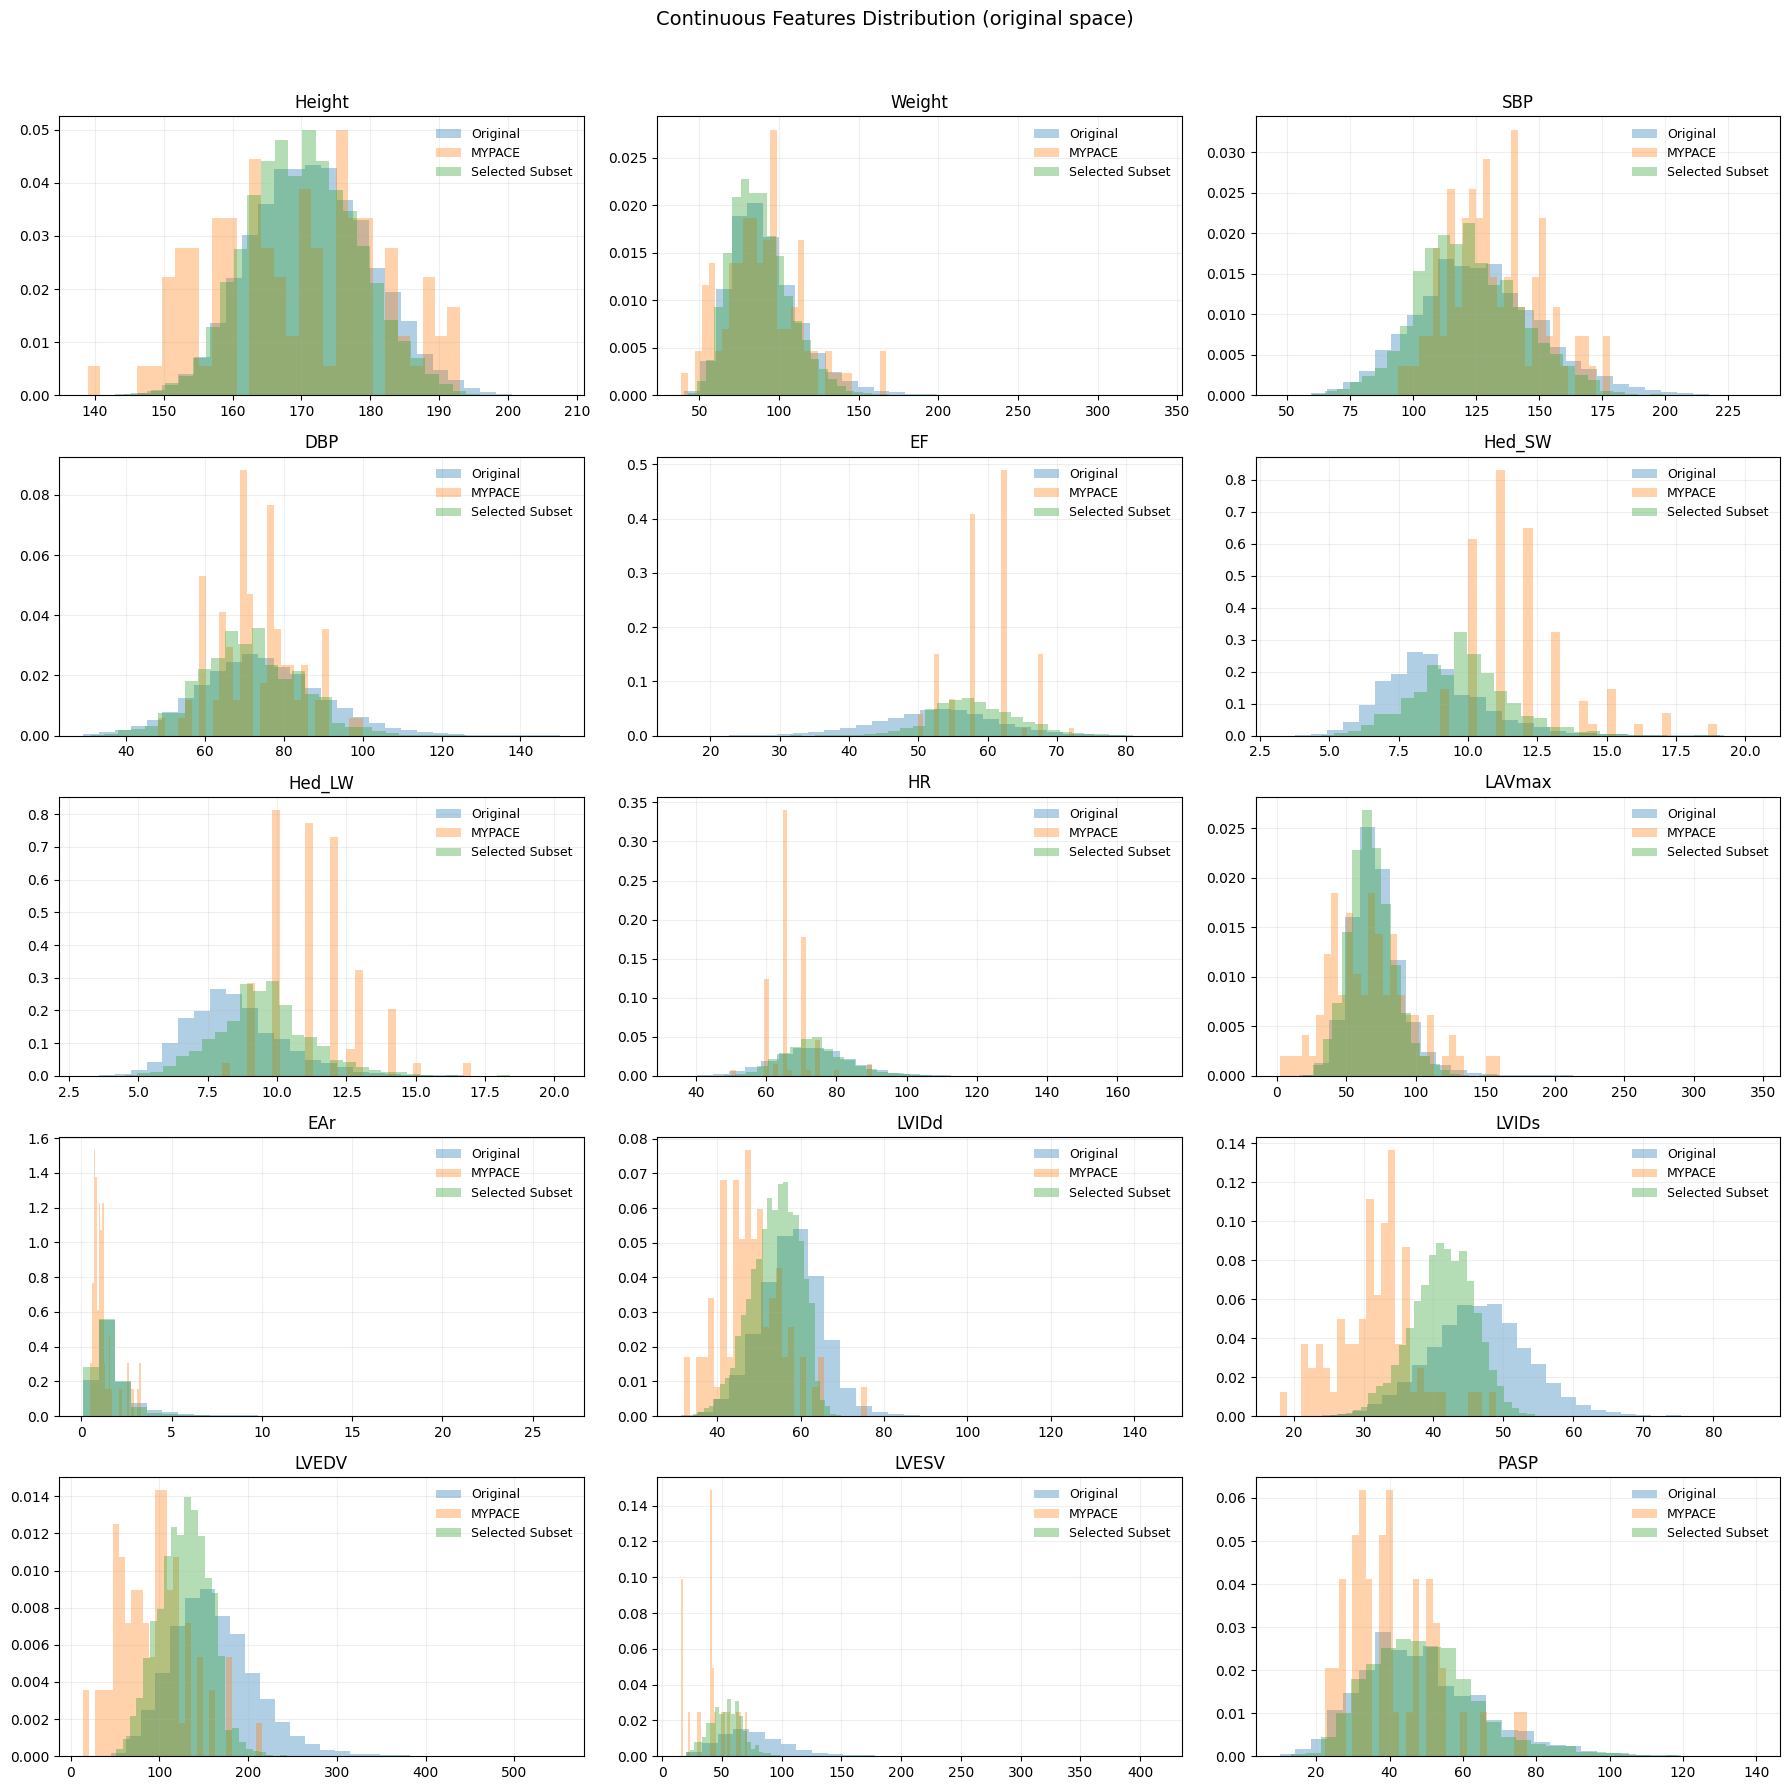

Saved: distribution_plots\categorical_distribution_original.png


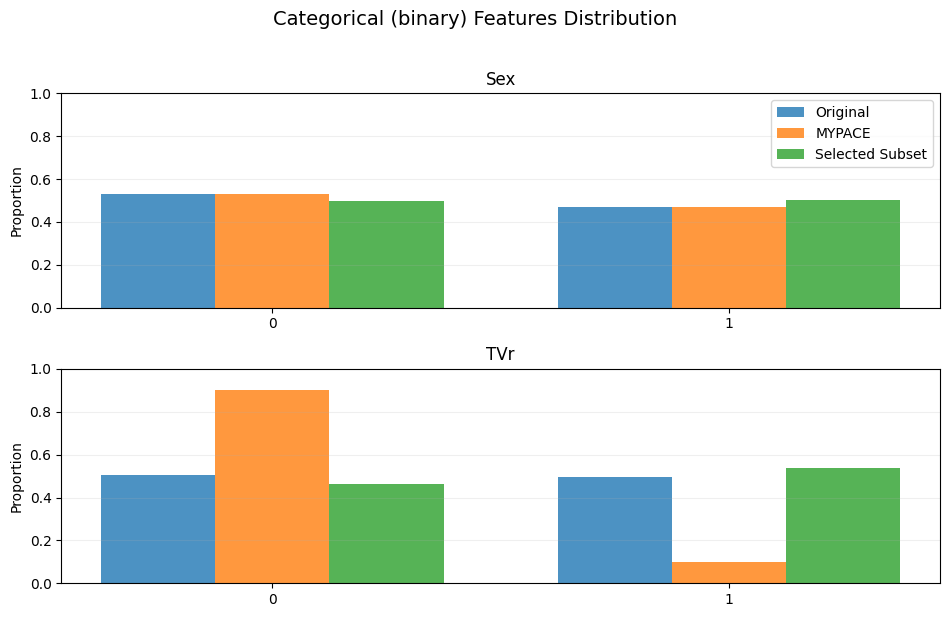

In [21]:
# 按每个特征的范围进行筛选（独立、粗范围，不学协方差）
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import math

# —— 可调参数 ——
space = "original"          # 选择在原始空间("original")还是归一化空间("normalized")做筛选
q_low, q_high = 5, 95        # MYPACE 分位数范围（如 5~95 更宽；10~90 更严格）
margin_frac = 0.1            # 在分位数范围外再放宽的比例（按区间宽度的百分比）
min_in_range_frac = 0.80     # 至少有多少比例的特征落在范围内才算“像”（0.8 即至少 80% 特征满足）

# —— 选择数据视图 ——
if space == "normalized":
    train_df = normalized_features.copy()
    mypace_df = mypace_normalized_df.copy()
else:
    train_df = features.copy()            # 原始单位，更直观（如心率 60-90）
    mypace_df = mypace_features.copy()

# 防御：仅使用双方都存在的列
common_cols = [c for c in train_df.columns if c in mypace_df.columns]
train_df = train_df[common_cols]
mypace_df = mypace_df[common_cols]

# 统一命名：将未定义的 continuous_cols/categorical_cols 映射到已存在的 cont_cols/cat_cols
# continuous_cols 期望是“连续特征列名的列表”；categorical_cols 为“分类（二元）特征列名的列表”。
if 'continuous_cols' not in globals() or continuous_cols is None:
    if 'cont_cols' in globals():
        continuous_cols = cont_cols
    else:
        # 兜底：假设首末列是二元，其余为连续
        continuous_cols = train_df.columns[1:-1].tolist()

if 'categorical_cols' not in globals() or categorical_cols is None:
    if 'cat_cols' in globals():
        categorical_cols = cat_cols
    else:
        # 兜底：假设首列与末列为二元
        categorical_cols = [train_df.columns[0], train_df.columns[-1]]

# 根据已存在的列，拆分连续 / 分类
active_cont_cols = [c for c in continuous_cols if c in common_cols]
active_cat_cols  = [c for c in categorical_cols if c in common_cols]

# —— 连续特征：用 MYPACE 的分位数画“盒子范围”，再加少量边际放宽 ——
cont_ranges = {}
for col in active_cont_cols:
    s = mypace_df[col].dropna()
    if s.empty:
        continue
    lo = np.percentile(s, q_low)
    hi = np.percentile(s, q_high)
    width = hi - lo
    lo_adj = lo - width * margin_frac
    hi_adj = hi + width * margin_frac
    cont_ranges[col] = (lo_adj, hi_adj)

# —— 构造布尔矩阵：每列一个条件，行表示样本是否满足 ——
conds = []
col_names = []

for col in active_cont_cols:
    if col not in cont_ranges:
        continue
    lo_adj, hi_adj = cont_ranges[col]
    cond = train_df[col].ge(lo_adj) & train_df[col].le(hi_adj)
    conds.append(cond.fillna(False))
    col_names.append(col)

for col in active_cat_cols:
    allowed = set(mypace_df[col].dropna().unique())
    if len(allowed) == 0:
        continue
    cond = train_df[col].isin(allowed)
    conds.append(cond.fillna(False))
    col_names.append(col)

if len(conds) == 0:
    raise RuntimeError("没有可用于筛选的特征列（请检查 continuous_cols/categorical_cols 或数据列名）。")

cond_df = pd.concat(conds, axis=1)
cond_df.columns = col_names

# —— 至少满足一定比例特征在范围内 ——
ratio_in_range = cond_df.sum(axis=1) / cond_df.shape[1]
mask = ratio_in_range >= min_in_range_frac

selected_indices = np.flatnonzero(mask.to_numpy()).tolist()
selected_subset_indices = selected_indices  # 覆盖之前的选择结果

# —— 结果汇报 ——
print("[独立范围筛选] 参数：")
print(f"  空间: {space}  分位数: [{q_low}%, {q_high}%]  放宽比例: {margin_frac*100:.1f}%  最小满足比例: {min_in_range_frac*100:.0f}%")
print(f"  使用特征数: {cond_df.shape[1]}  (连续: {len(cont_ranges)}, 分类: {cond_df.shape[1]-len(cont_ranges)})")
print(f"  训练样本总数: {len(train_df)}  选中: {len(selected_subset_indices)}  比例: {len(selected_subset_indices)/len(train_df)*100:.2f}%")

# 展示前若干个连续特征的范围示例
show_cols = list(cont_ranges.keys())[:8]
if show_cols:
    print("\n部分连续特征范围示例（原始单位/或归一化值）：")
    for c in show_cols:
        lo_adj, hi_adj = cont_ranges[c]
        print(f"  - {c}: [{lo_adj:.3f}, {hi_adj:.3f}]")

# —— 可视化：原始数据 vs MYPACE vs 选中子集 ——
print("\n" + "="*80)
print("DISTRIBUTION COMPARISON: Original vs MYPACE vs Selected Subset")
print("="*80)

# 输出目录
out_dir = "distribution_plots"
os.makedirs(out_dir, exist_ok=True)

subset_df = train_df.iloc[selected_subset_indices].copy() if len(selected_subset_indices) > 0 else train_df.iloc[[]].copy()
has_subset = len(subset_df) > 0
print(f"Subset size: {len(subset_df)}")

# 1) 连续特征分布（叠加直方图，密度归一；每个子图右上角放 legend）
if active_cont_cols:
    n = len(active_cont_cols)
    ncols = 3
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 3.5*nrows), squeeze=False)
    for idx, col in enumerate(active_cont_cols):
        r, c = divmod(idx, ncols)
        ax = axes[r][c]
        ax.hist(train_df[col].dropna(), bins=30, alpha=0.35, density=True, label='Original', color='#1f77b4')
        ax.hist(mypace_df[col].dropna(), bins=30, alpha=0.35, density=True, label='MYPACE', color='#ff7f0e')
        if has_subset:
            ax.hist(subset_df[col].dropna(), bins=30, alpha=0.35, density=True, label='Selected Subset', color='#2ca02c')
        ax.set_title(col)
        ax.grid(alpha=0.2)
        # 子图右上角 legend
        ax.legend(loc='upper right', frameon=False, fontsize=9)
    # 隐藏多余子图
    for k in range(n, nrows*ncols):
        r, c = divmod(k, ncols)
        axes[r][c].axis('off')
    fig.suptitle(f"Continuous Features Distribution ({'normalized' if space=='normalized' else 'original'} space)", y=1.02, fontsize=14)
    plt.tight_layout()
    # 保存图片
    cont_path = os.path.join(out_dir, f"continuous_distribution_{space}.png")
    plt.savefig(cont_path, dpi=300, bbox_inches='tight')
    print(f"Saved: {cont_path}")
    plt.show()
else:
    print("No continuous features available for plotting.")

# 2) 分类（二元）特征分布（分组柱状：比例）
if active_cat_cols:
    fig, axes = plt.subplots(len(active_cat_cols), 1, figsize=(9.6, 3*len(active_cat_cols)))
    if len(active_cat_cols) == 1:
        axes = [axes]
    for j, col in enumerate(active_cat_cols):
        ax = axes[j]
        # 计算比例
        train_props = train_df[col].value_counts(normalize=True).reindex([0, 1]).fillna(0).values
        mypace_props = mypace_df[col].value_counts(normalize=True).reindex([0, 1]).fillna(0).values
        subset_props = (subset_df[col].value_counts(normalize=True).reindex([0, 1]).fillna(0).values if has_subset else np.array([0, 0]))
        x = np.array([0, 1], dtype=float)
        width = 0.25
        ax.bar(x - width, train_props, width, label='Original', color='#1f77b4', alpha=0.8)
        ax.bar(x,         mypace_props, width, label='MYPACE',   color='#ff7f0e', alpha=0.8)
        if has_subset:
            ax.bar(x + width, subset_props, width, label='Selected Subset', color='#2ca02c', alpha=0.8)
        ax.set_xticks([0, 1]); ax.set_xticklabels(['0', '1'])
        ax.set_ylim(0, 1)
        ax.set_ylabel('Proportion')
        ax.set_title(col)
        ax.grid(axis='y', alpha=0.2)
        if j == 0:
            ax.legend(loc='upper right')
    fig.suptitle("Categorical (binary) Features Distribution", y=1.02, fontsize=14)
    plt.tight_layout()
    # 保存图片
    cat_path = os.path.join(out_dir, f"categorical_distribution_{space}.png")
    plt.savefig(cat_path, dpi=300, bbox_inches='tight')
    print(f"Saved: {cat_path}")
    plt.show()
else:
    print("No categorical features available for plotting.")

In [20]:
# Subset Training Pipeline Based on MYPACE-Similar Patients
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

print("="*80)
print("MYPACE-SIMILAR SUBSET TRAINING PIPELINE")
print("="*80)

print("🎯 Training new models on MYPACE-similar patient subset")
print(f"📊 Subset size: {len(selected_subset_indices)} patients ({len(selected_subset_indices)/len(features)*100:.1f}% of original)")

# Create subset training data
subset_features = features.iloc[selected_subset_indices].copy()
subset_labels = labels.iloc[selected_subset_indices].copy()

# Fit scaler on subset ONLY (continuous features: middle columns)
subset_continuous = subset_features.iloc[:, 1:-1].copy()
subset_scaler = MinMaxScaler()  # 基于子集重新拟合
subset_normalized_cont = subset_scaler.fit_transform(subset_continuous)

# 记录子集的 min/max 供外部数据剪裁使用
subset_cont_mins = pd.Series(subset_continuous.min(), name="min")
subset_cont_maxs = pd.Series(subset_continuous.max(), name="max")

# Reconstruct normalized subset with binary columns unchanged
subset_normalized = pd.DataFrame(subset_normalized_cont, columns=subset_continuous.columns, index=subset_features.index)
subset_normalized.insert(0, subset_features.columns[0], subset_features.iloc[:, 0])  # First binary
subset_normalized[subset_features.columns[-1]] = subset_features.iloc[:, -1]        # Last binary

print(f"\nSubset data shapes:")
print(f"Features: {subset_features.shape}")
print(f"Labels: {subset_labels.shape}")
print(f"Normalized (subset-fitted scaler): {subset_normalized.shape}")

# Convert to tensors
subset_input_tensor = torch.tensor(subset_normalized.values, dtype=torch.float32)

# Split subset into training and validation
X_subset_train, X_subset_val, y_subset_train, y_subset_val = train_test_split(
    subset_input_tensor.numpy(), subset_labels.values, test_size=0.2, random_state=42
)

# Convert to PyTorch tensors
X_subset_train_tensor = torch.tensor(X_subset_train, dtype=torch.float32)
X_subset_val_tensor = torch.tensor(X_subset_val, dtype=torch.float32)
y_subset_train_tensor = torch.tensor(y_subset_train, dtype=torch.float32)
y_subset_val_tensor = torch.tensor(y_subset_val, dtype=torch.float32)

print(f"\nSubset training split:")
print(f"Training samples: {len(X_subset_train)}")
print(f"Validation samples: {len(X_subset_val)}")

# Create DataLoader for subset training
subset_train_dataset = torch_data.TensorDataset(X_subset_train_tensor, y_subset_train_tensor)
subset_train_loader = torch_data.DataLoader(subset_train_dataset, batch_size=batch_size, shuffle=True)

# Directory to save subset models
subset_save_dir = "saved_models_mypace_subset"
os.makedirs(subset_save_dir, exist_ok=True)

print(f"\n🔧 Training parameters:")
print(f"Batch size: {batch_size}")
print(f"Learning rate: {learning_rate}")
print(f"Max epochs: {num_epochs}")
print(f"Device: {device}")


MYPACE-SIMILAR SUBSET TRAINING PIPELINE
🎯 Training new models on MYPACE-similar patient subset
📊 Subset size: 6826 patients (27.8% of original)

Subset data shapes:
Features: (6826, 17)
Labels: (6826, 10)
Normalized (subset-fitted scaler): (6826, 17)

Subset training split:
Training samples: 5460
Validation samples: 1366

🔧 Training parameters:
Batch size: 48
Learning rate: 0.0005
Max epochs: 5000
Device: cpu


In [ ]:

# Train models on subset data
print(f"\n" + "="*80)
print("TRAINING CLASSIFIERS ON MYPACE-SIMILAR SUBSET")
print("="*80)

subset_training_results = {}

for i in range(subset_labels.shape[1]):
    label_name = subset_labels.columns[i]
    start_time = time.time()
    print(f"\n{'='*60}")
    print(f"Training SUBSET classifier for {label_name}... (Label {i+1}/{subset_labels.shape[1]})")
    print(f"{'='*60}")
    
    # Check label distribution in subset
    subset_label_dist = subset_labels[label_name].value_counts()
    pos_count = subset_label_dist.get(1, 0)
    neg_count = subset_label_dist.get(0, 0)
    total_count = pos_count + neg_count
    
    print(f"Subset label distribution for {label_name}:")
    print(f"  Positive (1): {pos_count} ({pos_count/total_count*100:.1f}%)")
    print(f"  Negative (0): {neg_count} ({neg_count/total_count*100:.1f}%)")
    
    # Skip if too few positive samples
    if pos_count < 5:
        print(f"⚠️  Skipping {label_name} - too few positive samples ({pos_count})")
        continue
    
    # Initialize model for subset training
    subset_model = MLPClassifier(input_size=17).to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(subset_model.parameters(), lr=learning_rate)
    
    best_val_auc = 0.0
    best_loss = float('inf')
    early_stop = False
    epoch_count = 0
    
    # Training loop
    for epoch in range(num_epochs):
        if early_stop:
            break
            
        epoch_count += 1
        subset_model.train()
        epoch_loss = 0.0
        
        for batch_X, batch_y in subset_train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            batch_y = batch_y[:, i].unsqueeze(1)
            
            outputs = subset_model(batch_X)
            loss = criterion(outputs, batch_y)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        # Validation
        subset_model.eval()
        with torch.no_grad():
            X_subset_val_device = X_subset_val_tensor.to(device)
            val_outputs = subset_model(X_subset_val_device)
            val_labels_device = y_subset_val_tensor[:, i].unsqueeze(1).to(device)
            
            # Only calculate AUC if we have both classes in validation set
            val_labels_np = val_labels_device.cpu().numpy()
            val_outputs_np = val_outputs.cpu().numpy()
            
            if len(np.unique(val_labels_np)) > 1:
                val_auc = roc_auc_score(val_labels_np, val_outputs_np)
            else:
                val_auc = 0.5  # Default AUC when only one class present
        
        # Save best model
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_loss = epoch_loss
            subset_model_path = os.path.join(subset_save_dir, f"model_{label_name}_subset_best.pth")
            torch.save(subset_model.state_dict(), subset_model_path)
        
        # Progress display
        if epoch_count % 10 == 0 or val_auc > (best_val_auc - 0.001):
            print(f"[{label_name}] Epoch {epoch+1:4d} | Best AUC: {best_val_auc:.4f} | Best Loss: {best_loss:.4f}")
        
        # Early stopping
        if best_val_auc >= 0.975:
            print(f"[{label_name}] ✓ Early stopping! Best AUC: {best_val_auc:.4f}")
            early_stop = True
    
    elapsed_time = time.time() - start_time
    print(f"[{label_name}] ✓ SUBSET TRAINING COMPLETED | Best AUC: {best_val_auc:.4f} | Time: {elapsed_time:.1f}s | Epochs: {epoch_count}")
    
    # Store results
    subset_training_results[label_name] = {
        'best_auc': best_val_auc,
        'best_loss': best_loss,
        'epochs': epoch_count,
        'time': elapsed_time,
        'pos_samples': pos_count,
        'neg_samples': neg_count
    }

print(f"\n" + "="*80)
print("SUBSET TRAINING SUMMARY")
print("="*80)

print(f"{'Label':<15} {'AUC':<8} {'Pos/Neg':<10} {'Epochs':<8} {'Time(s)':<8}")
print("-" * 60)
for label_name, results in subset_training_results.items():
    pos_neg = f"{results['pos_samples']}/{results['neg_samples']}"
    print(f"{label_name:<15} {results['best_auc']:<8.4f} {pos_neg:<10} {results['epochs']:<8} {results['time']:<8.1f}")

print(f"\n✅ Subset training completed!")
print(f"📁 Models saved in: {subset_save_dir}/")
print(f"📊 {len(subset_training_results)} classifiers trained on MYPACE-similar subset")
print(f"🔄 Ready for subset model evaluation and MYPACE prediction comparison!")

SUBSET MODEL EVALUATION - PARALLEL PIPELINE (Per-label Optimal Thresholds)
🎯 Complete parallel evaluation of MYPACE-subset trained models with fixed thresholds (from subset val)

SUBSET MODEL EVALUATION ON VALIDATION SET

Evaluating SUBSET model: LabelFillingP...


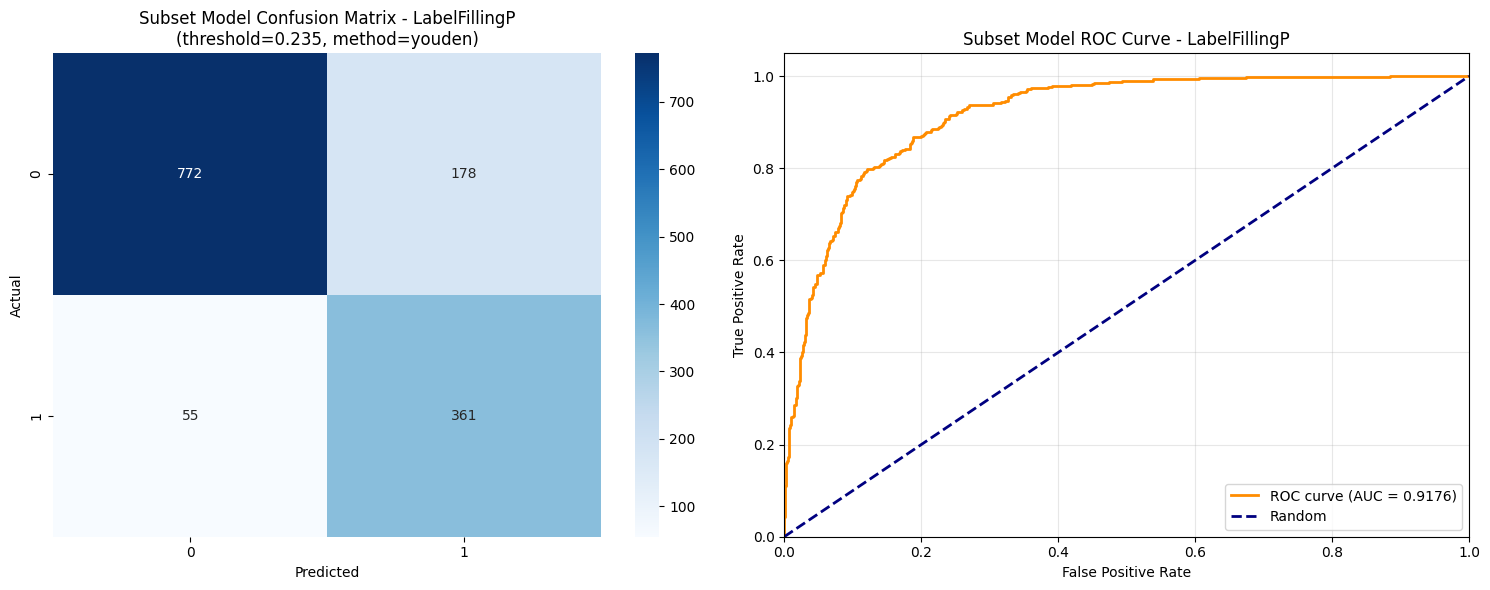

Subset AUC: 0.9176
Threshold(youden): 0.2348
Accuracy: 0.8294
Precision: 0.6698
Recall: 0.8678
F1-Score: 0.7560

Evaluating SUBSET model: LabelEF...


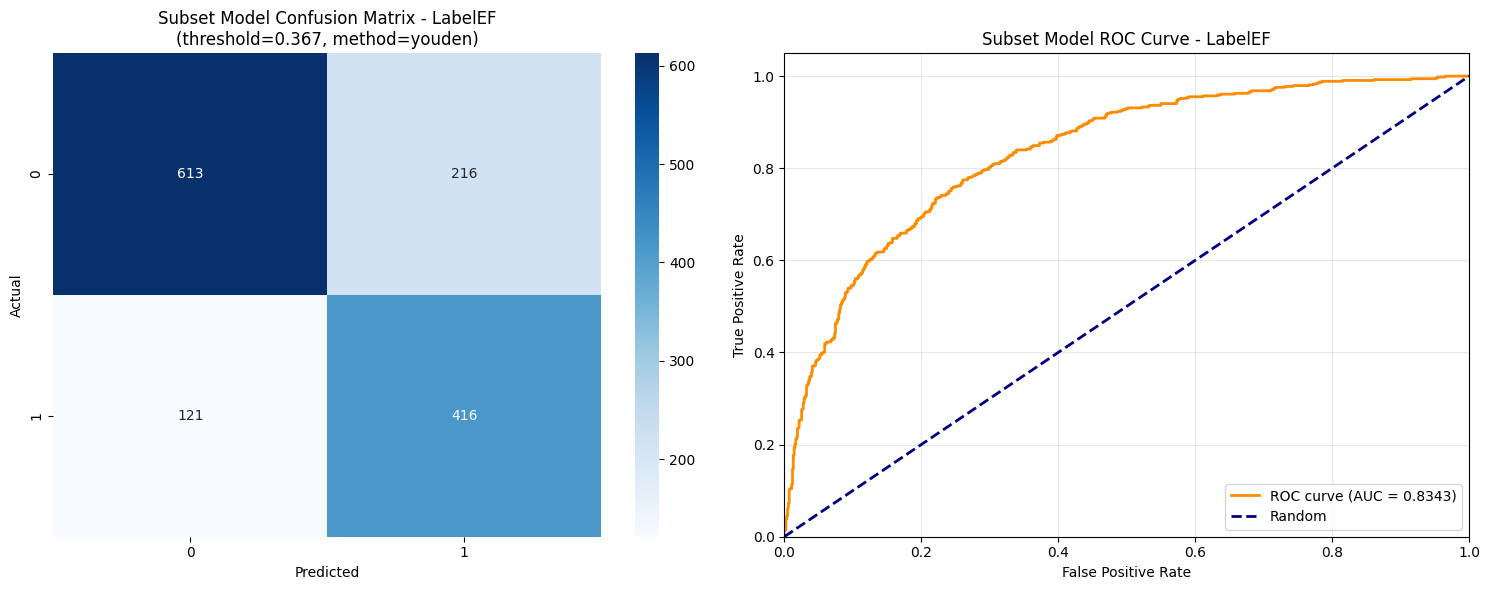

Subset AUC: 0.8343
Threshold(youden): 0.3670
Accuracy: 0.7533
Precision: 0.6582
Recall: 0.7747
F1-Score: 0.7117

Evaluating SUBSET model: LabelCO...


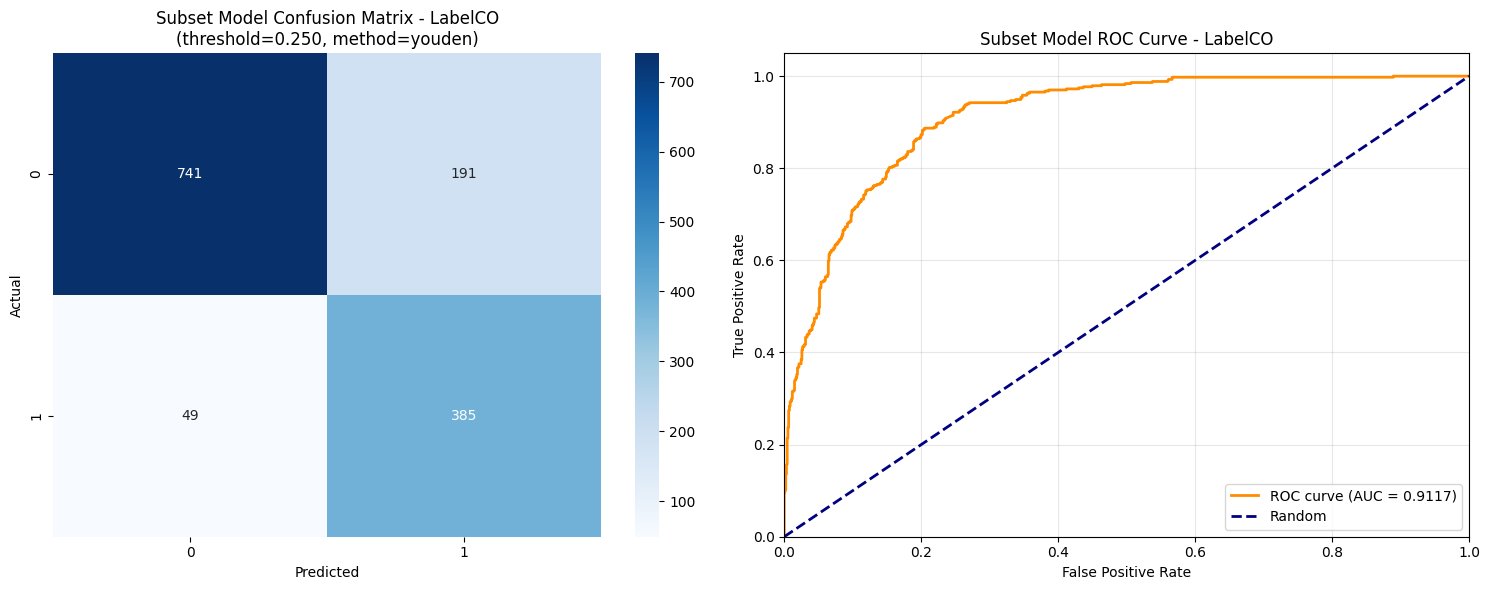

Subset AUC: 0.9117
Threshold(youden): 0.2496
Accuracy: 0.8243
Precision: 0.6684
Recall: 0.8871
F1-Score: 0.7624

Evaluating SUBSET model: LabelLAV...


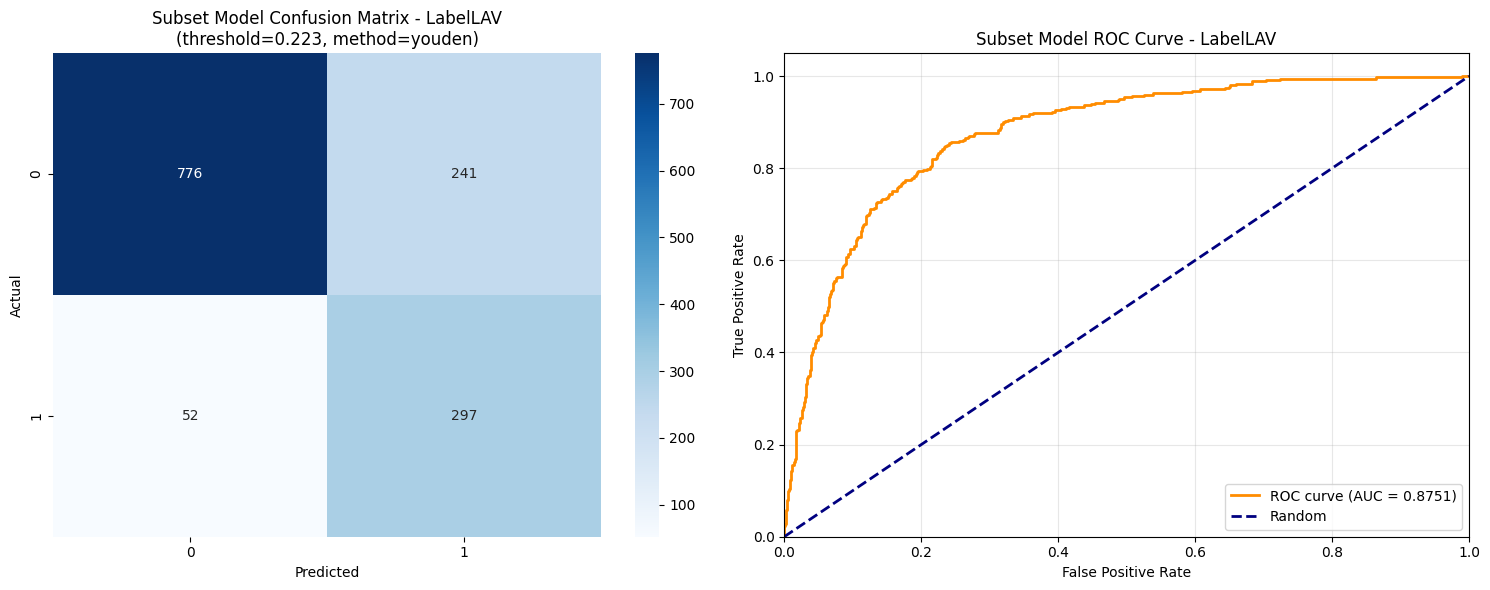

Subset AUC: 0.8751
Threshold(youden): 0.2230
Accuracy: 0.7855
Precision: 0.5520
Recall: 0.8510
F1-Score: 0.6697

Evaluating SUBSET model: LabelRVO2E...


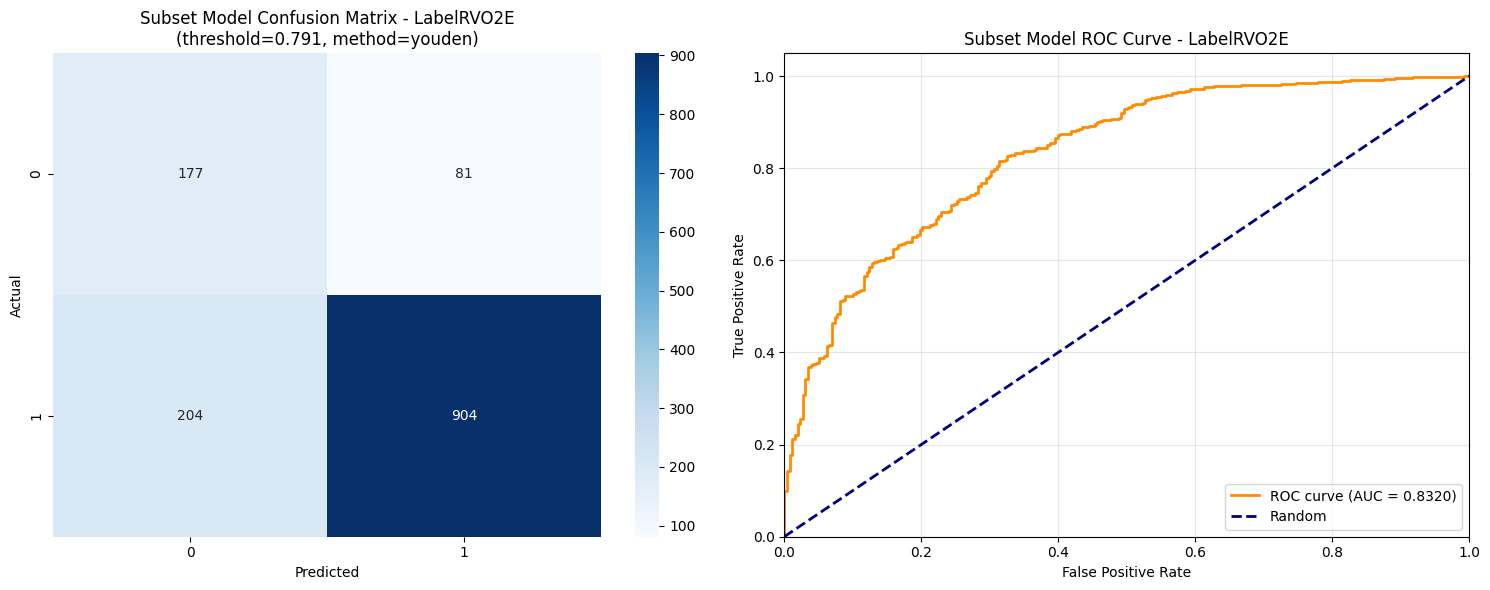

Subset AUC: 0.8320
Threshold(youden): 0.7907
Accuracy: 0.7914
Precision: 0.9178
Recall: 0.8159
F1-Score: 0.8638

Evaluating SUBSET model: LabelLVO2E...


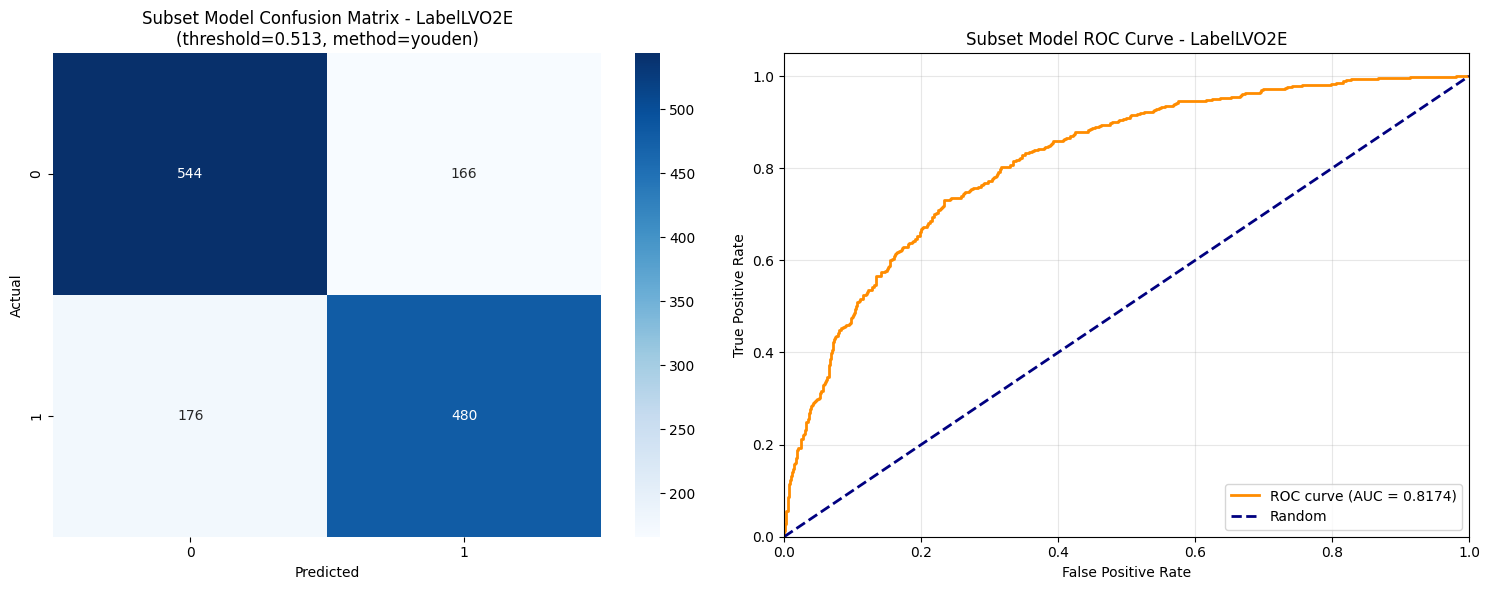

Subset AUC: 0.8174
Threshold(youden): 0.5126
Accuracy: 0.7496
Precision: 0.7430
Recall: 0.7317
F1-Score: 0.7373

Evaluating SUBSET model: LabelLVMVO2...


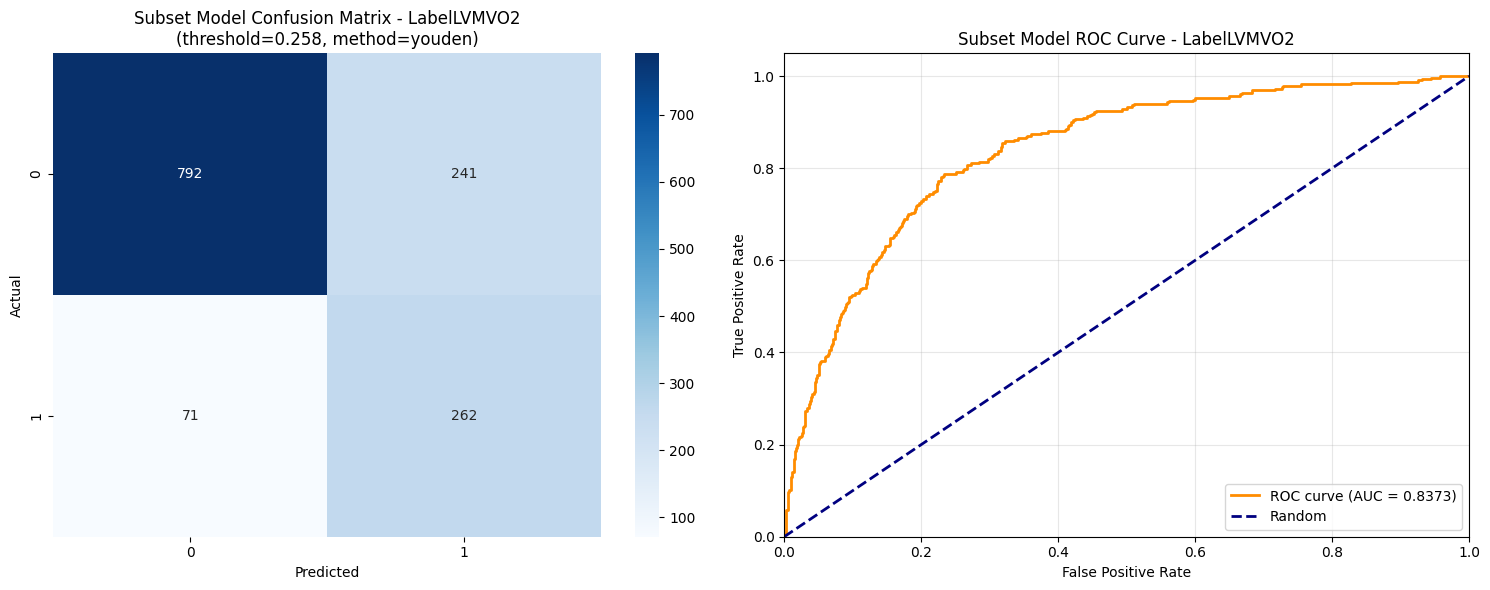

Subset AUC: 0.8373
Threshold(youden): 0.2582
Accuracy: 0.7716
Precision: 0.5209
Recall: 0.7868
F1-Score: 0.6268

Evaluating SUBSET model: LabelRVMVO2...


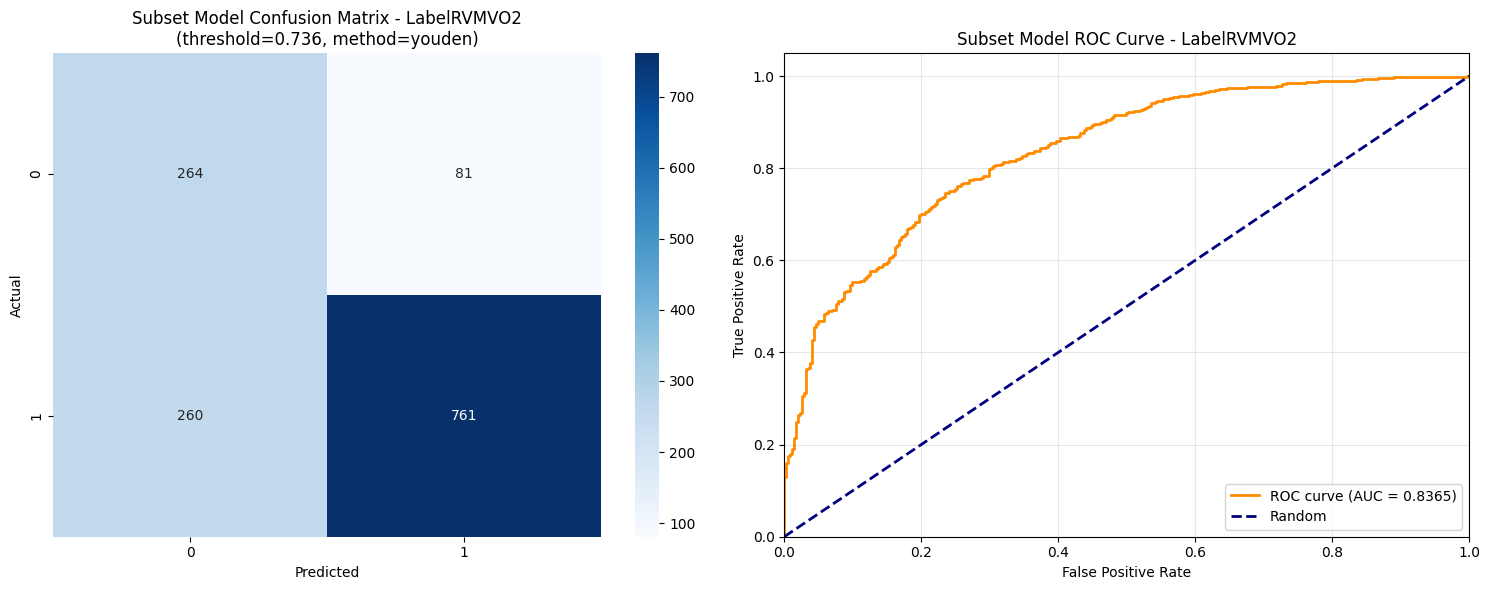

Subset AUC: 0.8365
Threshold(youden): 0.7364
Accuracy: 0.7504
Precision: 0.9038
Recall: 0.7453
F1-Score: 0.8170

Evaluating SUBSET model: LabelLVME...


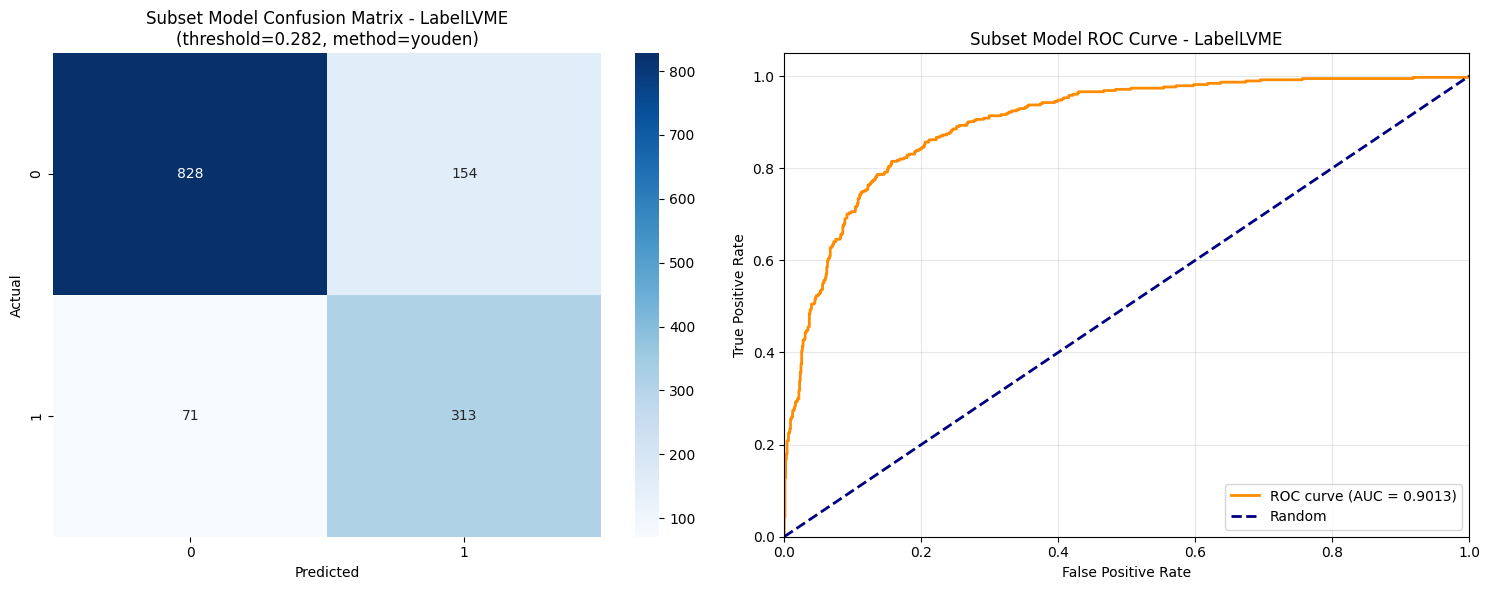

Subset AUC: 0.9013
Threshold(youden): 0.2817
Accuracy: 0.8353
Precision: 0.6702
Recall: 0.8151
F1-Score: 0.7356

Evaluating SUBSET model: LabelRVME...


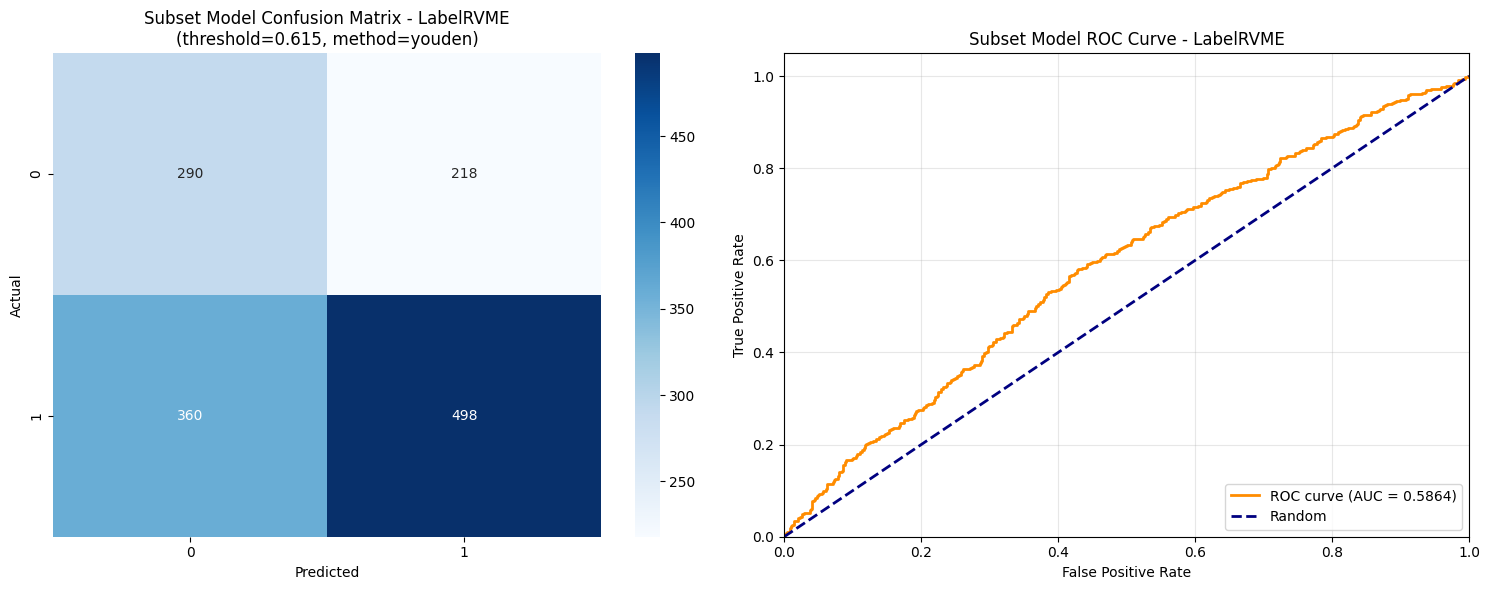

Subset AUC: 0.5864
Threshold(youden): 0.6152
Accuracy: 0.5769
Precision: 0.6955
Recall: 0.5804
F1-Score: 0.6328

SUBSET MODEL EVALUATION COMPLETED!
All subset evaluation plots saved in: subset_evaluation_plots/

Per-label optimal thresholds (subset validation set):
  LabelFillingP  : 0.2348 (youden)
  LabelEF        : 0.3670 (youden)
  LabelCO        : 0.2496 (youden)
  LabelLAV       : 0.2230 (youden)
  LabelRVO2E     : 0.7907 (youden)
  LabelLVO2E     : 0.5126 (youden)
  LabelLVMVO2    : 0.2582 (youden)
  LabelRVMVO2    : 0.7364 (youden)
  LabelLVME      : 0.2817 (youden)
  LabelRVME      : 0.6152 (youden)


In [22]:
# Complete Parallel Pipeline: Subset Model Evaluation (per-label optimal thresholds on subset val)
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("="*80)
print("SUBSET MODEL EVALUATION - PARALLEL PIPELINE (Per-label Optimal Thresholds)")
print("="*80)

print("🎯 Complete parallel evaluation of MYPACE-subset trained models with fixed thresholds (from subset val)")

# Create directory for subset evaluation plots
subset_plot_dir = "subset_evaluation_plots"
os.makedirs(subset_plot_dir, exist_ok=True)

# Threshold selection method for subset models
subset_threshold_method = 'youden'  # or 'f1'

print("\n" + "="*80)
print("SUBSET MODEL EVALUATION ON VALIDATION SET")
print("="*80)

# Dictionaries to store subset evaluation results and thresholds
subset_evaluation_results = {}
optimal_thresholds_subset = {}

# Load and evaluate each subset-trained model on its validation set
for i in range(subset_labels.shape[1]):
    label_name = subset_labels.columns[i]
    print(f"\nEvaluating SUBSET model: {label_name}...")

    # Load the subset model
    subset_model_path = os.path.join(subset_save_dir, f"model_{label_name}_subset_best.pth")
    if os.path.exists(subset_model_path):
        # Initialize and load subset model
        eval_subset_model = MLPClassifier(input_size=17).to(device)
        eval_subset_model.load_state_dict(torch.load(subset_model_path, map_location=device))
        eval_subset_model.eval()

        # Get probabilities on subset validation set
        with torch.no_grad():
            X_subset_val_device = X_subset_val_tensor.to(device)
            subset_val_outputs = eval_subset_model(X_subset_val_device)
            subset_val_probs = subset_val_outputs.cpu().numpy().flatten()
            subset_val_true = y_subset_val_tensor[:, i].numpy().astype(int)

        # Only proceed if we have both classes in validation set
        if len(np.unique(subset_val_true)) > 1:
            # ROC and AUC
            subset_fpr, subset_tpr, subset_thresholds = roc_curve(subset_val_true, subset_val_probs)
            subset_roc_auc = auc(subset_fpr, subset_tpr)

            # Choose optimal threshold per label (subset)
            if subset_threshold_method == 'youden':
                J = subset_tpr - subset_fpr
                best_idx = int(np.argmax(J))
                best_thr = float(subset_thresholds[best_idx])
            elif subset_threshold_method == 'f1':
                f1_vals = []
                thr_candidates = subset_thresholds[1:] if len(subset_thresholds) > 1 else subset_thresholds
                for thr in thr_candidates:
                    preds_tmp = (subset_val_probs >= thr).astype(int)
                    f1_vals.append(f1_score(subset_val_true, preds_tmp))
                best_idx = int(np.argmax(f1_vals)) if len(f1_vals) else 0
                best_thr = float(thr_candidates[best_idx]) if len(thr_candidates) else 0.5
            else:
                best_thr = 0.5
            optimal_thresholds_subset[label_name] = best_thr

            # Apply threshold
            subset_val_preds = (subset_val_probs >= best_thr).astype(int)

            # Confusion Matrix and Classification Report
            subset_cm = confusion_matrix(subset_val_true, subset_val_preds)
            subset_report = classification_report(subset_val_true, subset_val_preds, output_dict=True)

            # Store results
            subset_evaluation_results[label_name] = {
                'confusion_matrix': subset_cm,
                'classification_report': subset_report,
                'auc': subset_roc_auc,
                'fpr': subset_fpr,
                'tpr': subset_tpr,
                'roc_auc': subset_roc_auc,
                'predictions': subset_val_preds,
                'probabilities': subset_val_probs,
                'true_labels': subset_val_true,
                'threshold': best_thr,
                'threshold_method': subset_threshold_method,
            }

            # Create subplot figure for this label
            fig, axes = plt.subplots(1, 2, figsize=(15, 6))

            # Confusion Matrix (with threshold)
            sns.heatmap(subset_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
            axes[0].set_title(f'Subset Model Confusion Matrix - {label_name}\n(threshold={best_thr:.3f}, method={subset_threshold_method})')
            axes[0].set_xlabel('Predicted')
            axes[0].set_ylabel('Actual')

            # ROC Curve
            axes[1].plot(subset_fpr, subset_tpr, color='darkorange', lw=2,
                         label=f'ROC curve (AUC = {subset_roc_auc:.4f})')
            axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
            axes[1].set_xlim([0.0, 1.0])
            axes[1].set_ylim([0.0, 1.05])
            axes[1].set_xlabel('False Positive Rate')
            axes[1].set_ylabel('True Positive Rate')
            axes[1].set_title(f'Subset Model ROC Curve - {label_name}')
            axes[1].legend(loc="lower right")
            axes[1].grid(True, alpha=0.3)

            plt.tight_layout()
            plt.savefig(os.path.join(subset_plot_dir, f'{label_name}_subset_evaluation.png'),
                        dpi=300, bbox_inches='tight')
            plt.show()

            # Print metrics
            print(f"Subset AUC: {subset_roc_auc:.4f}")
            print(f"Threshold({subset_threshold_method}): {best_thr:.4f}")
            print(f"Accuracy: {subset_report['accuracy']:.4f}")
            if '1' in subset_report:
                print(f"Precision: {subset_report['1']['precision']:.4f}")
                print(f"Recall: {subset_report['1']['recall']:.4f}")
                print(f"F1-Score: {subset_report['1']['f1-score']:.4f}")
        else:
            print(f"❌ Skipping {label_name} - only one class in validation set")
    else:
        print(f"❌ Subset model file not found: {subset_model_path}")

print("\n" + "="*80)
print("SUBSET MODEL EVALUATION COMPLETED!")
print(f"All subset evaluation plots saved in: {subset_plot_dir}/")
print("="*80)

# Print thresholds per label
print("\nPer-label optimal thresholds (subset validation set):")
for lbl in subset_labels.columns:
    if lbl in optimal_thresholds_subset:
        print(f"  {lbl:15s}: {optimal_thresholds_subset[lbl]:.4f} ({subset_threshold_method})")
    else:
        print(f"  {lbl:15s}: N/A")

SUBSET MODEL EXTERNAL VALIDATION - 146 LABELED PATIENTS (fixed thresholds)
🎯 Evaluating subset-trained models on 146 external validation patients
📊 Thresholds fixed from subset validation set; no tuning on external
✓ Successfully loaded external validation data: inputFGclassifier146.CSV

External validation data shape:
Features shape: (146, 17)
Labels shape: (146, 10)
External validation tensor size: torch.Size([146, 17])

EVALUATING SUBSET MODELS ON EXTERNAL VALIDATION SET (fixed thresholds)

Subset External Validation: LabelFillingP


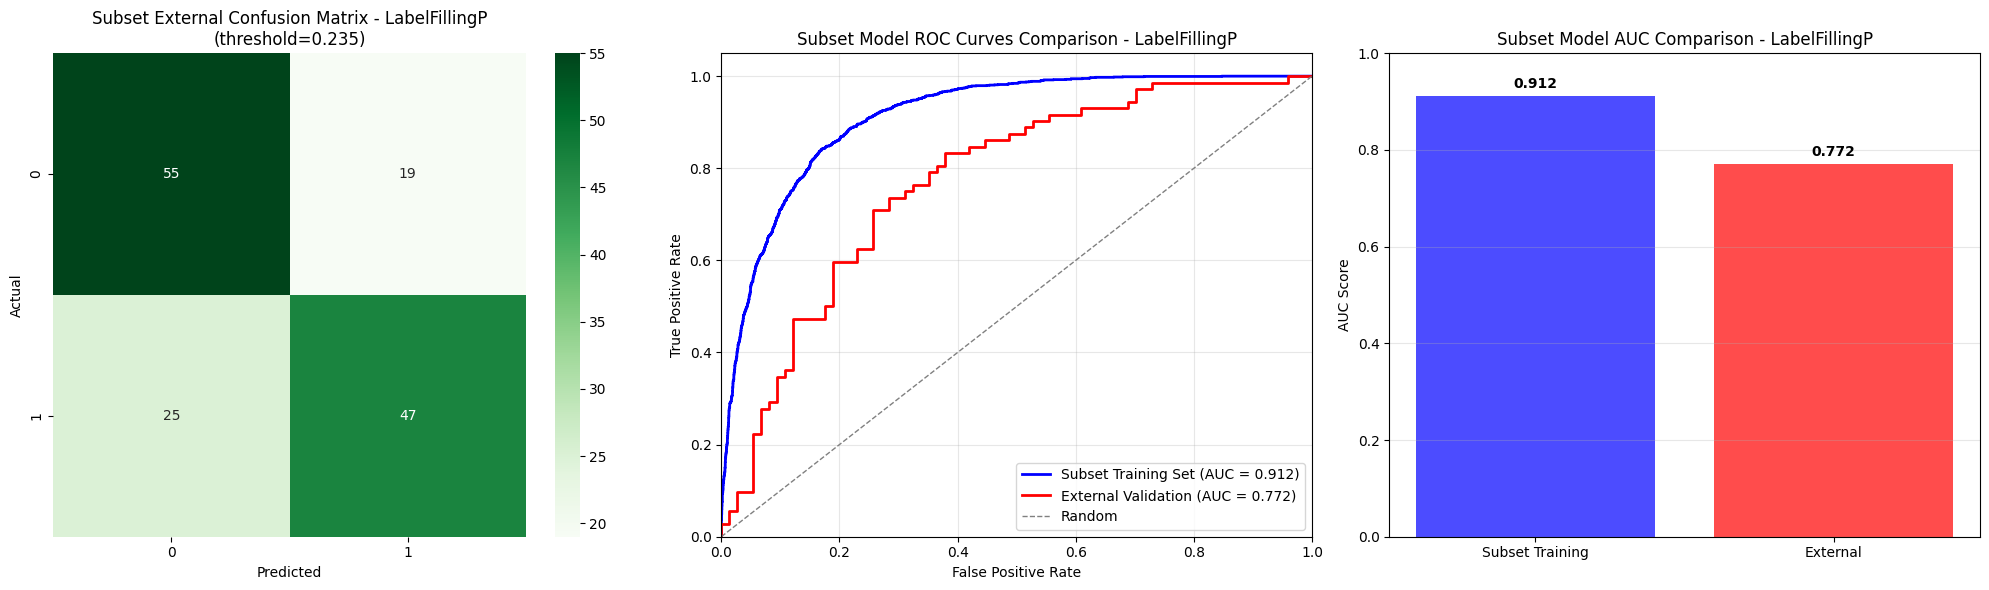

Subset Model External Validation Results (thr=0.2348):
  AUC: 0.7716
  Accuracy: 0.6986
  Precision: 0.7121
  Recall: 0.6528
  F1-Score: 0.6812

Subset External Validation: LabelEF


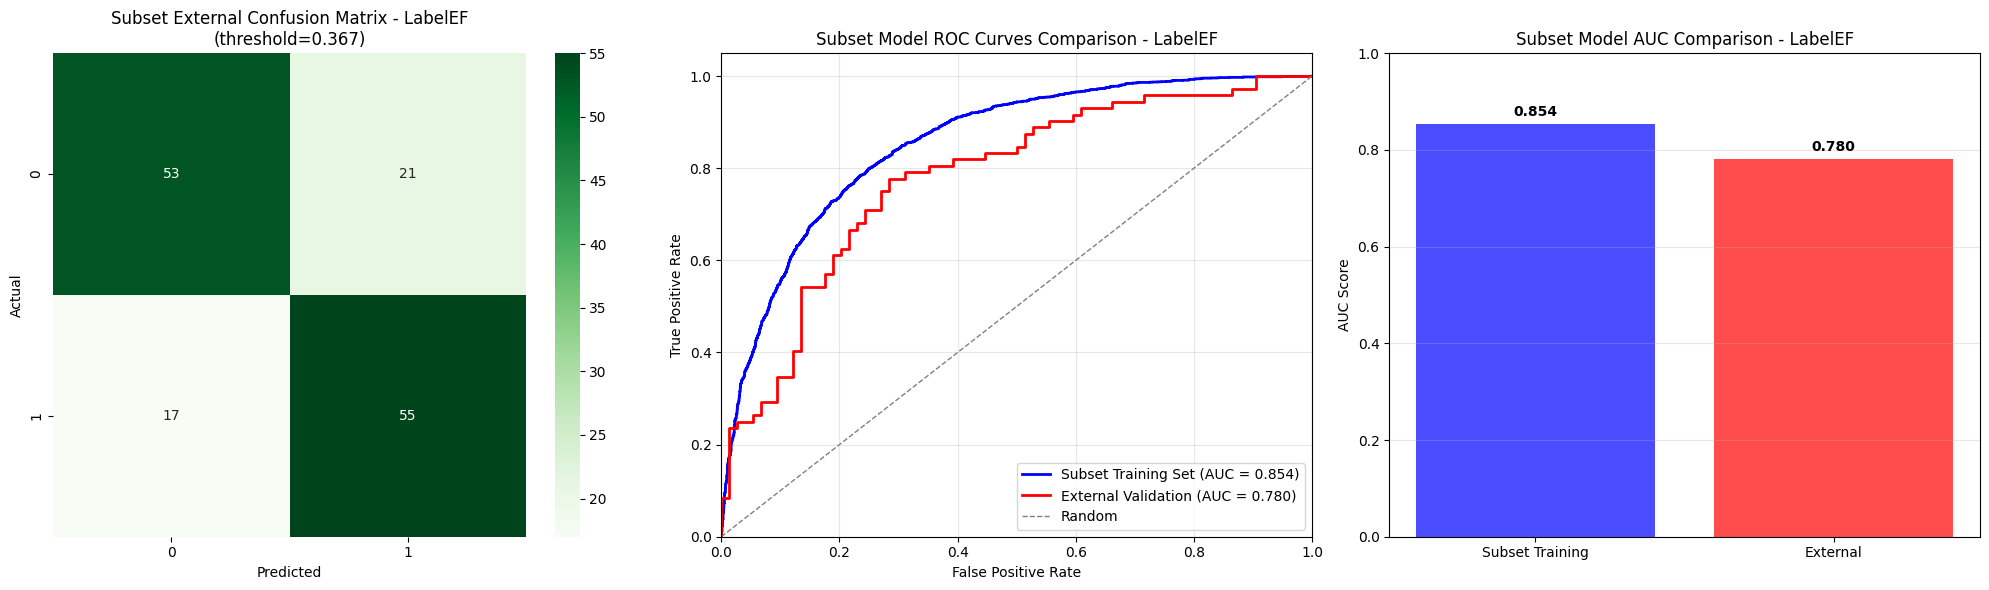

Subset Model External Validation Results (thr=0.3670):
  AUC: 0.7804
  Accuracy: 0.7397
  Precision: 0.7237
  Recall: 0.7639
  F1-Score: 0.7432

Subset External Validation: LabelCO


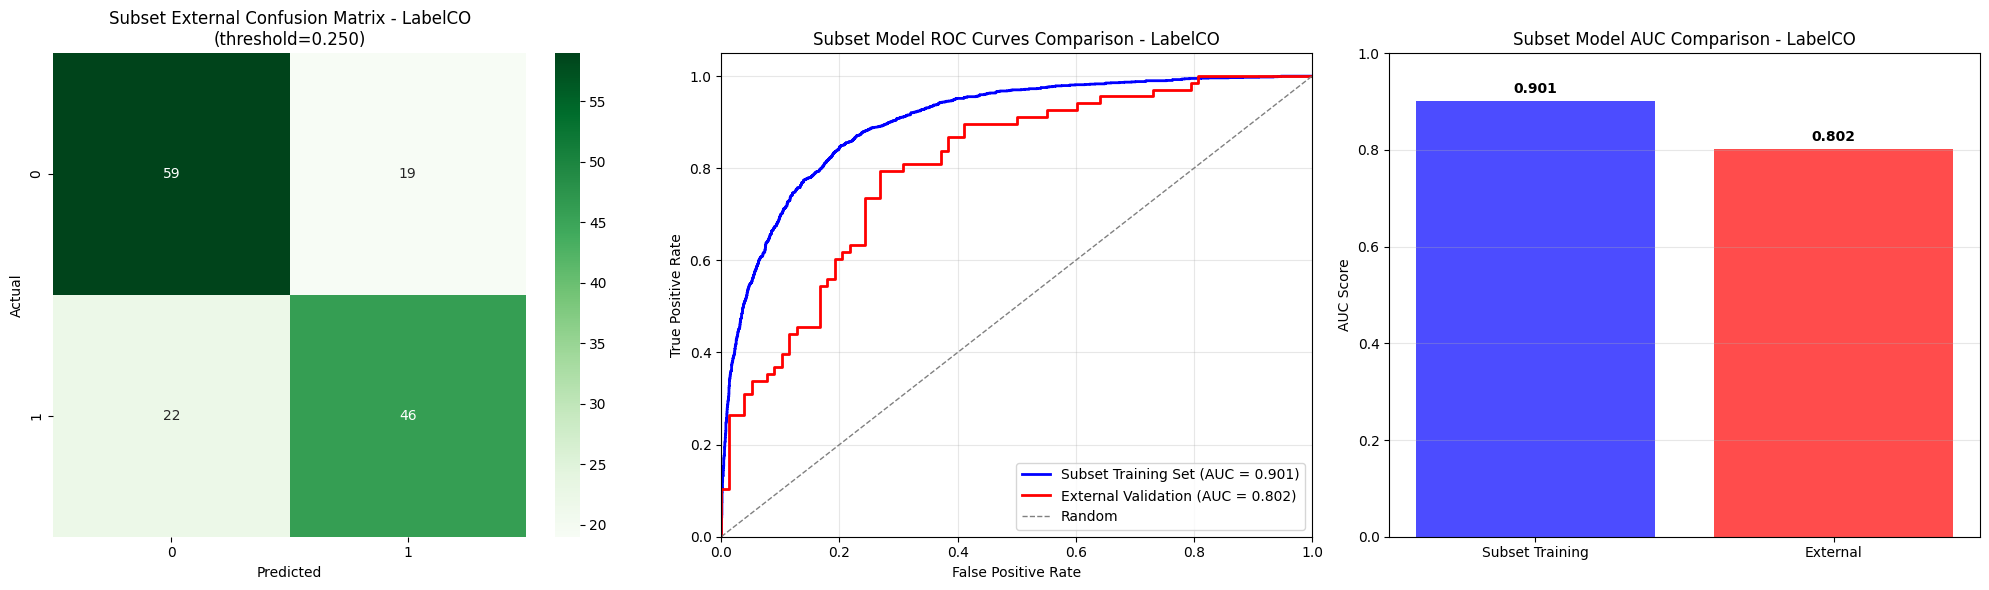

Subset Model External Validation Results (thr=0.2496):
  AUC: 0.8024
  Accuracy: 0.7192
  Precision: 0.7077
  Recall: 0.6765
  F1-Score: 0.6917

Subset External Validation: LabelLAV


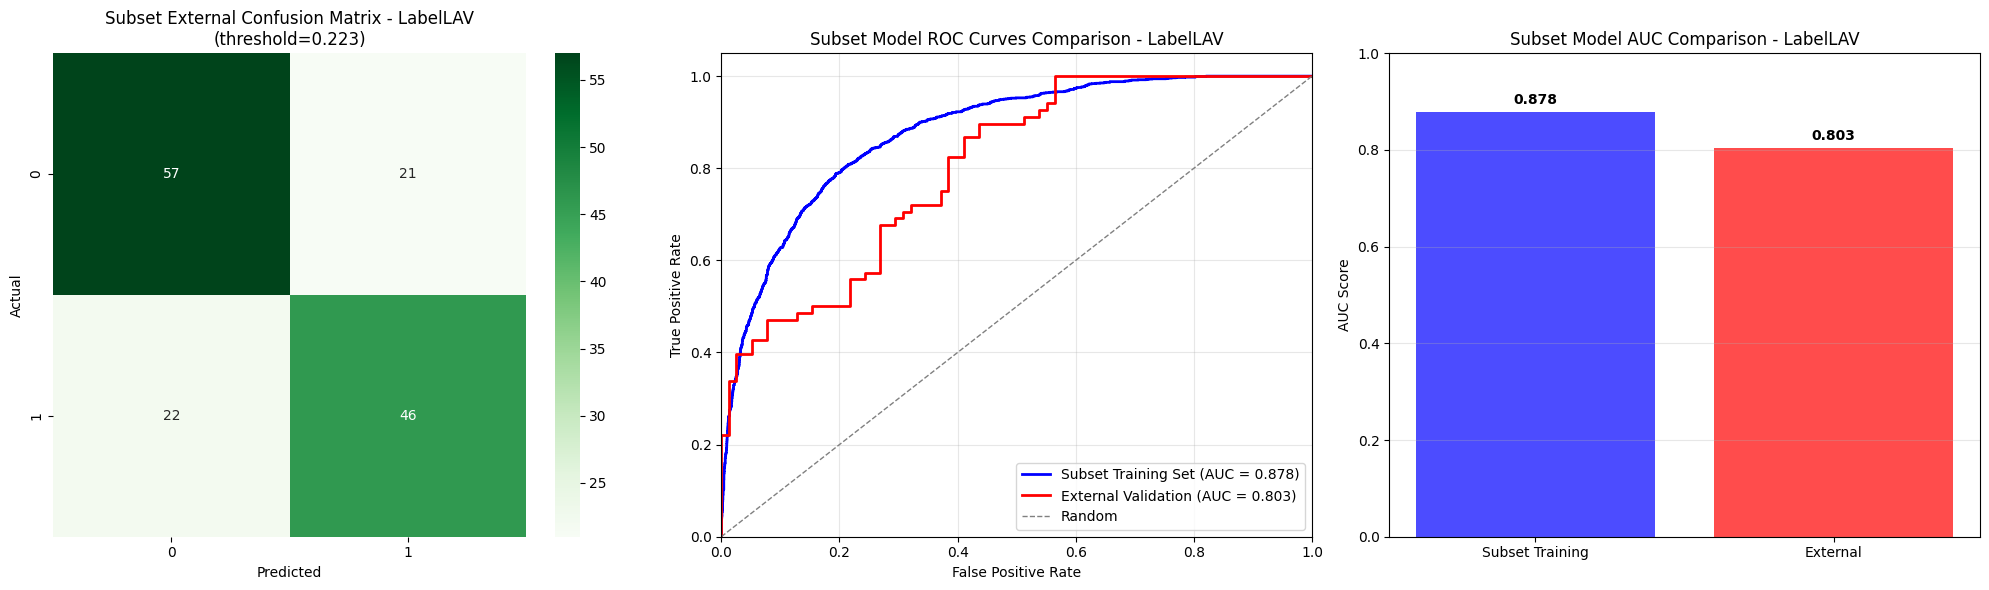

Subset Model External Validation Results (thr=0.2230):
  AUC: 0.8034
  Accuracy: 0.7055
  Precision: 0.6866
  Recall: 0.6765
  F1-Score: 0.6815

Subset External Validation: LabelRVO2E


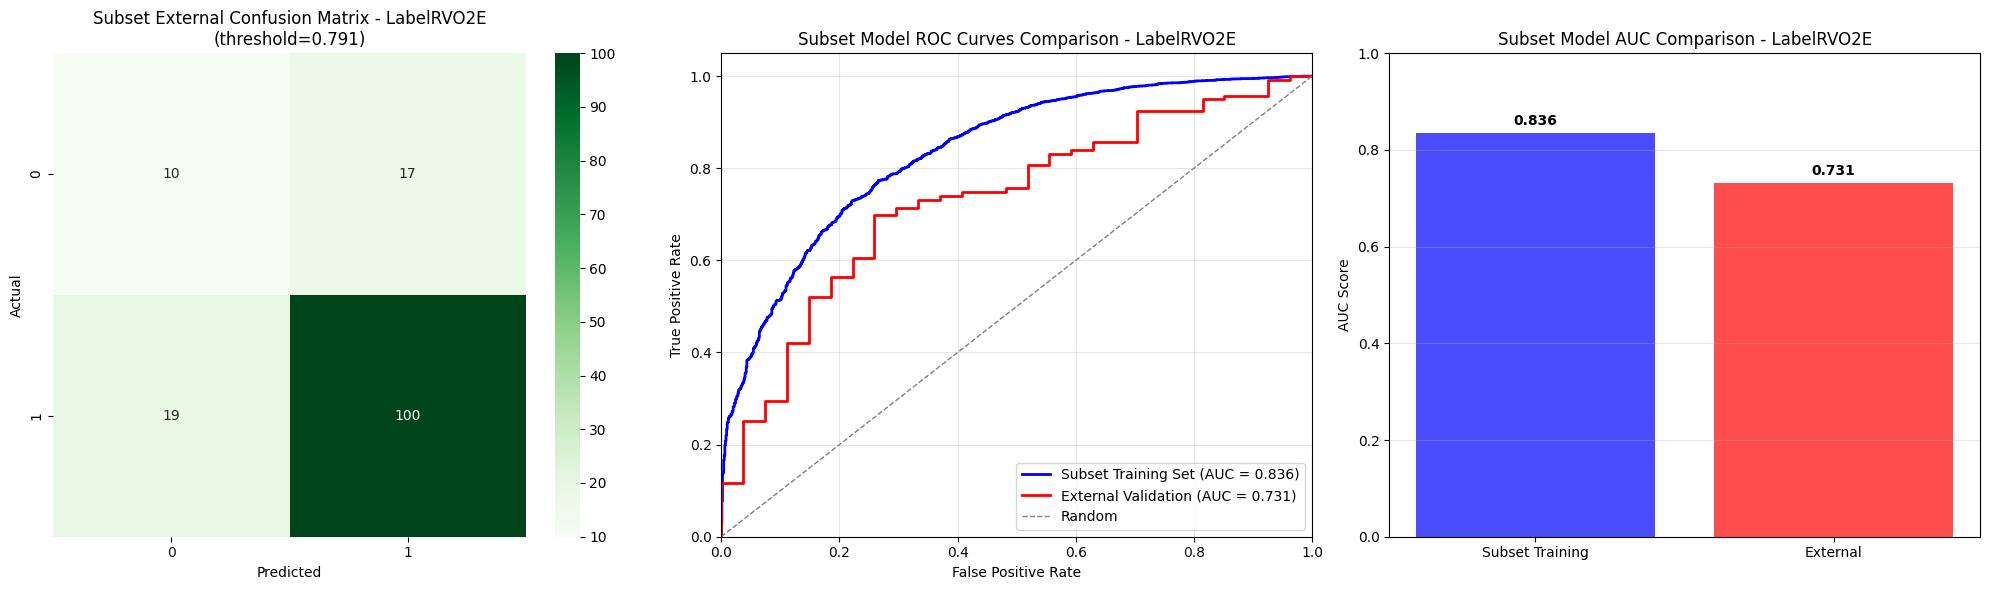

Subset Model External Validation Results (thr=0.7907):
  AUC: 0.7308
  Accuracy: 0.7534
  Precision: 0.8547
  Recall: 0.8403
  F1-Score: 0.8475

Subset External Validation: LabelLVO2E


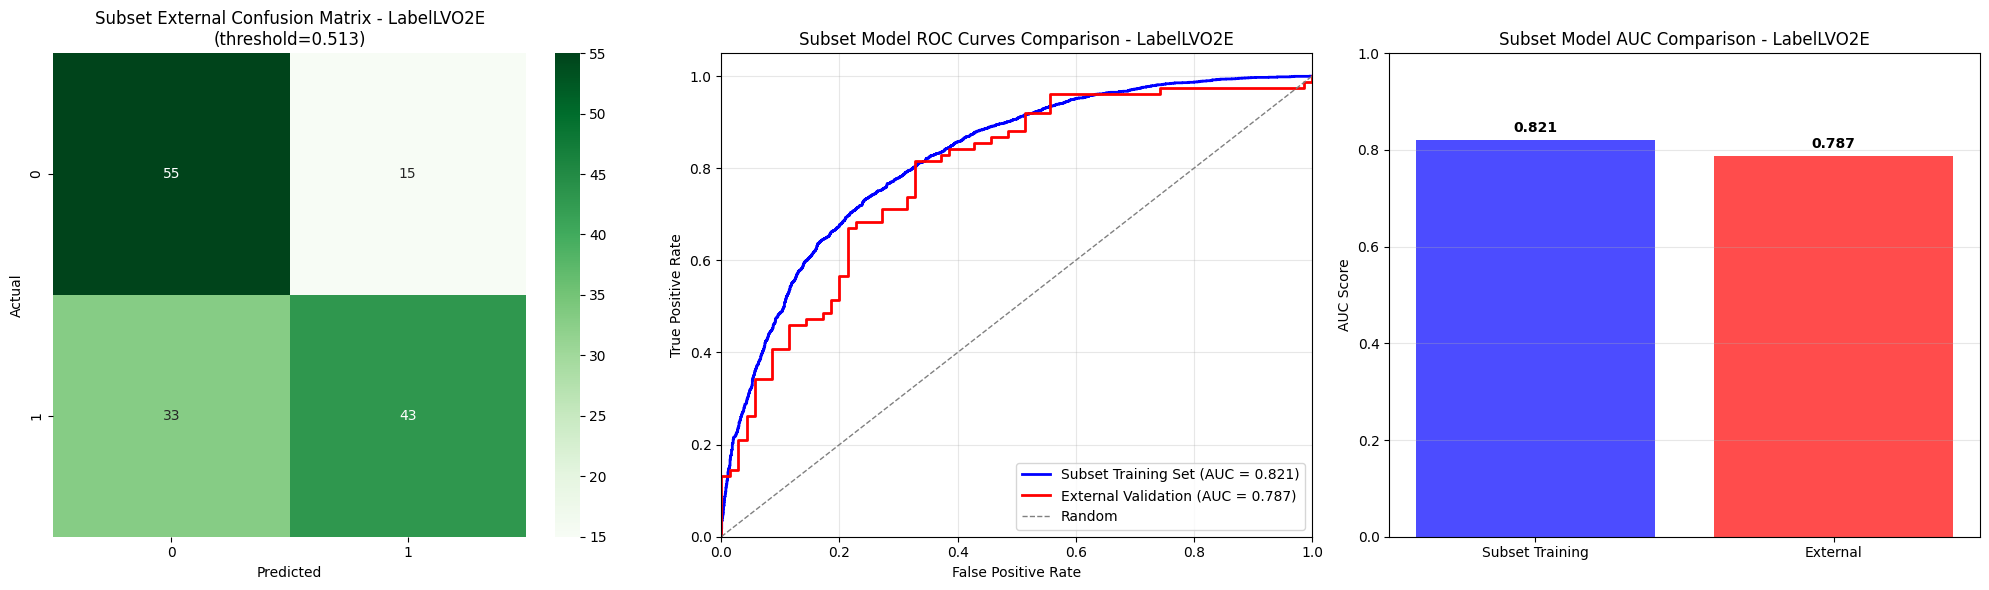

Subset Model External Validation Results (thr=0.5126):
  AUC: 0.7868
  Accuracy: 0.6712
  Precision: 0.7414
  Recall: 0.5658
  F1-Score: 0.6418

Subset External Validation: LabelLVMVO2


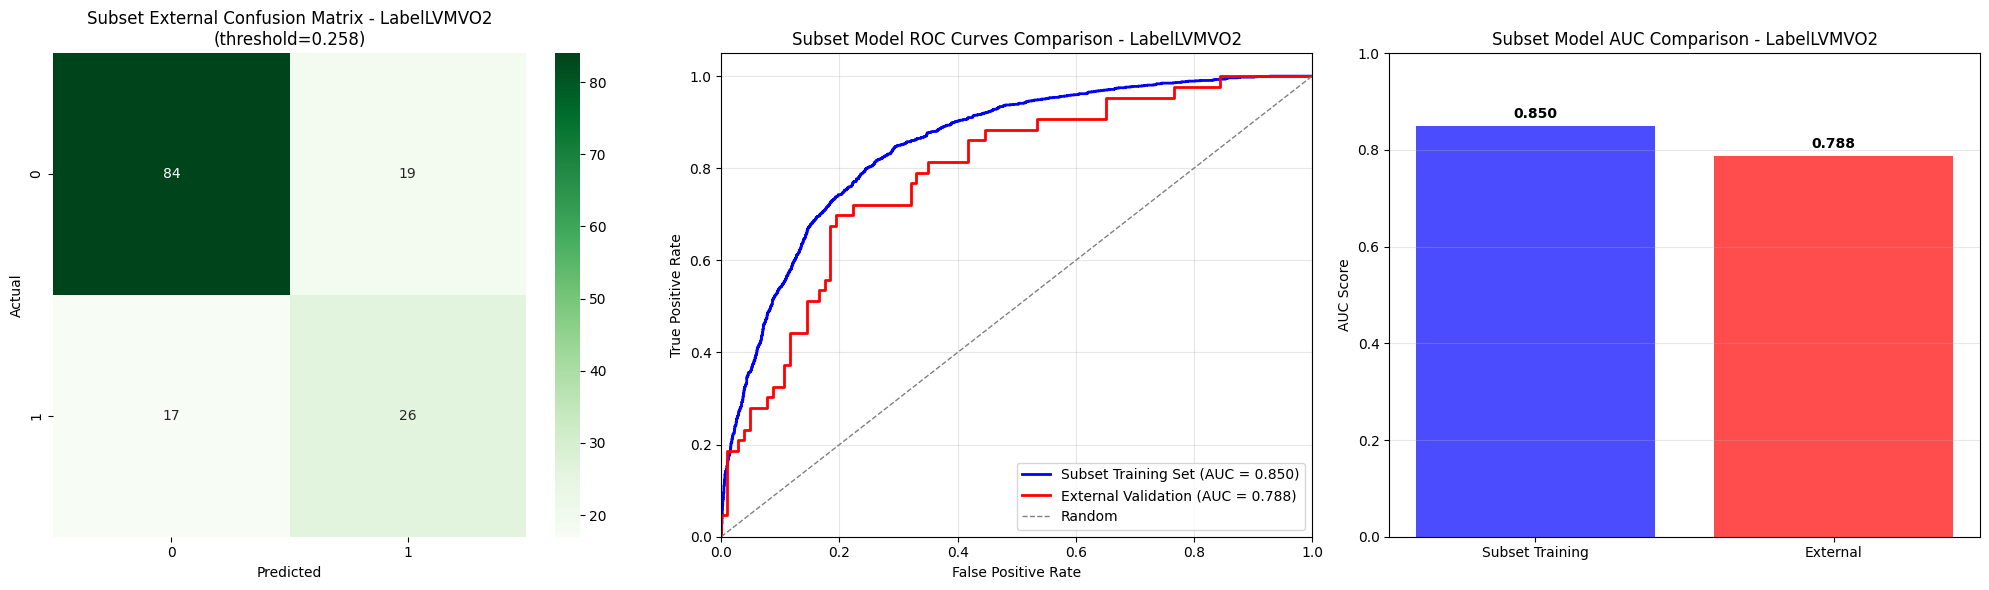

Subset Model External Validation Results (thr=0.2582):
  AUC: 0.7880
  Accuracy: 0.7534
  Precision: 0.5778
  Recall: 0.6047
  F1-Score: 0.5909

Subset External Validation: LabelRVMVO2


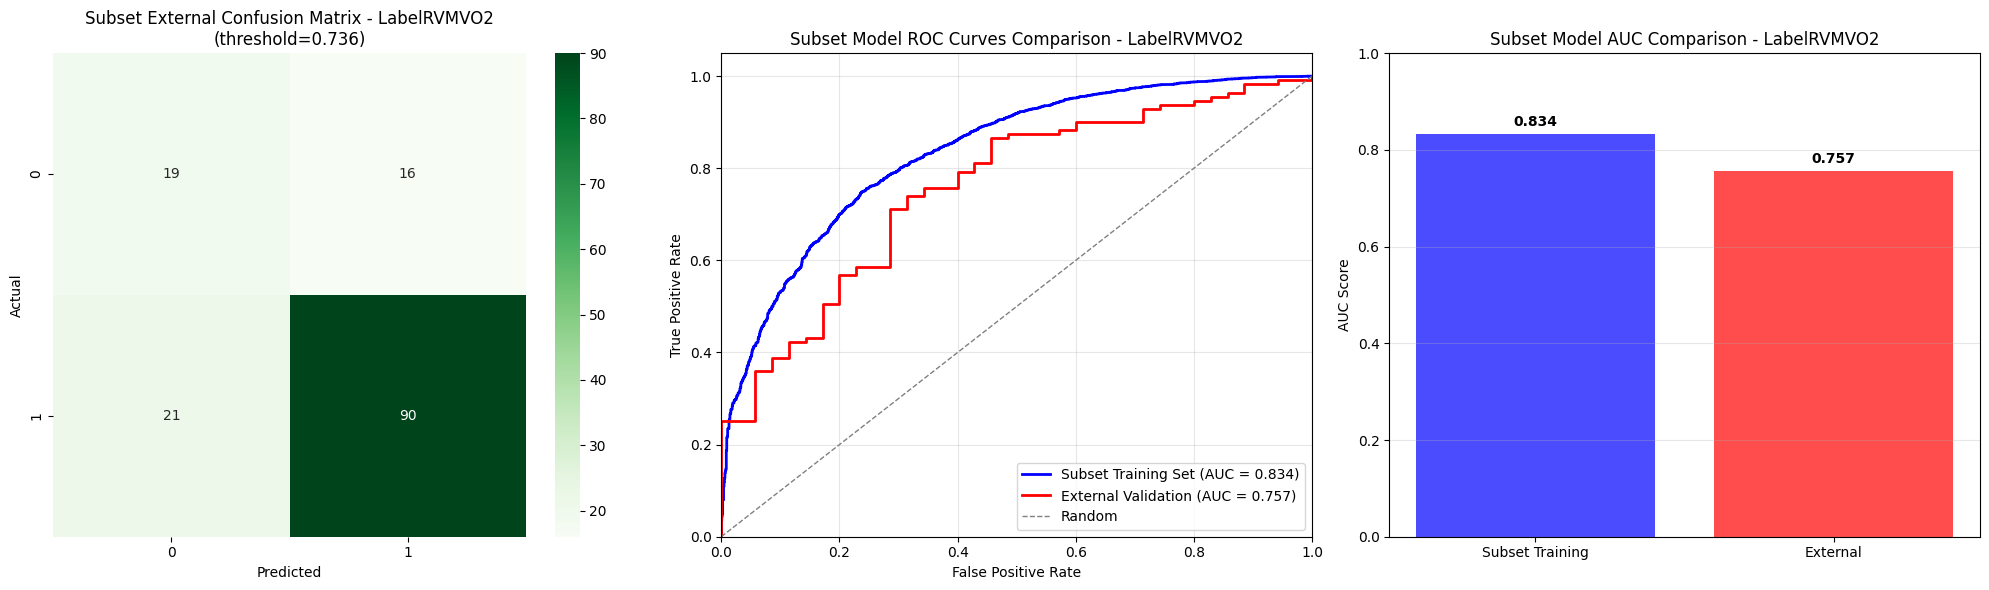

Subset Model External Validation Results (thr=0.7364):
  AUC: 0.7573
  Accuracy: 0.7466
  Precision: 0.8491
  Recall: 0.8108
  F1-Score: 0.8295

Subset External Validation: LabelLVME


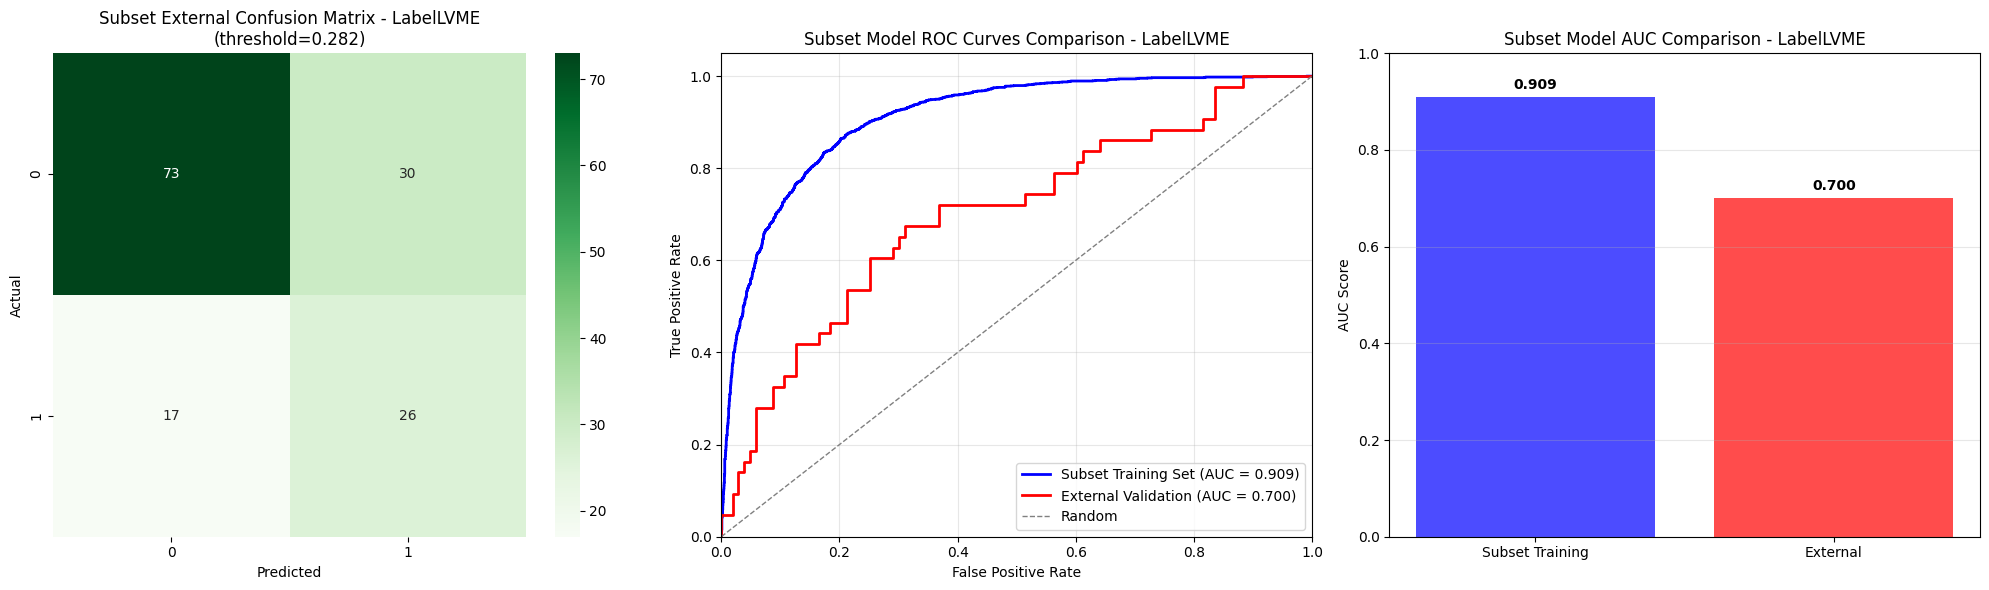

Subset Model External Validation Results (thr=0.2817):
  AUC: 0.7002
  Accuracy: 0.6781
  Precision: 0.4643
  Recall: 0.6047
  F1-Score: 0.5253

Subset External Validation: LabelRVME


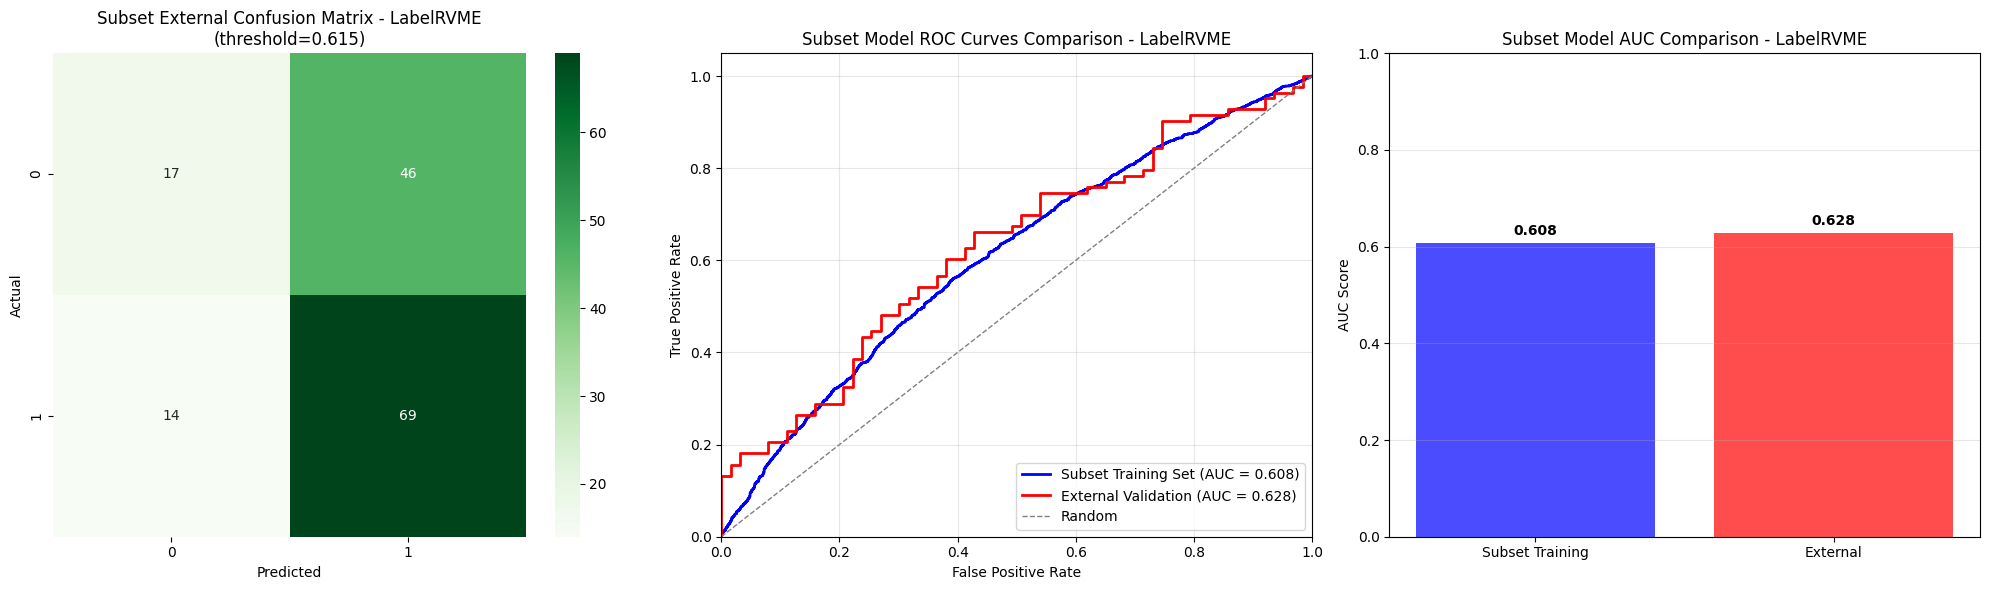

Subset Model External Validation Results (thr=0.6152):
  AUC: 0.6284
  Accuracy: 0.5890
  Precision: 0.6000
  Recall: 0.8313
  F1-Score: 0.6970

SUBSET EXTERNAL VALIDATION COMPLETED!
All subset external validation plots saved in: subset_external_validation_plots/

SUMMARY: Subset Training vs External Validation Performance (fixed thresholds)
Label           Train AUC  External AUC  Diff       Thr
----------------------------------------------------------------------
LabelFillingP   0.9121     0.7716        0.1405     0.235
LabelEF         0.8536     0.7804        0.0732     0.367
LabelCO         0.9006     0.8024        0.0982     0.250
LabelLAV        0.8778     0.8034        0.0745     0.223
LabelRVO2E      0.8356     0.7308        0.1048     0.791
LabelLVO2E      0.8214     0.7868        0.0345     0.513
LabelLVMVO2     0.8498     0.7880        0.0618     0.258
LabelRVMVO2     0.8337     0.7573        0.0764     0.736
LabelLVME       0.9088     0.7002        0.2086     0.282
LabelRV

In [23]:
import seaborn as sns
import numpy as np

# Ensure subset thresholds dict exists
if 'optimal_thresholds_subset' not in globals():
    optimal_thresholds_subset = {}

print("="*80)
print("SUBSET MODEL EXTERNAL VALIDATION - 146 LABELED PATIENTS (fixed thresholds)")
print("="*80)

print("🎯 Evaluating subset-trained models on 146 external validation patients")
print("📊 Thresholds fixed from subset validation set; no tuning on external")

# Load external validation dataset (same as before)
df_external_subset = pd.read_csv('inputFGclassifier146.CSV')
print(f"✓ Successfully loaded external validation data: inputFGclassifier146.CSV")

# Preprocess external validation data (same preprocessing as training)
external_processed_subset = df_external_subset.drop(df_external_subset.columns[[0, 12]], axis=1)
external_features_subset = external_processed_subset.iloc[:, 0:17]
external_labels_subset = external_processed_subset.iloc[:, -10:]

print(f"\nExternal validation data shape:")
print(f"Features shape: {external_features_subset.shape}")
print(f"Labels shape: {external_labels_subset.shape}")

# Normalize using SUBSET-FITTED scaler with clipping to subset min/max
external_continuous_subset = external_features_subset.iloc[:, 1:-1].copy()
for col in external_continuous_subset.columns:
    if col in subset_cont_mins.index:
        external_continuous_subset[col] = external_continuous_subset[col].clip(lower=subset_cont_mins[col], upper=subset_cont_maxs[col])
external_normalized_subset = subset_scaler.transform(external_continuous_subset)

# Combine binary and normalized continuous features
external_normalized_df_subset = pd.DataFrame(external_normalized_subset, columns=external_continuous_subset.columns)
external_normalized_df_subset.insert(0, external_features_subset.columns[0], external_features_subset.iloc[:, 0])
external_normalized_df_subset[external_features_subset.columns[-1]] = external_features_subset.iloc[:, -1]

# Convert to PyTorch tensor
X_external_subset_tensor = torch.tensor(external_normalized_df_subset.values, dtype=torch.float32)

print(f"External validation tensor size: {X_external_subset_tensor.size()}")

# Create directory for subset external validation plots
subset_external_plot_dir = "subset_external_validation_plots"
os.makedirs(subset_external_plot_dir, exist_ok=True)

print("\n" + "="*80)
print("EVALUATING SUBSET MODELS ON EXTERNAL VALIDATION SET (fixed thresholds)")
print("="*80)

# Dictionary to store subset external validation results
subset_external_results = {}

# Evaluate each subset-trained model on external validation set
for i in range(labels.shape[1]):  # Use original labels for consistent indexing
    label_name = labels.columns[i]
    print(f"\n{'='*60}")
    print(f"Subset External Validation: {label_name}")
    print(f"{'='*60}")

    # Load the subset model
    subset_model_path = os.path.join(subset_save_dir, f"model_{label_name}_subset_best.pth")
    if os.path.exists(subset_model_path):
        # Initialize and load subset model
        eval_subset_model = MLPClassifier(input_size=17).to(device)
        eval_subset_model.load_state_dict(torch.load(subset_model_path, map_location=device))
        eval_subset_model.eval()

        # Get predictions on external validation set
        with torch.no_grad():
            X_external_subset_device = X_external_subset_tensor.to(device)
            external_subset_outputs = eval_subset_model(X_external_subset_device)
            external_subset_probs = external_subset_outputs.cpu().numpy().flatten()
            external_subset_true = external_labels_subset.iloc[:, i].values.astype(int)

        # Use fixed per-label threshold learned on SUBSET validation; fallback 0.5
        thr = float(optimal_thresholds_subset.get(label_name, 0.5))
        external_subset_preds = (external_subset_probs >= thr).astype(int)

        # Get subset training set predictions for comparison (probabilities only)
        with torch.no_grad():
            X_subset_train_device = X_subset_train_tensor.to(device)
            train_subset_outputs = eval_subset_model(X_subset_train_device)
            train_subset_probs = train_subset_outputs.cpu().numpy().flatten()
            train_subset_true = y_subset_train_tensor[:, i].numpy().astype(int)

        # Calculate metrics for external validation
        external_subset_auc = roc_auc_score(external_subset_true, external_subset_probs)
        external_subset_cm = confusion_matrix(external_subset_true, external_subset_preds)
        external_subset_report = classification_report(external_subset_true, external_subset_preds, output_dict=True)

        # Calculate ROC curves
        external_subset_fpr, external_subset_tpr, _ = roc_curve(external_subset_true, external_subset_probs)
        train_subset_fpr, train_subset_tpr, _ = roc_curve(train_subset_true, train_subset_probs)

        # Store results
        subset_external_results[label_name] = {
            'external_auc': external_subset_auc,
            'external_cm': external_subset_cm,
            'external_report': external_subset_report,
            'external_fpr': external_subset_fpr,
            'external_tpr': external_subset_tpr,
            'threshold': thr,
        }

        # Plots and prints remain the same (title shows threshold)
        fig, axes = plt.subplots(1, 3, figsize=(20, 6))
        sns.heatmap(external_subset_cm, annot=True, fmt='d', cmap='Greens', ax=axes[0])
        axes[0].set_title(f'Subset External Confusion Matrix - {label_name}\n(threshold={thr:.3f})')
        axes[0].set_xlabel('Predicted')
        axes[0].set_ylabel('Actual')
        train_subset_auc = roc_auc_score(train_subset_true, train_subset_probs)
        axes[1].plot(train_subset_fpr, train_subset_tpr, color='blue', lw=2,
                    label=f'Subset Training Set (AUC = {train_subset_auc:.3f})')
        axes[1].plot(external_subset_fpr, external_subset_tpr, color='red', lw=2,
                    label=f'External Validation (AUC = {external_subset_auc:.3f})')
        axes[1].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random')
        axes[1].set_xlim([0.0, 1.0])
        axes[1].set_ylim([0.0, 1.05])
        axes[1].set_xlabel('False Positive Rate')
        axes[1].set_ylabel('True Positive Rate')
        axes[1].set_title(f'Subset Model ROC Curves Comparison - {label_name}')
        axes[1].legend(loc="lower right")
        axes[1].grid(True, alpha=0.3)
        bars = axes[2].bar(['Subset Training', 'External'], [train_subset_auc, external_subset_auc],
                          color=['blue', 'red'], alpha=0.7)
        axes[2].set_ylim([0, 1])
        axes[2].set_ylabel('AUC Score')
        axes[2].set_title(f'Subset Model AUC Comparison - {label_name}')
        axes[2].grid(True, alpha=0.3, axis='y')
        for bar, value in zip(bars, [train_subset_auc, external_subset_auc]):
            height = bar.get_height()
            axes[2].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                        f'{value:.3f}', ha='center', va='bottom', fontweight='bold')
        plt.tight_layout()
        plt.savefig(os.path.join(subset_external_plot_dir, f'{label_name}_subset_external_validation.png'),
                   dpi=300, bbox_inches='tight')
        plt.show()

        print(f"Subset Model External Validation Results (thr={thr:.4f}):")
        print(f"  AUC: {external_subset_auc:.4f}")
        print(f"  Accuracy: {external_subset_report['accuracy']:.4f}")
        if '1' in external_subset_report:
            print(f"  Precision: {external_subset_report['1']['precision']:.4f}")
            print(f"  Recall: {external_subset_report['1']['recall']:.4f}")
            print(f"  F1-Score: {external_subset_report['1']['f1-score']:.4f}")
    else:
        print(f"❌ Subset model file not found: {subset_model_path}")

print("\n" + "="*80)
print("SUBSET EXTERNAL VALIDATION COMPLETED!")
print(f"All subset external validation plots saved in: {subset_external_plot_dir}/")
print("="*80)

# Summary table of subset external validation results
print(f"\n{'='*80}")
print("SUMMARY: Subset Training vs External Validation Performance (fixed thresholds)")
print(f"{'='*80}")
print(f"{'Label':<15} {'Train AUC':<10} {'External AUC':<13} {'Diff':<10} {'Thr'}")
print("-" * 70)

for label_name in labels.columns:
    if label_name in subset_external_results:
        # Get subset training AUC
        subset_model_path = os.path.join(subset_save_dir, f"model_{label_name}_subset_best.pth")
        if os.path.exists(subset_model_path):
            eval_subset_model = MLPClassifier(input_size=17).to(device)
            eval_subset_model.load_state_dict(torch.load(subset_model_path, map_location=device))
            eval_subset_model.eval()
            with torch.no_grad():
                X_subset_train_device = X_subset_train_tensor.to(device)
                train_subset_outputs = eval_subset_model(X_subset_train_device)
                train_subset_probs = train_subset_outputs.cpu().numpy().flatten()
                train_subset_true = y_subset_train_tensor[:, list(labels.columns).index(label_name)].numpy().astype(int)
                train_subset_auc = roc_auc_score(train_subset_true, train_subset_probs)
        else:
            train_subset_auc = 0.0

        external_subset_auc = subset_external_results[label_name]['external_auc']
        diff = train_subset_auc - external_subset_auc
        thr = subset_external_results[label_name]['threshold']
        print(f"{label_name:<15} {train_subset_auc:<10.4f} {external_subset_auc:<13.4f} {diff:<10.4f} {thr:.3f}")

In [13]:
# 子集版：训练子集 + MYPACE 拼接后 KNN 插补（K=5）
import os
import numpy as np
import pandas as pd
from sklearn.impute import KNNImputer
import torch

print("="*80)
print("MYPACE (subset-stacked) KNN IMPUTATION | K=10")
print("="*80)

# 需要的子集变量：subset_features, subset_scaler
missing = [v for v in ["subset_features", "subset_scaler"] if v not in globals()]
if missing:
    print("❌ 缺少必要变量:", ", ".join(missing))
    print("请先运行子集训练流水线单元（生成 subset_* 变量）")
else:
    # 1) 列划分（与训练一致：第一列与最后一列为二元，其他连续）
    cat_cols = [subset_features.columns[0], subset_features.columns[-1]]
    cont_cols = subset_features.columns[1:-1].tolist()

    # 2) 加载/复用 MYPACE 数据
    if 'mypace_file_path' not in globals():
        mypace_file_path = "inputFGclassifierMYPACEPostProcess.CSV"
    df_mypace = pd.read_csv(mypace_file_path)

    # 标准化缺失值并尽量转为数值
    tokens = ['N/a','n/a','N/A','NA','na','NaN','nan','',' ','null','NULL']
    df_mypace = df_mypace.replace(tokens, np.nan)
    for c in df_mypace.columns:
        df_mypace[c] = pd.to_numeric(df_mypace[c], errors='coerce')

    # 与训练一致的列选择
    mypace_processed = df_mypace.drop(df_mypace.columns[[0, 12]], axis=1)
    mypace_features = mypace_processed.iloc[:, 0:17]

    # 拆分 MYPACE 列
    mypace_cats = mypace_features[cat_cols].copy()
    mypace_cont = mypace_features[cont_cols].copy()

    # 3) 子集连续特征缩放（fit 于子集的 scaler）
    subset_cont = subset_features.iloc[:, 1:-1].copy()
    subset_cont_scaled = pd.DataFrame(
        subset_scaler.transform(subset_cont), columns=cont_cols, index=subset_cont.index
    )

    # MYPACE 连续特征缩放（可选裁剪至子集 min/max 再 transform）
    # 若在子集训练单元中定义了 subset_cont_mins/maxs，则用其裁剪；否则直接 transform
    if 'subset_cont_mins' in globals() and 'subset_cont_maxs' in globals():
        mypace_cont_clip = mypace_cont.copy()
        for col in cont_cols:
            if col in subset_cont_mins.index:
                mypace_cont_clip[col] = mypace_cont_clip[col].clip(
                    lower=subset_cont_mins[col], upper=subset_cont_maxs[col]
                )
        mypace_cont_scaled = pd.DataFrame(
            subset_scaler.transform(mypace_cont_clip), columns=cont_cols, index=mypace_cont.index
        )
    else:
        mypace_cont_scaled = pd.DataFrame(
            subset_scaler.transform(mypace_cont), columns=cont_cols, index=mypace_cont.index
        )

    # 4) 为避免索引冲突，添加不同前缀后堆叠，执行 KNN 插补（连续: 距离加权, 类别: 均匀加权+取整）
    def add_prefix(df: pd.DataFrame, prefix: str) -> pd.DataFrame:
        out = df.copy(); out.index = out.index.map(lambda x: f"{prefix}{x}"); return out

    k = 5
    # 连续列
    tr_cont_p = add_prefix(subset_cont_scaled, 'tr_')
    mp_cont_p = add_prefix(mypace_cont_scaled, 'mp_')
    stacked_cont = pd.concat([tr_cont_p, mp_cont_p], axis=0)
    knn_cont = KNNImputer(n_neighbors=k, weights='distance')
    stacked_cont_imputed = pd.DataFrame(
        knn_cont.fit_transform(stacked_cont), columns=cont_cols, index=stacked_cont.index
    )
    mp_cont_idx = mp_cont_p.index
    mypace_cont_scaled_imputed = stacked_cont_imputed.loc[mp_cont_idx].copy()
    mypace_cont_scaled_imputed.index = mypace_cont.index

    # 二元列
    subset_cats = subset_features[cat_cols].astype(float)
    tr_cat_p = add_prefix(subset_cats, 'tr_')
    mp_cat_p = add_prefix(mypace_cats.astype(float), 'mp_')
    stacked_cat = pd.concat([tr_cat_p, mp_cat_p], axis=0)
    knn_cat = KNNImputer(n_neighbors=k, weights='uniform')
    stacked_cat_imputed = pd.DataFrame(
        knn_cat.fit_transform(stacked_cat), columns=cat_cols, index=stacked_cat.index
    ).round().astype(int)
    mypace_cats_imputed = stacked_cat_imputed.loc[mp_cat_p.index].copy()
    mypace_cats_imputed.index = mypace_cats.index

    # 5) 组回“子集尺度”的特征，并导出为张量，供子集模型预测使用
    mypace_normalized_df_subset = pd.concat(
        [mypace_cats_imputed.iloc[:, [0]], mypace_cont_scaled_imputed, mypace_cats_imputed.iloc[:, [1]]], axis=1
    )
    X_mypace_subset = torch.tensor(mypace_normalized_df_subset.values, dtype=torch.float32)

    print(f"✓ Subset-stacked KNN 完成: X_mypace_subset = {X_mypace_subset.size()}")
    print(f"  - 连续列: KNN(weights='distance', k={k})  | 类别列: KNN+round(weights='uniform', k={k})")
    print("  - 下游子集预测单元将直接使用 X_mypace_subset")

    # Subset models: Predict on MYPACE and export with the same columns as non-subset
import numpy as np
import pandas as pd
import os
import torch

print("="*80)
print("MYPACE PREDICTIONS USING SUBSET-TRAINED MODELS")
print("="*80)

thr_map = {}
if 'optimal_thresholds_subset' in globals() and isinstance(optimal_thresholds_subset, dict) and len(optimal_thresholds_subset) > 0:
    thr_map = optimal_thresholds_subset
elif 'optimal_thresholds' in globals() and isinstance(optimal_thresholds, dict) and len(optimal_thresholds) > 0:
    thr_map = optimal_thresholds
else:
    thr_map = {}

# Required variables: labels, subset_save_dir, device, MLPClassifier, df_mypace, X_mypace_subset
missing_vars = []
for v in ["labels", "subset_save_dir", "device", "MLPClassifier", "df_mypace"]:
    if v not in globals():
        missing_vars.append(v)

# Prefer X_mypace_subset; fallback to X_mypace_tensor if present
if 'X_mypace_subset' in globals():
    X_for_pred = X_mypace_subset
    source_name = 'X_mypace_subset'
elif 'X_mypace_tensor' in globals():
    X_for_pred = X_mypace_tensor
    source_name = 'X_mypace_tensor'
else:
    missing_vars.append('X_mypace_subset/X_mypace_tensor')

if missing_vars:
    print("✖ 缺少必要变量:", ", ".join(missing_vars))
    print("请先运行生成上述变量的单元（包含 subset_* 变量与 MYPACE 预处理）。")
else:
    print(f"✓ 使用张量: {source_name} -> {tuple(X_for_pred.size())}")

    subset_mypace_predictions = {}
    subset_mypace_probabilities = {}

    for i, label_name in enumerate(labels.columns):
        subset_model_path = os.path.join(subset_save_dir, f"model_{label_name}_subset_best.pth")
        print(f"\nPredicting (subset model) {label_name} ...")
        if not os.path.exists(subset_model_path):
            print(f"  ✖ 子集模型文件不存在: {subset_model_path}")
            subset_mypace_predictions[label_name] = np.zeros(len(df_mypace), dtype=int)
            subset_mypace_probabilities[label_name] = np.zeros(len(df_mypace))
            continue

        eval_subset_model = MLPClassifier(input_size=17).to(device)
        eval_subset_model.load_state_dict(torch.load(subset_model_path, map_location=device))
        eval_subset_model.eval()

        with torch.no_grad():
            X_dev = X_for_pred.to(device)
            logits = eval_subset_model(X_dev)
            probs = logits.cpu().numpy().flatten()
            thr = float(thr_map.get(label_name, 0.5))
            preds = (probs >= thr).astype(int)

        subset_mypace_predictions[label_name] = preds
        subset_mypace_probabilities[label_name] = probs

        pos = int(preds.sum()); rate = pos / len(preds)
        print(f"  ✓ Positive: {pos}/{len(preds)} ({rate:.3f}) | mean_prob={probs.mean():.4f} | range=[{probs.min():.4f}, {probs.max():.4f}]")

    # Assemble output DataFrame with the SAME column names as the non-subset pipeline
    df_mypace_with_predictions = df_mypace.copy()
    for label_name in labels.columns:
        df_mypace_with_predictions[f'{label_name}'] = subset_mypace_predictions[label_name]
        df_mypace_with_predictions[f'{label_name}_prob'] = np.round(subset_mypace_probabilities[label_name], 4)

    # Save with a distinct suffix to avoid overwriting the non-subset output
    if 'mypace_file_path' in globals():
        out_path = mypace_file_path.replace('.CSV', '_with_predictions_subset.CSV')
    else:
        out_path = 'inputFGclassifierMYPACE_with_predictions_subset.CSV'

    df_mypace_with_predictions.to_csv(out_path, index=False)

    print(f"\n✓ DONE. Saved: {out_path}")
    print(f"Rows: {len(df_mypace_with_predictions)} | Added {len(labels.columns)} labels & probs (subset models)")
    pred_cols = [c for c in df_mypace_with_predictions.columns if c in labels.columns or c.endswith('_prob')]
    print("\nSample (first 5 rows, prediction columns):")
    print(df_mypace_with_predictions[pred_cols].head())

MYPACE (subset-stacked) KNN IMPUTATION | K=10
✓ Subset-stacked KNN 完成: X_mypace_subset = torch.Size([100, 17])
  - 连续列: KNN(weights='distance', k=5)  | 类别列: KNN+round(weights='uniform', k=5)
  - 下游子集预测单元将直接使用 X_mypace_subset
MYPACE PREDICTIONS USING SUBSET-TRAINED MODELS
✓ 使用张量: X_mypace_subset -> (100, 17)

Predicting (subset model) LabelFillingP ...
  ✓ Positive: 44/100 (0.440) | mean_prob=0.2458 | range=[0.0009, 0.7681]

Predicting (subset model) LabelEF ...
  ✓ Positive: 46/100 (0.460) | mean_prob=0.3510 | range=[0.0103, 0.8952]

Predicting (subset model) LabelCO ...
  ✓ Positive: 36/100 (0.360) | mean_prob=0.2793 | range=[0.0001, 0.9359]

Predicting (subset model) LabelLAV ...
  ✓ Positive: 52/100 (0.520) | mean_prob=0.3051 | range=[0.0003, 0.9858]

Predicting (subset model) LabelRVO2E ...
  ✓ Positive: 77/100 (0.770) | mean_prob=0.8240 | range=[0.0569, 0.9898]

Predicting (subset model) LabelLVO2E ...
  ✓ Positive: 53/100 (0.530) | mean_prob=0.5248 | range=[0.0193, 0.9983]

Predi

In [14]:
# Optimal per-label thresholds (Youden/F1) summary for full and subset pipelines
import os
import pandas as pd

# Collect available thresholds and methods
thr_full = optimal_thresholds if 'optimal_thresholds' in globals() else {}
thr_subset = optimal_thresholds_subset if 'optimal_thresholds_subset' in globals() else {}
method_full = threshold_method if 'threshold_method' in globals() else 'youden'
method_subset = subset_threshold_method if 'subset_threshold_method' in globals() else method_full

# Determine label order from existing label frames or threshold dicts
if 'labels' in globals() and hasattr(labels, 'columns'):
    label_order = list(labels.columns)
elif 'subset_labels' in globals() and hasattr(subset_labels, 'columns'):
    label_order = list(subset_labels.columns)
else:
    label_order = sorted(set(list(thr_full.keys()) + list(thr_subset.keys())))

rows = []
for lbl in label_order:
    rows.append({
        'label': lbl,
        'full_threshold': float(thr_full.get(lbl, float('nan'))),
        'subset_threshold': float(thr_subset.get(lbl, float('nan'))),
        'method_full': method_full,
        'method_subset': method_subset,
    })

thr_df = pd.DataFrame(rows)
print('Optimal thresholds (per label):')
print(thr_df)

# Save CSV to project root
summary_csv = os.path.join(os.getcwd(), 'optimal_thresholds_summary.csv')
thr_df.to_csv(summary_csv, index=False)

print('Saved summary to:')
print(' -', summary_csv)


Optimal thresholds (per label):
           label  full_threshold  subset_threshold method_full method_subset
0  LabelFillingP        0.421063          0.234849      youden        youden
1        LabelEF        0.495979          0.367017      youden        youden
2        LabelCO        0.430864          0.249585      youden        youden
3       LabelLAV        0.371144          0.222986      youden        youden
4     LabelRVO2E        0.904033          0.790660      youden        youden
5     LabelLVO2E        0.431959          0.512573      youden        youden
6    LabelLVMVO2        0.224130          0.258227      youden        youden
7    LabelRVMVO2        0.813446          0.736427      youden        youden
8      LabelLVME        0.446208          0.281678      youden        youden
9      LabelRVME        0.669779          0.615185      youden        youden
Saved summary to:
 - c:\Users\fenggu\University of Michigan Dropbox\Feng Gu\GitHub\Haolin_24Winter_Danlab\optimal_thresho